<!-- Google Fonts -->
<link href="https://fonts.googleapis.com/css2?family=Roboto:wght@700&display=swap" rel="stylesheet">

<div style="
    border-radius: 15px; 
    border: 2px solid #003366; 
    padding: 10px; 
    background: linear-gradient(135deg, #003366, #336699 30%, #66ccff 70%, #99ccff); 
    text-align: center; 
    box-shadow: 0px 4px 8px rgba(0, 0, 0, 0.5);
">
    <h1 style="
        color: #fff; 
        text-shadow: 2px 2px 4px rgba(0, 0, 0, 0.7); 
        font-weight: bold; 
        margin-bottom: 10px; 
        font-size: 36px; 
        font-family: 'Roboto', sans-serif;
        letter-spacing: 1px;
    ">
        🏦 Bank Transaction 🛡️
    </h1>
</div>

# 📂 Overview

**Background**

This dataset contains **bank transaction records** from a financial institution.
It includes details about **transaction identifiers, customer demographics, balances, and transaction amounts**.

The dataset is intended for analyzing **potentially fraudulent or abnormal financial activities**, focusing on unusual transaction behaviors that may signal **money laundering, theft, or fraudulent access**.

Fraud detection in banking is critical because of:

* **High transaction volumes** processed daily.
* **Diverse customer profiles** (age, balance levels, transaction patterns).
* Risks of **identity theft and unauthorized access**.
* Increasingly sophisticated **fraud schemes leveraging digital banking**.

**Goal of the Project**

The objective is to build an anomaly detection system to:

* **Identify unusual or suspicious transactions** based on transaction and customer attributes.
* Capture **patterns that deviate from normal customer behavior** (e.g., abnormally large amounts, sudden balance drops, atypical frequency).
* Provide insights to **banks and financial regulators** to strengthen fraud monitoring and compliance systems.

**Key Features**

| Feature Name              | Description                                            |
| ------------------------- | ------------------------------------------------------ |
| `TransactionID`           | Unique identifier for each transaction                 |
| `AccountID`               | Unique customer account ID                             |
| `TransactionAmount`       | Amount of money involved in the transaction            |
| `TransactionDate`         | Timestamp of the transaction                           |
| `TransactionType`         | Type of transaction (`Credit`, `Debit`, etc.)          |
| `Location`                | City where the transaction occurred                    |
| `DeviceID`                | Unique identifier of the device used                   |
| `IP Address`              | IP address from which the transaction originated       |
| `MerchantID`              | Unique ID for the merchant involved in the transaction |
| `Channel`                 | Channel used (`Online`, `ATM`, etc.)                   |
| `CustomerAge`             | Age of the customer                                    |
| `CustomerOccupation`      | Occupation of the customer (`Doctor`, `Student`, etc.) |
| `TransactionDuration`     | Duration (in seconds) of the transaction session       |
| `LoginAttempts`           | Number of login attempts before the transaction        |
| `AccountBalance`          | Account balance after the transaction                  |
| `PreviousTransactionDate` | Timestamp of the customer's previous transaction       |

**Files Provided**

* `bank_transactions_data_2.csv`: Main dataset containing transaction records and fraud labels.

**Project Objective**

The goal of this notebook is to **detect anomalies in bank transactions** — identifying suspicious activities that deviate from normal behavior, rather than treating the problem strictly as a classification task.

**Key Steps**

* **Exploratory Data Analysis (EDA):** <br>
  Explore transaction distributions (amounts, categories, balances, customer demographics).

* **Anomaly Detection Modeling:**
  Apply unsupervised / semi-supervised approaches such as:

  * Isolation Forest.
  * KMean.
  * DBSCAN.

<!-- Include Google Fonts for a modern font -->
<link href="https://fonts.googleapis.com/css2?family=Roboto:wght@700&display=swap" rel="stylesheet">

# <span style="color:transparent;">Import Libraries</span>

<div style="
    border-radius: 15px; 
    border: 2px solid #003366; 
    padding: 10px; 
    background: linear-gradient(135deg, #003366, #336699 30%, #66ccff 70%, #99ccff); 
    text-align: center; 
    box-shadow: 0px 4px 8px rgba(0, 0, 0, 0.5);
">
    <h1 style="
        color: #FFFFFF; 
        text-shadow: 2px 2px 4px rgba(0, 0, 0, 0.7); 
        font-weight: bold; 
        margin-bottom: 5px; 
        font-size: 28px; 
        font-family: 'Roboto', sans-serif;
        letter-spacing: 1px;
    ">
        Import Libraries
    </h1>
</div>


In [275]:
# Core data manipulation libraries
import pandas as pd
import numpy as np

# Visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Statistical functions
from scipy.stats import skew

# Display utilities for Jupyter notebooks
from IPython.display import display

# Machine learning preprocessing and modeling
from sklearn.ensemble import IsolationForest
from sklearn.cluster import DBSCAN
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.neighbors import LocalOutlierFactor
from kneed import KneeLocator

from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

# Suppress warnings for cleaner output
import warnings
warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 500) # To display all the columns of dataframe
pd.set_option("max_colwidth", None) # To set the width of the column to maximum

<!-- Include Google Fonts for a modern font -->
<link href="https://fonts.googleapis.com/css2?family=Roboto:wght@700&display=swap" rel="stylesheet">

# <span style="color:transparent;">Load Data</span>

<div style="
    border-radius: 15px; 
    border: 2px solid #003366; 
    padding: 10px; 
    background: linear-gradient(135deg, #003366, #336699 30%, #66ccff 70%, #99ccff); 
    text-align: center; 
    box-shadow: 0px 4px 8px rgba(0, 0, 0, 0.5);
">
    <h1 style="
        color: #FFFFFF; 
        text-shadow: 2px 2px 4px rgba(0, 0, 0, 0.7); 
        font-weight: bold; 
        margin-bottom: 5px; 
        font-size: 28px; 
        font-family: 'Roboto', sans-serif;
        letter-spacing: 1px;
    ">
        Load Data
    </h1>
</div>


In [276]:
# Load the datasets
df_bank_transactions = pd.read_csv("bank_transactions_data_2.csv")
# Verify shapes
print("Data Shape:", df_bank_transactions.shape)

Data Shape: (2512, 16)


<!-- Include Google Fonts for a modern font -->
<link href="https://fonts.googleapis.com/css2?family=Roboto:wght@700&display=swap" rel="stylesheet">

# <span style="color:transparent;">Data Preview and Info</span>

<div style="
    border-radius: 15px; 
    border: 2px solid #003366; 
    padding: 10px; 
    background: linear-gradient(135deg, #003366, #336699 30%, #66ccff 70%, #99ccff); 
    text-align: center; 
    box-shadow: 0px 4px 8px rgba(0, 0, 0, 0.5);
">
    <h1 style="
        color: #FFFFFF; 
        text-shadow: 2px 2px 4px rgba(0, 0, 0, 0.7); 
        font-weight: bold; 
        margin-bottom: 5px; 
        font-size: 28px; 
        font-family: 'Roboto', sans-serif;
        letter-spacing: 1px;
    ">
        Data Preview and Info
    </h1>
</div>


In [277]:
# Display few rows of each dataset
df_bank_transactions.head()

,TransactionID,AccountID,TransactionAmount,TransactionDate,TransactionType,Location,DeviceID,IP Address,MerchantID,Channel,CustomerAge,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance,PreviousTransactionDate
0,TX000001,AC00128,14.09,2023-04-11 16:29:14,Debit,San Diego,D000380,162.198.218.92,M015,ATM,70,Doctor,81,1,5112.21,2024-11-04 08:08:08
1,TX000002,AC00455,376.24,2023-06-27 16:44:19,Debit,Houston,D000051,13.149.61.4,M052,ATM,68,Doctor,141,1,13758.91,2024-11-04 08:09:35
2,TX000003,AC00019,126.29,2023-07-10 18:16:08,Debit,Mesa,D000235,215.97.143.157,M009,Online,19,Student,56,1,1122.35,2024-11-04 08:07:04
3,TX000004,AC00070,184.50,2023-05-05 16:32:11,Debit,Raleigh,D000187,200.13.225.150,M002,Online,26,Student,25,1,8569.06,2024-11-04 08:09:06
4,TX000005,AC00411,13.45,2023-10-16 17:51:24,Credit,Atlanta,D000308,65.164.3.100,M091,Online,26,Student,198,1,7429.40,2024-11-04 08:06:39


In [278]:
# Display information about the DataFrames
print("Data Info:")
df_bank_transactions.info()

Data Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2512 entries, 0 to 2511
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   TransactionID            2512 non-null   object 
 1   AccountID                2512 non-null   object 
 2   TransactionAmount        2512 non-null   float64
 3   TransactionDate          2512 non-null   object 
 4   TransactionType          2512 non-null   object 
 5   Location                 2512 non-null   object 
 6   DeviceID                 2512 non-null   object 
 7   IP Address               2512 non-null   object 
 8   MerchantID               2512 non-null   object 
 9   Channel                  2512 non-null   object 
 10  CustomerAge              2512 non-null   int64  
 11  CustomerOccupation       2512 non-null   object 
 12  TransactionDuration      2512 non-null   int64  
 13  LoginAttempts            2512 non-null   int64  
 14  AccountBalanc

## Insights from Initial Data Exploration

**Dataset Size and Structure**

* The dataset contains **2512 samples** with **16 features**.
* Features include a mix of **transactional details**, **customer demographics**, and **behavioral indicators**.

**Feature Overview**

* **Numerical features:**

  * `TransactionAmount`: Transaction amount (float).
  * `CustomerAge`: Customer’s age (int).
  * `TransactionDuration`: Duration of the transaction in seconds (int).
  * `AccountBalance`: Account balance after the transaction (float).

* **Categorical features (object type):**

  * Identifiers: `TransactionID`, `AccountID`, `DeviceID`, `MerchantID`.
  * Temporal: `TransactionDate`, `PreviousTransactionDate`.
  * Transactional attributes: `TransactionType`, `Channel`, `Location`, `IP Address`.
  * Demographic: `CustomerOccupation`.
  * Ordinal: `LoginAttempts`.

* **Time-related variables:**

  * `TransactionDate` and `PreviousTransactionDate` need to be converted into **datetime format** for time-series or sequential analysis.

**Data Consistency and Completeness**

* **Data types** are mostly appropriate:

  * Numerical attributes stored as `int64` or `float64`.
  * Transactional, temporal, and identifier attributes stored as `object`.
* Potential preprocessing required:

  * Convert date fields to datetime.
  * Encode categorical variables for modeling (`TransactionType`, `Channel`, `CustomerOccupation`, etc.).

In [279]:
num_features = ["TransactionAmount", "CustomerAge", "TransactionDuration", "AccountBalance"]
cat_features = ["TransactionID", "AccountID", "DeviceID", "MerchantID", "TransactionDate", "PreviousTransactionDate", 
                "TransactionType", "Channel", "Location", "IP Address", "CustomerOccupation", "LoginAttempts"]

print("Data describe:")
cmap = sns.light_palette("green", as_cmap=True)
display(df_bank_transactions[num_features].describe().T.style.background_gradient(cmap=cmap))

Data describe:


,count,mean,std,min,25%,50%,75%,max
TransactionAmount,2512.000000,297.593778,291.946243,0.260000,81.885000,211.140000,414.527500,1919.110000
CustomerAge,2512.000000,44.673965,17.792198,18.000000,27.000000,45.000000,59.000000,80.000000
TransactionDuration,2512.000000,119.643312,69.963757,10.000000,63.000000,112.500000,161.000000,300.000000
AccountBalance,2512.000000,5114.302966,3900.942499,101.250000,1504.370000,4735.510000,7678.820000,14977.990000


## Descriptive Insights from Dataset Statistics

* Most features (TransactionAmount, AccountBalance) show a **right-skewed distribution**, consistent with typical financial datasets where small transactions and mid-level balances are more common, but a few high-value cases exist.
* Behavioral features (`TransactionDuration`) highlight potential for detecting anomalies (e.g., multiple login attempts or unusually long transactions).
* Demographic feature (`CustomerAge`) is well-distributed across adult customers.

In [280]:
def convert_cat(features, df = df_bank_transactions):
    for feature in features:
        if feature in df.columns:
            df[feature] = df[feature].astype("category")
        else:
            pass

convert_cat(cat_features)

# Display information about the DataFrames
print("Data Info:")
df_bank_transactions.info()

Data Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2512 entries, 0 to 2511
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype   
---  ------                   --------------  -----   
 0   TransactionID            2512 non-null   category
 1   AccountID                2512 non-null   category
 2   TransactionAmount        2512 non-null   float64 
 3   TransactionDate          2512 non-null   category
 4   TransactionType          2512 non-null   category
 5   Location                 2512 non-null   category
 6   DeviceID                 2512 non-null   category
 7   IP Address               2512 non-null   category
 8   MerchantID               2512 non-null   category
 9   Channel                  2512 non-null   category
 10  CustomerAge              2512 non-null   int64   
 11  CustomerOccupation       2512 non-null   category
 12  TransactionDuration      2512 non-null   int64   
 13  LoginAttempts            2512 non-null   category
 1

In [281]:
print("Data describe:")
cat_summary = df_bank_transactions[cat_features].describe().T
cat_summary.style.background_gradient(cmap="Greens", subset=["unique", "freq"])

Data describe:


,count,unique,top,freq
TransactionID,2512,2512,TX002496,1
AccountID,2512,495,AC00460,12
DeviceID,2512,681,D000663,9
MerchantID,2512,100,M026,45
TransactionDate,2512,2512,2023-12-29 17:37:37,1
PreviousTransactionDate,2512,360,2024-11-04 08:09:17,16
TransactionType,2512,2,Debit,1944
Channel,2512,3,Branch,868
Location,2512,43,Fort Worth,70
IP Address,2512,592,200.136.146.93,13


### Categorical Feature Insights (Summary)

* **TransactionType:** Highly imbalanced — **Debit** transactions dominate (~77%), driving most activities.
* **Channel:** Three channels used; **Branch** is most common, followed by **Online** and **ATM**.
* **CustomerOccupation:** **Students** form the largest group, indicating a young, active customer base.
* **LoginAttempts:** Mostly **single login (95%)**, suggesting normal access behavior.
* **Location:** 43 cities — geographically diverse, with **Fort Worth** most frequent.
* **MerchantID / AccountID:** Some merchants and accounts are **much more active**, potential focus points.
* **DeviceID & IP Address:** High uniqueness — useful for **anomaly or fraud detection**.
* **Temporal Features:** Each transaction has a unique timestamp, enabling **time-based behavioral analysis**.

<!-- Include Google Fonts for a modern font -->
<link href="https://fonts.googleapis.com/css2?family=Roboto:wght@700&display=swap" rel="stylesheet">

# <span style="color:transparent;">Data Quality Checks</span>

<div style="
    border-radius: 15px; 
    border: 2px solid #003366; 
    padding: 10px; 
    background: linear-gradient(135deg, #003366, #336699 30%, #66ccff 70%, #99ccff); 
    text-align: center; 
    box-shadow: 0px 4px 8px rgba(0, 0, 0, 0.5);
">
    <h1 style="
        color: #FFFFFF; 
        text-shadow: 2px 2px 4px rgba(0, 0, 0, 0.7); 
        font-weight: bold; 
        margin-bottom: 5px; 
        font-size: 28px; 
        font-family: 'Roboto', sans-serif;
        letter-spacing: 1px;
    ">
        Data Quality Checks
    </h1>
</div>


## Missing Value

In [282]:
def displayNULL(df, dataset_name=None):
    total_rows = len(df)

    missing_df = df.isnull().sum().reset_index()
    missing_df.columns = ["Feature", "Missing_Count"]
    missing_df = missing_df[missing_df["Missing_Count"] > 0]
    missing_df["Missing_%"] = (missing_df["Missing_Count"] / total_rows * 100).round(2)
    missing_df = missing_df.sort_values(by="Missing_Count", ascending=False).reset_index(drop=True)

    total_missing = missing_df["Missing_Count"].sum()

    print("=" * 40)
    if dataset_name:
        print(f"🔎 Missing Value Summary for: {dataset_name}")
    else:
        print("🔎 Missing Value Summary:")
    print("=" * 40)
    
    if total_missing == 0:
        print(f"✅ No missing values detected in {total_rows:,} rows.")
    else:
        try:
            from tabulate import tabulate
            print(tabulate(missing_df, headers="keys", tablefmt="pretty", showindex=False, colalign=("left", "left", "left")))
        except ImportError:
            print(missing_df.to_string(index=False))
        
        print(f"\n⚠️  Total missing values: {total_missing:,} out of {total_rows:,} rows.")

displayNULL(df_bank_transactions, dataset_name="Dataset")

🔎 Missing Value Summary for: Dataset
✅ No missing values detected in 2,512 rows.


## Checking duplicate Value

In [283]:
def check_duplicates_report(df, dataset_name):
    duplicates_count = df.duplicated().sum()
    total_rows = len(df)
    
    print("=" * 40)
    print(f"🔍 {dataset_name} Duplicate Analysis")
    print("=" * 40)
    
    if duplicates_count == 0:
        print(f"✅ No duplicates found in {total_rows:,} rows")
    else:
        print(f"⚠️  {duplicates_count} duplicates found ({duplicates_count/total_rows:.2%})")
        print(f"    Total rows affected: {duplicates_count:,}/{total_rows:,}")

datasets = {
    "Data": df_bank_transactions
}

duplicate_summary = {}
for name, data in datasets.items():
    check_duplicates_report(data, name)
    duplicate_summary[name] = {
        "duplicates": data.duplicated().sum(),
        "total_rows": len(data)
    }

🔍 Data Duplicate Analysis
✅ No duplicates found in 2,512 rows


## Checking Outlier Value

In [284]:
def checking_outlier(list_feature, df, dataset_name):
    print("=" * 40)
    print(f"🔍 {dataset_name} Checking outlier")
    print("=" * 40)
    outlier_info = []
    
    for feature in list_feature:
        Q1 = df[feature].quantile(0.25)
        Q3 = df[feature].quantile(0.75)
        IQR = Q3 - Q1

        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        outliers = df[(df[feature] < lower_bound) | (df[feature] > upper_bound)][feature]
        
        if len(outliers) > 0:
            outlier_info.append({
                "Feature": feature,
                "Outlier Count": len(outliers),
                # "Outlier Detail": outliers.tolist()
            })

    if len(outlier_info) == 0:
        print("✅ No outliers detected in the selected features.")
    else:
        return pd.DataFrame(outlier_info)

checking_outlier(list_feature=num_features, df=df_bank_transactions, dataset_name="Data")

🔍 Data Checking outlier


,Feature,Outlier Count
0,TransactionAmount,113


## Data Quality Insights: Missing Values, Duplicates and Outliers.

**Missing Values Analysis**

* We conducted a thorough examination for missing values in the dataset.

* **No missing values** were detected — ensuring clean synthetic data for model training.

**Duplicate Records Analysis**

* We performed a check for exact duplicate rows that could artificially inflate performance or introduce bias.

  * **No duplicates** detected in 2512 rows — ensuring test predictions are made on unique samples.

**Outlier Analysis**

* We also examined the datasets for checking outliers.
* **The outliers** were found in dataset at features. But we can not remove them since these outliers reflect reality.

**Conclusion**

* The dataset demonstrates **excellent data quality** with **no missing values** and **no duplicate records**, ensuring reliable inputs for analysis and modeling.
* **Outliers are present** in features such as `TransactionAmount` and `AccountBalance`, but they represent realistic variations in financial transactions and should not be removed outright.
* Overall, the dataset is **well-prepared for modeling**, requiring only standard preprocessing steps (e.g., encoding categorical variables, scaling numerical features, and handling outliers carefully if needed).

<!-- Include Google Fonts for a modern font -->
<link href="https://fonts.googleapis.com/css2?family=Roboto:wght@700&display=swap" rel="stylesheet">

# <span style="color:transparent;">Exploratory Data Analysis</span>

<div style="
    border-radius: 15px; 
    border: 2px solid #003366; 
    padding: 10px; 
    background: linear-gradient(135deg, #003366, #336699 30%, #66ccff 70%, #99ccff); 
    text-align: center; 
    box-shadow: 0px 4px 8px rgba(0, 0, 0, 0.5);
">
    <h1 style="
        color: #FFFFFF; 
        text-shadow: 2px 2px 4px rgba(0, 0, 0, 0.7); 
        font-weight: bold; 
        margin-bottom: 5px; 
        font-size: 28px; 
        font-family: 'Roboto', sans-serif;
        letter-spacing: 1px;
    ">
        Exploratory Data Analysis
    </h1>
</div>


## Numerical Feature Distributions

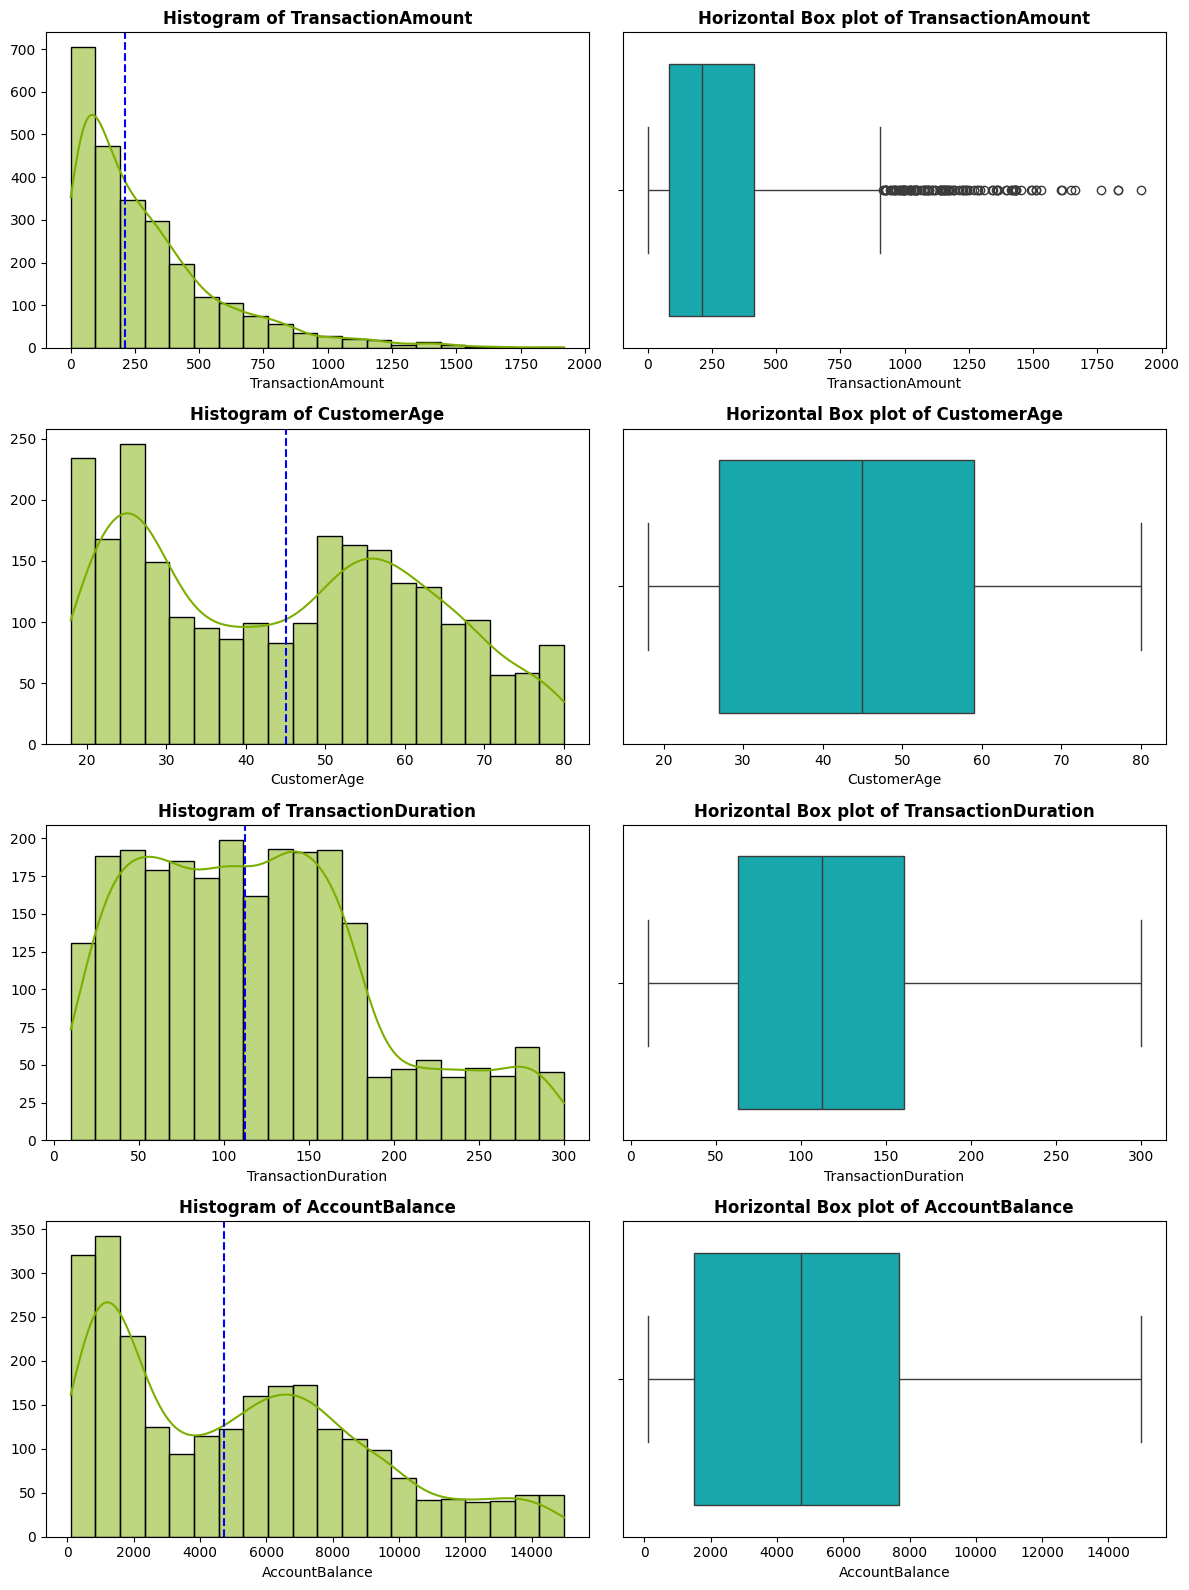

In [285]:
def plot_numerical_features(df=df_bank_transactions, numerical_features = num_features):
    fig, axes = plt.subplots(len(numerical_features), 2, figsize=(12, len(numerical_features)*4))
    axes = np.atleast_2d(axes)

    for i, feature in enumerate(numerical_features):
        sns.histplot(data=df[feature], color="#7CAE00", bins = 20, kde=True, ax=axes[i, 0])
        axes[i, 0].set_title(f"Histogram of {feature}", weight="bold")
        axes[i, 0].set_ylabel("")
        axes[i, 0].axvline(df[feature].median(), color="blue", linestyle="--", label="Median Train")
        # axes[i, 0].grid(axis="y", color="gray", linestyle="--", linewidth=0.7)

        sns.boxplot(data=df[feature], color="#00BFC4", orient="h", ax=axes[i, 1])
        axes[i, 1].set_title(f"Horizontal Box plot of {feature}", weight="bold")
        axes[i, 1].set_xlabel(feature)
        # axes[i, 1].grid(axis="x", color="gray", linestyle="--", linewidth=0.7)

    plt.tight_layout()
    plt.show()

plot_numerical_features()

In [286]:
def check_skewness(data = df_bank_transactions, numerical_features = num_features, highlight=True, sort=True):
    skewness_dict = {}
    skew_feature = []
    for feature in numerical_features:
        skew = data[feature].skew(skipna=True)
        skewness_dict[feature] = skew

    skew_df = pd.DataFrame.from_dict(skewness_dict, orient="index", columns=["Skewness"])
    if sort:
        skew_df = skew_df.reindex(skew_df["Skewness"].abs().sort_values(ascending=False).index)
    else:
        pass
    
    print(f"\n🔍 Skewness for dataset:")
    print("-"*70)
    print(f"{'Feature':<30} | {'Skewness':<10} | {'Remark'}")
    print("-"*70)
    for feature, row in skew_df.iterrows():
        skew = row["Skewness"]
        abs_skew = abs(skew)
        if abs_skew > 1:
            remark = "Highly skewed"
            color = "\033[91m"  
        elif abs_skew > 0.5:
            remark = "Moderately skewed"
            color = "\033[93m"  
        else:
            remark = "Approximately symmetric"
            color = ""
        endc = "\033[0m" if color else ""
        if highlight and color:
            print(f"{color}{feature:<30} | {skew:>+10f} | {remark}{endc}")
            skew_feature.append(feature)
        else:
            print(f"{feature:<30} | {skew:>+10f} | {remark}")
    print("-"*70)
    return skew_feature, skew_df

skew_feature, skew_df = check_skewness()


🔍 Skewness for dataset:
----------------------------------------------------------------------
Feature                        | Skewness   | Remark
----------------------------------------------------------------------
TransactionAmount              |  +1.740107 | Highly skewed
AccountBalance                 |  +0.601201 | Moderately skewed
TransactionDuration            |  +0.599432 | Moderately skewed
CustomerAge                    |  +0.147864 | Approximately symmetric
----------------------------------------------------------------------


### Insights on Numerical Feature Distributions

* **TransactionAmount:** Highly right-skewed (+1.74) → most transactions are small, with a few large outliers (possible anomalies).
* **AccountBalance:** Moderately right-skewed (+0.60) → majority of customers have mid-range balances; few with very high balances.
* **TransactionDuration:** Moderately right-skewed (+0.60) → most transactions are short, a few unusually long ones.
* **CustomerAge:** Nearly symmetric (+0.15) → balanced age distribution across customers.

👉 **Key takeaway:**
Data shows **right-skewed distributions** for monetary and time-based variables, suggesting the presence of **rare high-value or long-duration transactions** — potential indicators for anomaly detection.

## Categorical Feature Distributions

**Categorical Features – Visualization Feasibility**

Although all of the following are **categorical columns**, not all are meaningful for **distribution visualization**:

* **Recommended for Visualization**

  * **`TransactionType`** → Distribution of **Credit vs. Debit** transactions (key insight).
  * **`Channel`** → Distribution across **ATM, Online, Branch**, etc.
  * **`Region`** (derived from `Location`) → Regional transaction distribution.
  * **`CustomerOccupation`** → Distribution of customer occupations, highlighting dominant groups.

* **Not Suitable for Distribution Plots**

  * **Identifiers**: `TransactionID`, `AccountID`, `DeviceID`, `MerchantID` → Mostly unique values, not insightful for frequency distribution.
  * **Time-based Variables**: `TransactionDate`, `PreviousTransactionDate` → Better analyzed via **time-series trends** (seasonality, patterns) rather than simple distributions.
  * **High Cardinality**: `IP Address` → Too many unique values, minimal insight for categorical distribution.
  * **`Location`** → More interpretable when grouped into `Region`.

**Conclusion**:
For categorical EDA, focus on **TransactionType, Channel, Region, and CustomerOccupation**.
Other categorical features will be addressed through **ID uniqueness checks, time-series analysis, or feature engineering**, rather than direct distribution plots.

In [287]:
def color(n_colors=2):
    return sns.color_palette("viridis", n_colors=n_colors)

In [288]:
def plot_categorical_distribution(feature, df=df_bank_transactions, order=None):
    # Determine the order of categories by descending frequency
    feature_counts = df[feature].value_counts()
    order = order or feature_counts.index

    fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(12, 5))

    # --- BARPLOT ---
    sns.countplot(
        data=df, x=feature, ax=ax[0],
        palette=sns.color_palette("viridis", n_colors=len(order)),
        order=order
    )
    ax[0].set_title(f"Count plot of {feature}", fontsize=14, pad=20, weight="bold")
    ax[0].set_xlabel(feature)
    ax[0].set_ylabel("")
    sns.despine(ax=ax[0], top=True, right=True, left=False, bottom=False)

    # Display count values on top of bars
    for p in ax[0].patches:
        height = p.get_height()
        ax[0].text(
            p.get_x() + p.get_width() / 2,
            height + max(feature_counts) * 0.01,
            f"{int(height)}",
            ha="center", va="bottom", fontsize=10, color="black"
        )

    # --- PIE CHART ---
    wedges, texts, autotexts = ax[1].pie(
        feature_counts[order],
        labels=order,
        autopct="%1.1f%%",
        startangle=90,
        colors=sns.color_palette("viridis", n_colors=len(order)),
        wedgeprops=dict(width=0.4, edgecolor="w"),
        radius=1.2
    )

    # Adjust text size inside the pie chart
    for text in texts + autotexts:
        text.set_fontsize(10)

    # Add a white circle at the center (to create a donut chart)
    centre_circle = plt.Circle((0, 0), 0.70, fc="white")
    ax[1].add_artist(centre_circle)
    ax[1].set_title(f"Percentage Distribution of {feature}", fontsize=14, pad=20, weight="bold")
    ax[1].axis("equal")

    plt.tight_layout()
    plt.show()

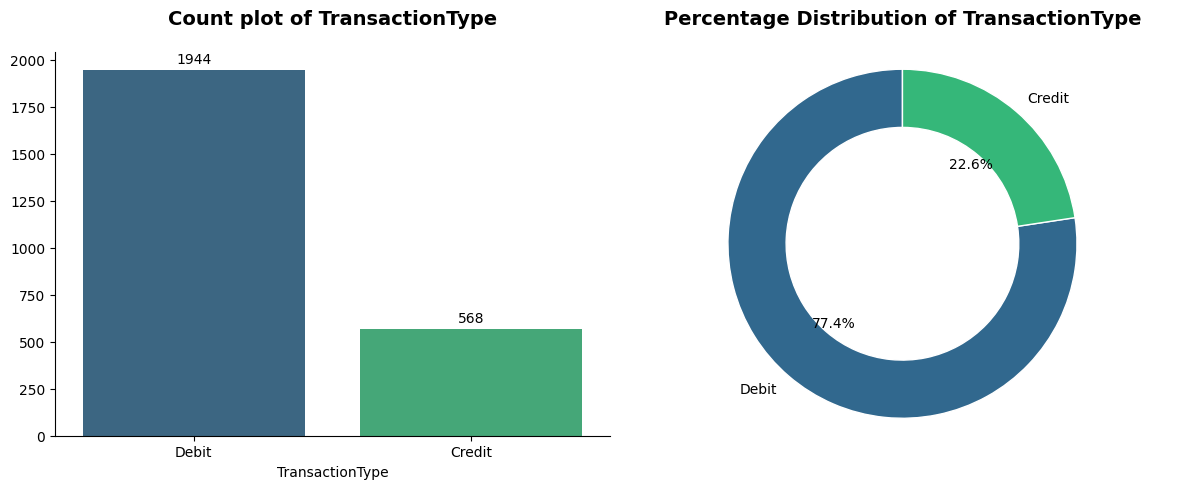

In [289]:
plot_categorical_distribution(feature="TransactionType")

- The bar chart clearly shows that **Debit** transactions are significantly more frequent than **Credit** transactions. The count of **Debit** transactions is around 1944, while **Credit** transactions number approximately 568.
- It shows that **Debit** transactions account for approximately 77.4% of the total transactions, while **Credit** transactions constitute around 22.6%.

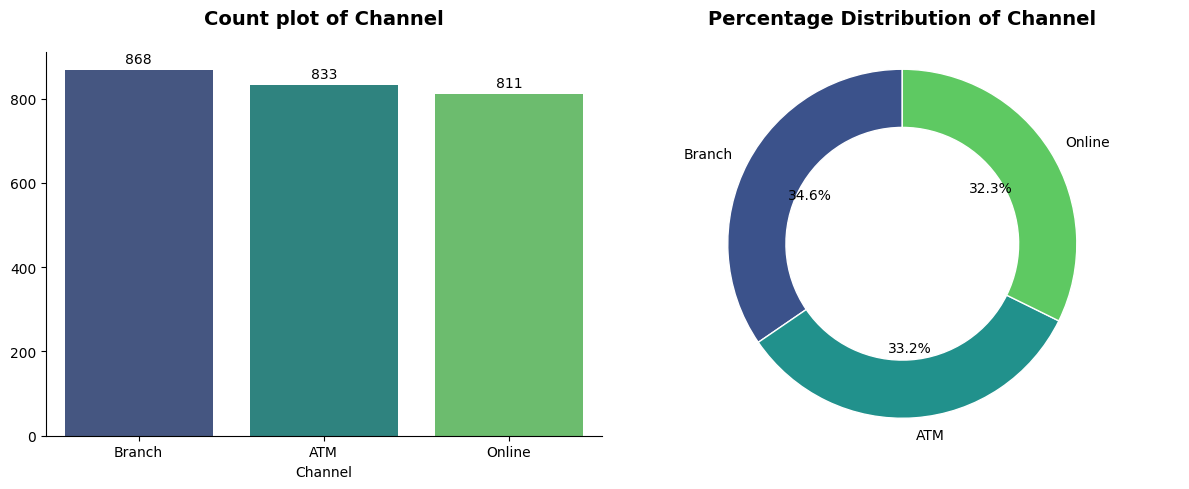

In [290]:
plot_categorical_distribution(feature="Channel")

* **Branch** transactions are the most common (34.6%), followed by **ATM (33.2%)** and **Online (32.3%)**.
* The distribution is **well-balanced**, showing that customers use all three channels almost equally — indicating **diverse banking behavior**.

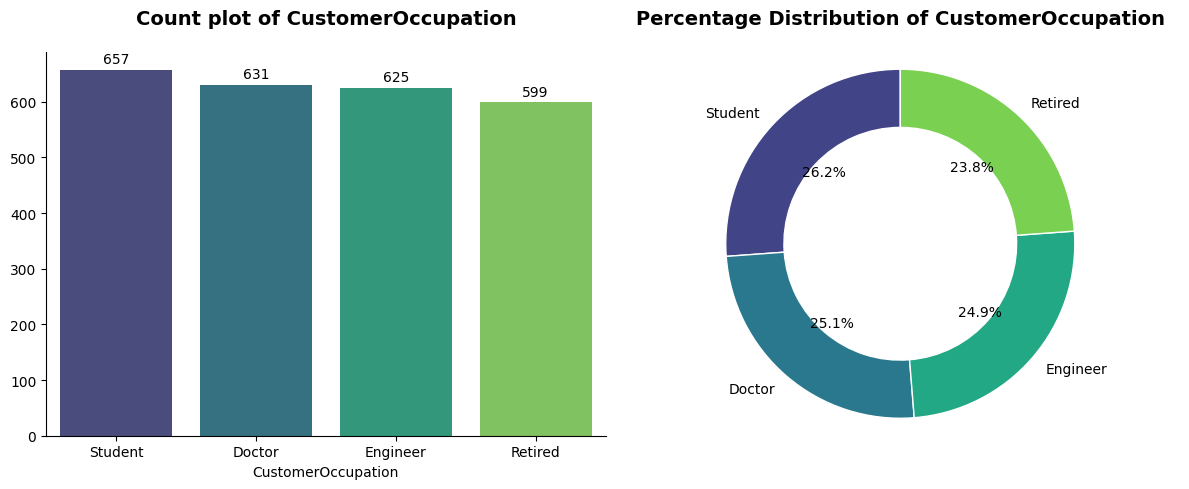

In [291]:
plot_categorical_distribution(feature="CustomerOccupation")

* **Students** make up the largest group (26.2%), followed by **Doctors (25.1%)**, **Engineers (24.9%)**, and **Retired (23.8%)**.
* The distribution is **fairly balanced**, indicating a **diverse and unbiased customer base**, suitable for building generalized detection models.

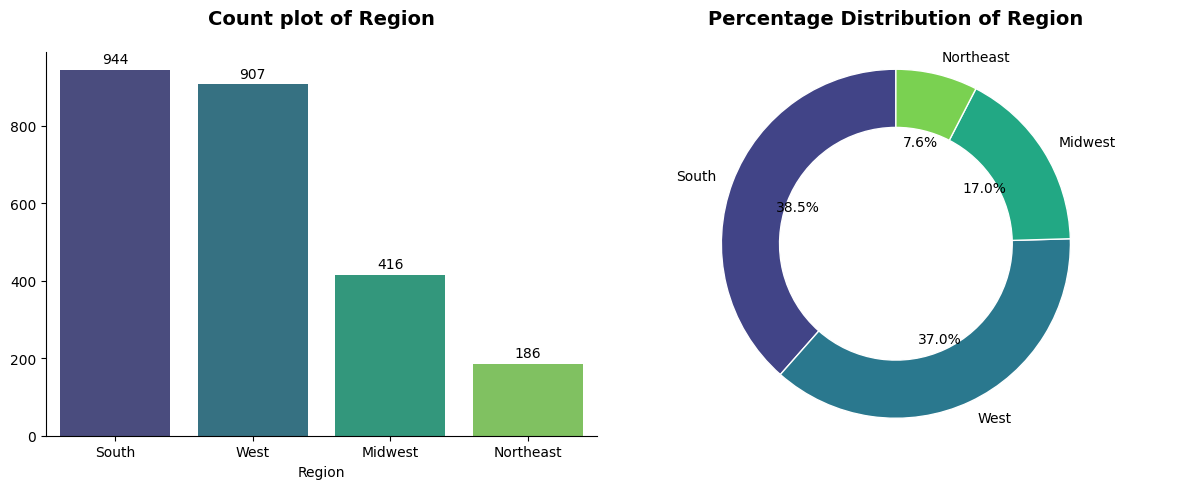

In [292]:
# Mapping city -> region
region_map = {
    # Northeast
    "New York": "Northeast",
    "Philadelphia": "Northeast",
    "Boston": "Northeast",
    
    # Midwest
    "Chicago": "Midwest",
    "Detroit": "Midwest",
    "Columbus": "Midwest",
    "Indianapolis": "Midwest",
    "Milwaukee": "Midwest",
    "Omaha": "Midwest",
    "Kansas City": "Midwest",
    
    # South
    "Dallas": "South",
    "Houston": "South",
    "San Antonio": "South",
    "Austin": "South",
    "Fort Worth": "South",
    "Charlotte": "South",
    "Memphis": "South",
    "Atlanta": "South",
    "Miami": "South",
    "Virginia Beach": "South",
    "Nashville": "South",
    "Louisville": "South",
    "Oklahoma City": "South",
    "Baltimore": "South",
    "Washington": "South",
    "Jacksonville": "South",
    
    # West
    "Los Angeles": "West",
    "San Diego": "West",
    "San Jose": "West",
    "San Francisco": "West",
    "Seattle": "West",
    "Portland": "West",
    "Phoenix": "West",
    "Las Vegas": "West",
    "Denver": "West",
    "Albuquerque": "West",
    "Fresno": "West",
    "Sacramento": "West",
    "Mesa": "West",
    "Colorado Springs": "West",
    "Tucson": "West",
    "El Paso": "West",
}

# Apply mapping
df_bank_transactions["Region"] = df_bank_transactions["Location"].map(region_map)
df_bank_transactions = df_bank_transactions.drop(columns=["Location"])
plot_categorical_distribution(feature="Region")

* The bar chart shows that **South (944)** and **West (907)** account for the largest share of transactions, far surpassing **Midwest (416)** and **Northeast (186)**.
* The percentage distribution reflects this as well:

  * **South**: \~38.5%
  * **West**: \~37.0%
  * **Midwest**: \~17.0%
  * **Northeast**: \~7.6%
* This indicates that most transactions are concentrated in the **South and West regions**, while the **Northeast** records the lowest transaction activity.

## RFM Analysis

**Customer segmentation based on RFM Score**

| Segment                        | Description                                                                  | RFM Condition    |
| ------------------------------ | ---------------------------------------------------------------------------- | -------------------------- |
| **Champions / Best Customers** | Most valuable customers: recent activity, frequent transactions, high spend. | `R ≥ 4, F ≥ 4, M ≥ 4`      |
| **Loyal Customers**            | Loyal customers: purchase frequently and spend consistently well.            | `F ≥ 4, M ≥ 3`             |
| **Potential Loyalists**        | New customers with decent frequency/spending, potential to become loyal.     | `R ≥ 4, F ≥ 2`             |
| **At Risk**                    | Previously frequent/high spenders but inactive for a long time.              | `R ≤ 2, F ≥ 3`             |
| **New Customers**              | Recently joined, made transactions recently but with low frequency.          | `R ≥ 4, F = 1`             |
| **Hibernating / Churn**        | Customers inactive for a long time with low spending.                        | `R = 1, F = 1, M = 1`      |
| **Others**                     | Customers not falling into the above categories.                             | Different from above rules |


In [293]:
# Convert 2 date columns to datetime type.
df_bank_transactions["TransactionDate"] = pd.to_datetime(df_bank_transactions["TransactionDate"], format="mixed")
df_bank_transactions["PreviousTransactionDate"] = pd.to_datetime(df_bank_transactions["PreviousTransactionDate"], format="mixed")

# Define the reference date = the latest transaction date + 1 day
# +1 day is added to avoid Recency = 0 for customers who transacted on the last day
recency_date = df_bank_transactions["TransactionDate"].max() + pd.Timedelta(days=1)

# Calculate RFM for each customer (AccountID)
rfm_df = df_bank_transactions.groupby("AccountID").agg({
    # Recency = (reference date - most recent transaction date of the customer)
    "TransactionDate": lambda x: (recency_date - x.max()).days,
    
    # Frequency = number of transactions (count unique TransactionID)
    "TransactionID": "nunique",
    
    # Monetary = total transaction amount
    "TransactionAmount": "sum"
}).reset_index()

# Rename columns for better readability
rfm_df.columns = ["AccountID", "Recency", "Frequency", "Monetary"]

display(rfm_df.head(10))

,AccountID,Recency,Frequency,Monetary
0,AC00001,49,2,260.76
1,AC00002,12,7,2056.21
2,AC00003,91,5,1266.34
3,AC00004,1,9,2180.08
4,AC00005,29,9,3131.77
5,AC00006,89,4,1017.72
6,AC00007,36,5,1495.38
7,AC00008,42,1,76.16
8,AC00009,8,5,984.08
9,AC00010,33,7,2768.67


In [294]:
rfm_df["R"] = pd.qcut(rfm_df["Recency"], 5, labels=[5,4,3,2,1])
rfm_df["F"] = pd.qcut(rfm_df["Frequency"].rank(method="first"), 5, labels=[1,2,3,4,5])
rfm_df["M"] = pd.qcut(rfm_df["Monetary"], 5, labels=[1,2,3,4,5])

rfm_df["RFM_Score"] = rfm_df["R"].astype(str) + rfm_df["F"].astype(str) + rfm_df["M"].astype(str)
display(rfm_df.head(10))

,AccountID,Recency,Frequency,Monetary,R,F,M,RFM_Score
0,AC00001,49,2,260.76,3,1,1,311
1,AC00002,12,7,2056.21,5,4,4,544
2,AC00003,91,5,1266.34,2,3,3,233
3,AC00004,1,9,2180.08,5,5,4,554
4,AC00005,29,9,3131.77,4,5,5,455
5,AC00006,89,4,1017.72,2,2,2,222
6,AC00007,36,5,1495.38,4,3,3,433
7,AC00008,42,1,76.16,3,1,1,311
8,AC00009,8,5,984.08,5,3,2,532
9,AC00010,33,7,2768.67,4,4,5,445


In [295]:
def classify_rfm(row):
    r, f, m = row["R"], row["F"], row["M"]

    if r >= 4 and f >= 4 and m >= 4:
        return "Best Customers"
    elif f >= 4 and m >= 3:
        return "Loyal Customers"
    elif r >= 4 and f >= 2:
        return "Potential Loyalists"
    elif r <= 2 and f >= 3:
        return "At Risk"
    elif r >= 4  and f == 1:
        return "New Customers"
    elif r == 1  and f == 1 and m == 1:
        return "Churn Customers"
    else:
        return "Other"

rfm_df["RFM_Segment"] = rfm_df.apply(classify_rfm, axis=1)
display(rfm_df.head(10))

,AccountID,Recency,Frequency,Monetary,R,F,M,RFM_Score,RFM_Segment
0,AC00001,49,2,260.76,3,1,1,311,Other
1,AC00002,12,7,2056.21,5,4,4,544,Best Customers
2,AC00003,91,5,1266.34,2,3,3,233,At Risk
3,AC00004,1,9,2180.08,5,5,4,554,Best Customers
4,AC00005,29,9,3131.77,4,5,5,455,Best Customers
5,AC00006,89,4,1017.72,2,2,2,222,Other
6,AC00007,36,5,1495.38,4,3,3,433,Potential Loyalists
7,AC00008,42,1,76.16,3,1,1,311,Other
8,AC00009,8,5,984.08,5,3,2,532,Potential Loyalists
9,AC00010,33,7,2768.67,4,4,5,445,Best Customers


In [296]:
# Create a layout with clear headers, centered text, and nicely formatted numbers
summary_rfm = (
    rfm_df.groupby("RFM_Segment").agg({
        "Recency": ["mean", "min", "max"],
        "Frequency": ["mean", "min", "max"],
        "Monetary": ["mean", "min", "max"],
        "AccountID": "count"
    })
    .sort_values(("Monetary", "mean"), ascending=False)
    .style
    .set_caption("RFM Summary by Segment")
    .format(precision=0)  # Round numbers
    .set_table_styles([
        {"selector": "th", "props": [("text-align", "center")]},
        {"selector": "caption", "props": [("caption-side", "top"), ("font-size", "16px"), ("font-weight", "bold")]}
    ])
    .set_properties(**{
        "text-align": "center",
        "font-size": "12px"
    })
    .background_gradient(subset=[("Recency", "mean"), ("Frequency", "mean"), ("Monetary", "mean"), ("AccountID", "count")], cmap="Greens")
)
display(summary_rfm)


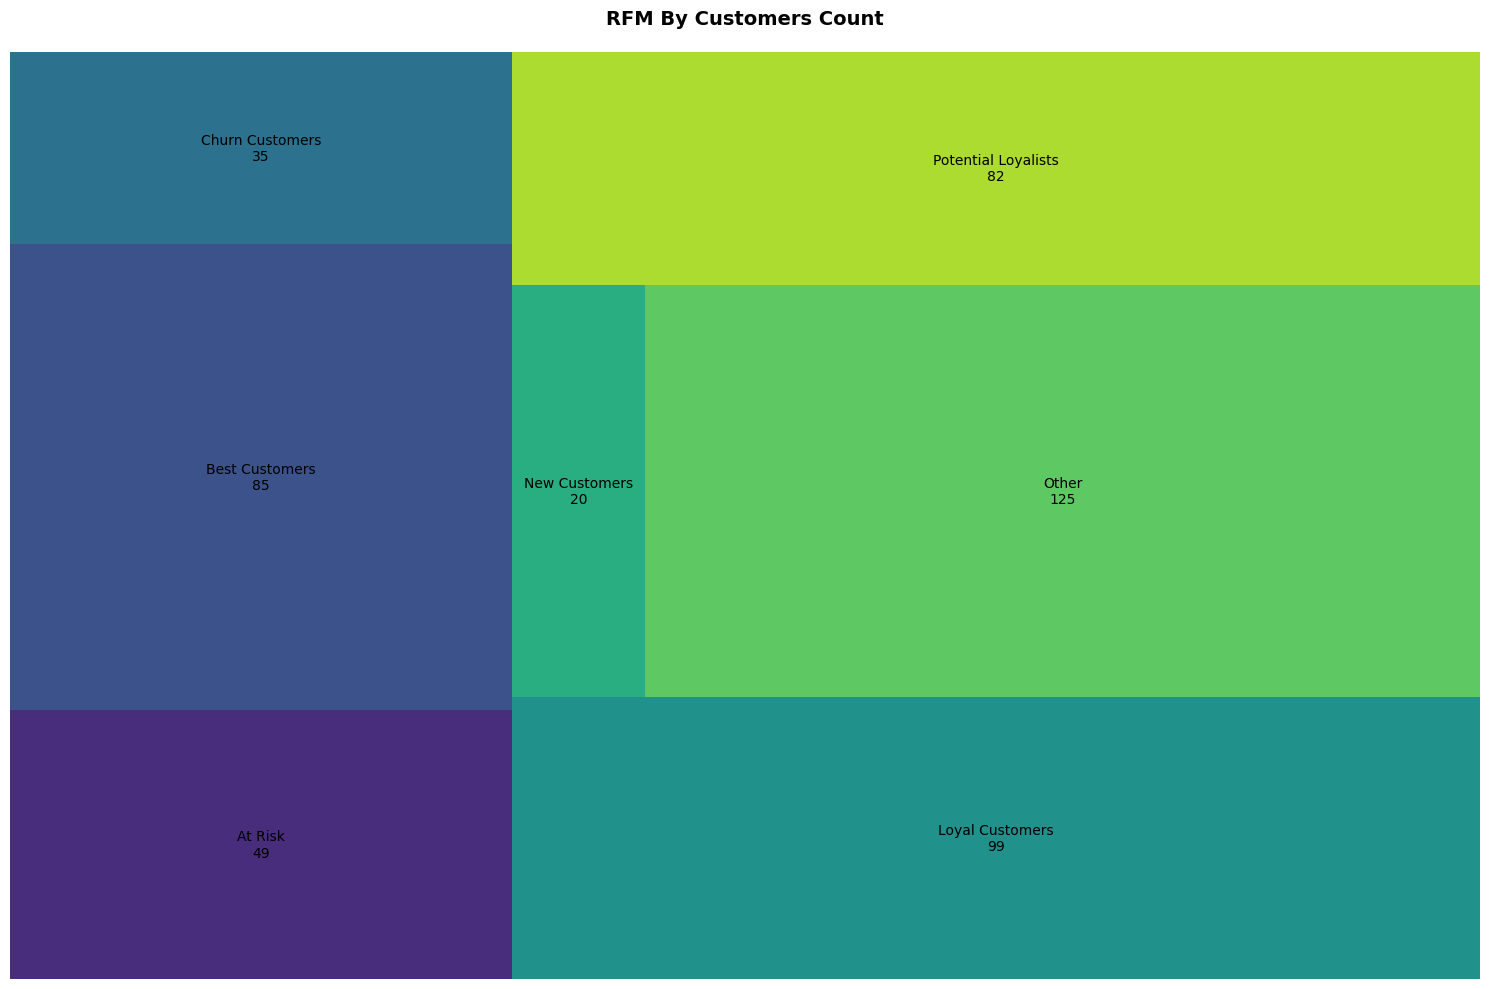

In [297]:
import squarify

rfm_df = rfm_df.astype({
    "R": "int8",
    "F": "int8",
    "M": "int8"
})

rfm_summarised = rfm_df.groupby (by = "RFM_Segment", as_index = False)\
                        .agg (
                            customersCount = ("AccountID", "nunique"),
                            total_R = ("R", "sum"),
                            total_F = ("F", "sum"),
                            total_M = ("M", "sum")
                        )

plt.figure(figsize=(15, 10))
squarify.plot(
    rfm_summarised["customersCount"].to_list(),
    label = rfm_summarised["RFM_Segment"] + "\n" + rfm_summarised["customersCount"].astype(str),
    color = color(n_colors=rfm_df["RFM_Segment"].nunique())
)
plt.title ("RFM By Customers Count", fontsize=14, pad=20, weight="bold")
plt.axis("off")
plt.tight_layout()
plt.show()

### **Segment Analysis**

**Best Customers**

* Average Recency = **19 days** → these customers have transacted **very recently**.
* Frequency = **8** → the most frequent group.
* Monetary = **2,558** → highest spending level.
* Count = **85 customers** → small group but **VIP & highly loyal**, should be retained and targeted for upsell.

**Loyal Customers**

* Average Recency = **62 days** → transactions are relatively recent.
* Frequency = **7**, quite frequent.
* Monetary = **2,144**, strong spending.
* Count = **99 customers** → loyal group, providing stable long-term value.

**At Risk**

* Average Recency = **106 days** → quite a long time since last activity.
* Frequency = **5**, used to transact often.
* Monetary = **1,291**, fairly high spending.
* Count = **49 customers** → previously valuable customers, require re-engagement strategies.

**Potential Loyalists**

* Average Recency = **19 days** → recently active.
* Frequency = **5**.
* Monetary = **1,283**.
* Count = **82 customers** → high potential to become loyal if nurtured.

**Other**

* Average Recency = **94 days**.
* Frequency = **3**.
* Monetary = **1,008**.
* Count = **125 customers** → neutral group with moderate activity.

**New Customers**

* Average Recency = **14 days** → very recent transactions.
* Frequency = **2**.
* Monetary = **645**, low spending.
* Count = **20 customers** → new group, should be encouraged to return.

**Churn Customers**

* Average Recency = **227 days** → inactive for a very long time.
* Frequency = **2**, very low.
* Monetary = **301**, the lowest spending.
* Count = **35 customers** → likely churned, difficult to reactivate.

**Overall Insight**:

* **Best & Loyal Customers**: though fewer in number, they generate the highest value → priority for retention and upselling.
* **At Risk & Churn Customers**: warning signs of attrition → need targeted win-back campaigns.
* **Potential Loyalists & New Customers**: represent **growth opportunities** → with the right nurturing, they can transition into Loyal or Best Customers.

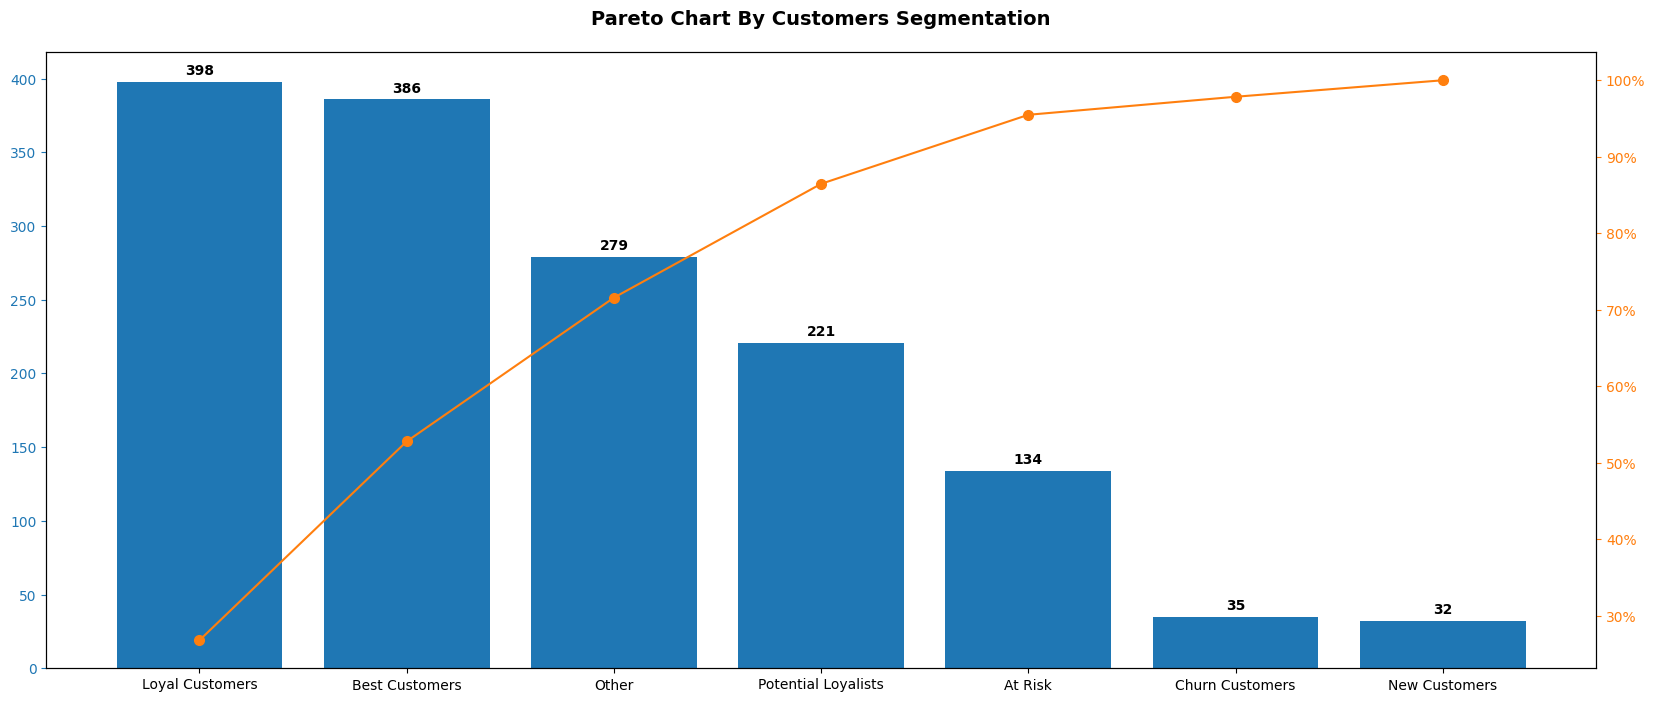

In [298]:
from matplotlib.ticker import PercentFormatter

rfm_summarised = rfm_summarised.sort_values(by="total_M", ascending=False)
rfm_summarised["cumpercentage"] = rfm_summarised["total_M"].cumsum() / rfm_summarised["total_M"].sum() * 100

fig, ax = plt.subplots(figsize=(20, 8))

bars = ax.bar(rfm_summarised["RFM_Segment"], rfm_summarised["total_M"], color="C0")

ax1 = ax.twinx()
ax1.plot(rfm_summarised["RFM_Segment"], rfm_summarised["cumpercentage"], color="C1", marker="o", ms=7)
ax1.yaxis.set_major_formatter(PercentFormatter())

# Add value labels on top of each bar
ax.bar_label(bars, labels=[f"{v:,.0f}" for v in rfm_summarised["total_M"]], padding=3, fontsize=10, color="black", weight="bold")

ax.tick_params(axis="y", colors="C0")
ax1.tick_params(axis="y", colors="C1")

plt.title("Pareto Chart By Customers Segmentation", fontsize=14, pad=20, weight="bold")
plt.show()

### **Meaning of the Pareto chart components**

1. **Loyal Customers & Best Customers**

   * These two segments contribute the **largest share of customers** overall.
   * Together, they represent the **core base** of the business, consistently active and generating high value.

2. **Other & Potential Loyalists**

   * The **Other** group, though neutral, still accounts for a **significant portion** of the customer base.
   * **Potential Loyalists** contribute meaningfully and have the potential to **move up to Loyal/Best Customers** if nurtured properly.

3. **At Risk, Churn Customers, and New Customers**

   * These groups contribute less to the total count compared to the top segments.
   * **At Risk** still shows noticeable weight and signals customers that should be targeted for win-back strategies.
   * **Churn** and **New Customers** are the smallest groups, but strategically important:

     * Churn → may require reactivation campaigns.
     * New Customers → need onboarding and engagement to retain them.

4. **Cumulative percentage line (orange line)**

   * Shows that the combination of **Loyal Customers, Best Customers, and Other** already covers the majority of the customer base (over 70%).
   * Adding Potential Loyalists pushes this share close to **90–95%** of the total.

**Summary**

The chart demonstrates that while the **bulk of customers are concentrated in Loyal, Best, and Other groups**, smaller segments like **Potential Loyalists, At Risk, and New Customers** hold **strategic value**. They can either be converted into high-value customers or reactivated to reduce churn risk.

## Cohort Analysis

* **100% of records have `PreviousTransactionDate` greater than `TransactionDate`.**
* The day difference (`delta_days = TransactionDate − PreviousTransactionDate`) is entirely negative: min = −672 days, max = −308 days.
  → This means the so-called “previous” date actually falls in the **future (year 2024)** compared to the current transaction (year 2023). This is a **data entry error**, not the true “next transaction.”

### Customer Retention

In [299]:
df_bank_transactions_cohort = df_bank_transactions.copy()

In [300]:
# TransactionDate
df_bank_transactions_cohort["cohort"] = df_bank_transactions_cohort.groupby("AccountID")["TransactionDate"].transform("min").dt.to_period("M")
df_bank_transactions_cohort["order_month"] = df_bank_transactions_cohort["TransactionDate"].dt.to_period("M")
# Create cohort dataframe
df_cohort = df_bank_transactions_cohort.groupby(["cohort", "order_month"]).agg(n_customers=("AccountID", "count")).reset_index(drop=False)

In [301]:
from operator import attrgetter

# TransactionDate
df_cohort["period_number"] = (df_cohort.order_month - df_cohort.cohort).apply(attrgetter("n"))
display(df_cohort.head(10))

,cohort,order_month,n_customers,period_number
0,2023-01,2023-01,207,0
1,2023-01,2023-02,73,1
2,2023-01,2023-03,72,2
3,2023-01,2023-04,53,3
4,2023-01,2023-05,75,4
5,2023-01,2023-06,82,5
6,2023-01,2023-07,74,6
7,2023-01,2023-08,79,7
8,2023-01,2023-09,70,8
9,2023-01,2023-10,68,9


In [302]:
cohort_pivot = df_cohort.pivot_table(index="cohort", columns="period_number", values="n_customers")
cohort_pivot

period_number,0,1,2,3,4,5,6,7,8,9,10,11,12
cohort,,,,,,,,,,,,,
2023-01,207.0,73.0,72.0,53.0,75.0,82.0,74.0,79.0,70.0,68.0,78.0,64.0,5.0
2023-02,145.0,42.0,36.0,57.0,47.0,42.0,40.0,54.0,54.0,50.0,55.0,3.0,NaN
2023-03,83.0,28.0,35.0,21.0,22.0,43.0,25.0,25.0,24.0,30.0,3.0,NaN,NaN
2023-04,44.0,9.0,16.0,16.0,18.0,19.0,20.0,21.0,13.0,NaN,NaN,NaN,NaN
2023-05,44.0,16.0,7.0,19.0,16.0,23.0,12.0,13.0,2.0,NaN,NaN,NaN,NaN
2023-06,30.0,15.0,6.0,7.0,11.0,12.0,8.0,NaN,NaN,NaN,NaN,NaN,NaN
2023-07,19.0,5.0,7.0,6.0,10.0,6.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2023-08,14.0,8.0,9.0,3.0,5.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2023-09,8.0,1.0,5.0,3.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


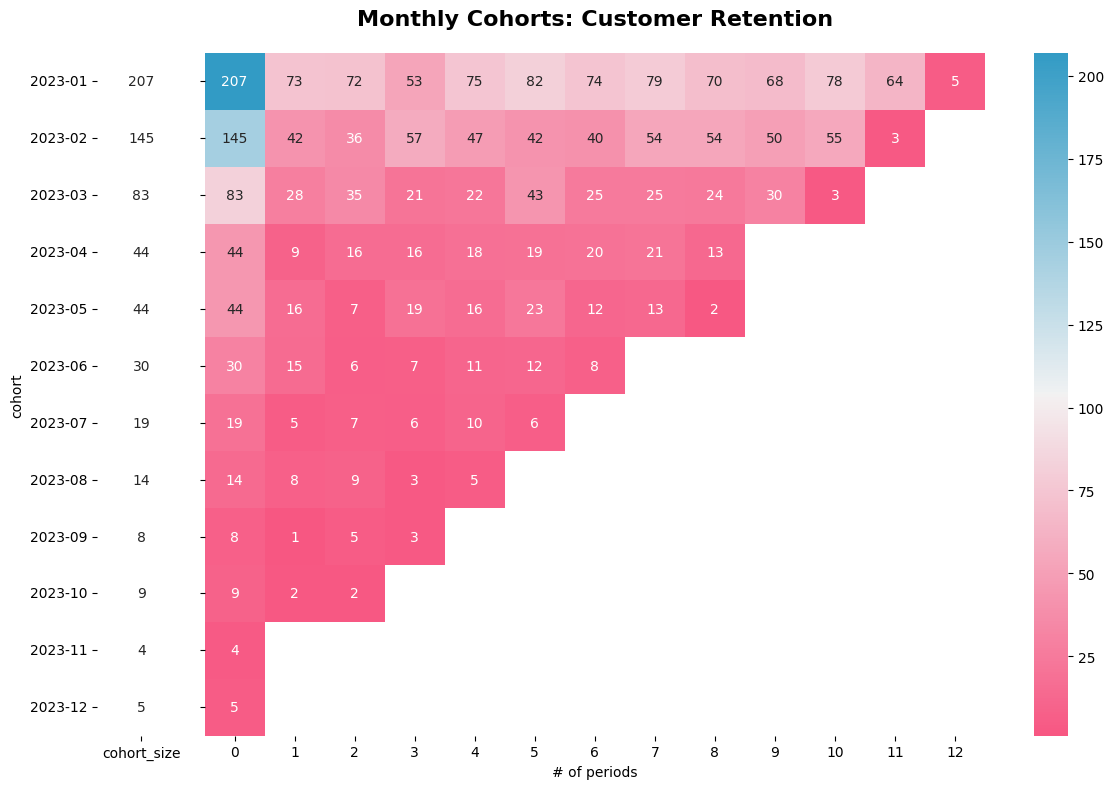

In [303]:
import matplotlib.colors as mcolors

cohort_size = cohort_pivot.iloc[:, 0]
fig, ax = plt.subplots(1, 2, figsize=(12, 8), sharey=True, gridspec_kw={"width_ratios": [1, 11]})
cmap = sns.diverging_palette(0, 230, 90, 60, as_cmap=True)
# retention matrix
sns.heatmap(cohort_pivot, mask=cohort_pivot.isnull(), annot=True, fmt=".0f", cmap=cmap, ax=ax[1])
ax[1].set_title("Monthly Cohorts: Customer Retention", fontsize=16, pad=20, weight="bold")
ax[1].set(xlabel="# of periods", ylabel="")

# cohort size
cohort_size_df = pd.DataFrame(cohort_size).rename(columns={0: "cohort_size"})
white_cmap = mcolors.ListedColormap(["white"])
sns.heatmap(cohort_size_df, annot=True, cbar=False, fmt="g", cmap=white_cmap, ax=ax[0])

plt.tight_layout()
plt.show()

In [304]:
retention_matrix = cohort_pivot.divide(cohort_size, axis=0)
retention_matrix

period_number,0,1,2,3,4,5,6,7,8,9,10,11,12
cohort,,,,,,,,,,,,,
2023-01,1.0,0.352657,0.347826,0.256039,0.362319,0.396135,0.357488,0.381643,0.338164,0.328502,0.376812,0.309179,0.024155
2023-02,1.0,0.289655,0.248276,0.393103,0.324138,0.289655,0.275862,0.372414,0.372414,0.344828,0.379310,0.020690,NaN
2023-03,1.0,0.337349,0.421687,0.253012,0.265060,0.518072,0.301205,0.301205,0.289157,0.361446,0.036145,NaN,NaN
2023-04,1.0,0.204545,0.363636,0.363636,0.409091,0.431818,0.454545,0.477273,0.295455,NaN,NaN,NaN,NaN
2023-05,1.0,0.363636,0.159091,0.431818,0.363636,0.522727,0.272727,0.295455,0.045455,NaN,NaN,NaN,NaN
2023-06,1.0,0.500000,0.200000,0.233333,0.366667,0.400000,0.266667,NaN,NaN,NaN,NaN,NaN,NaN
2023-07,1.0,0.263158,0.368421,0.315789,0.526316,0.315789,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2023-08,1.0,0.571429,0.642857,0.214286,0.357143,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2023-09,1.0,0.125000,0.625000,0.375000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


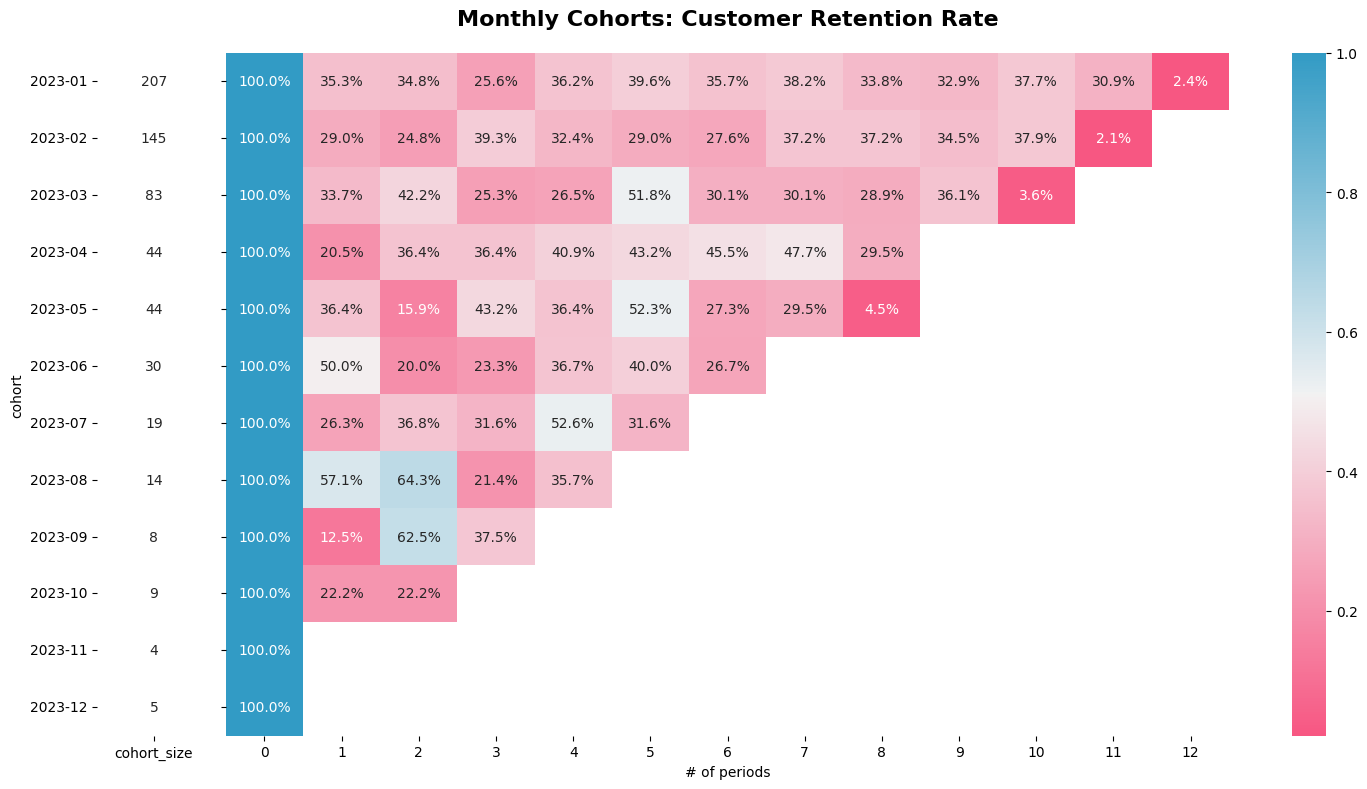

In [305]:
fig, ax = plt.subplots(1, 2, figsize=(15, 8), sharey=True, gridspec_kw={"width_ratios": [1, 11]})
cmap = sns.diverging_palette(0, 230, 90, 60, as_cmap=True)
# retention matrix
sns.heatmap(retention_matrix, mask=retention_matrix.isnull(), annot=True, fmt=".1%", cmap=cmap, ax=ax[1])
ax[1].set_title("Monthly Cohorts: Customer Retention Rate", fontsize=16, pad=20, weight="bold")
ax[1].set(xlabel="# of periods", ylabel="")

# cohort size
cohort_size_df = pd.DataFrame(cohort_size).rename(columns={0: "cohort_size"})
white_cmap = mcolors.ListedColormap(["white"])
sns.heatmap(cohort_size_df, annot=True, cbar=False, fmt="g", cmap=white_cmap, ax=ax[0])

plt.tight_layout()
plt.show()

### Customer Churn

In [306]:
base = cohort_pivot[0]
n_customer_churn = cohort_pivot.apply(lambda col: base - col, axis=0)
n_customer_churn[0] = base
n_customer_churn

period_number,0,1,2,3,4,5,6,7,8,9,10,11,12
cohort,,,,,,,,,,,,,
2023-01,207.0,134.0,135.0,154.0,132.0,125.0,133.0,128.0,137.0,139.0,129.0,143.0,202.0
2023-02,145.0,103.0,109.0,88.0,98.0,103.0,105.0,91.0,91.0,95.0,90.0,142.0,NaN
2023-03,83.0,55.0,48.0,62.0,61.0,40.0,58.0,58.0,59.0,53.0,80.0,NaN,NaN
2023-04,44.0,35.0,28.0,28.0,26.0,25.0,24.0,23.0,31.0,NaN,NaN,NaN,NaN
2023-05,44.0,28.0,37.0,25.0,28.0,21.0,32.0,31.0,42.0,NaN,NaN,NaN,NaN
2023-06,30.0,15.0,24.0,23.0,19.0,18.0,22.0,NaN,NaN,NaN,NaN,NaN,NaN
2023-07,19.0,14.0,12.0,13.0,9.0,13.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2023-08,14.0,6.0,5.0,11.0,9.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2023-09,8.0,7.0,3.0,5.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


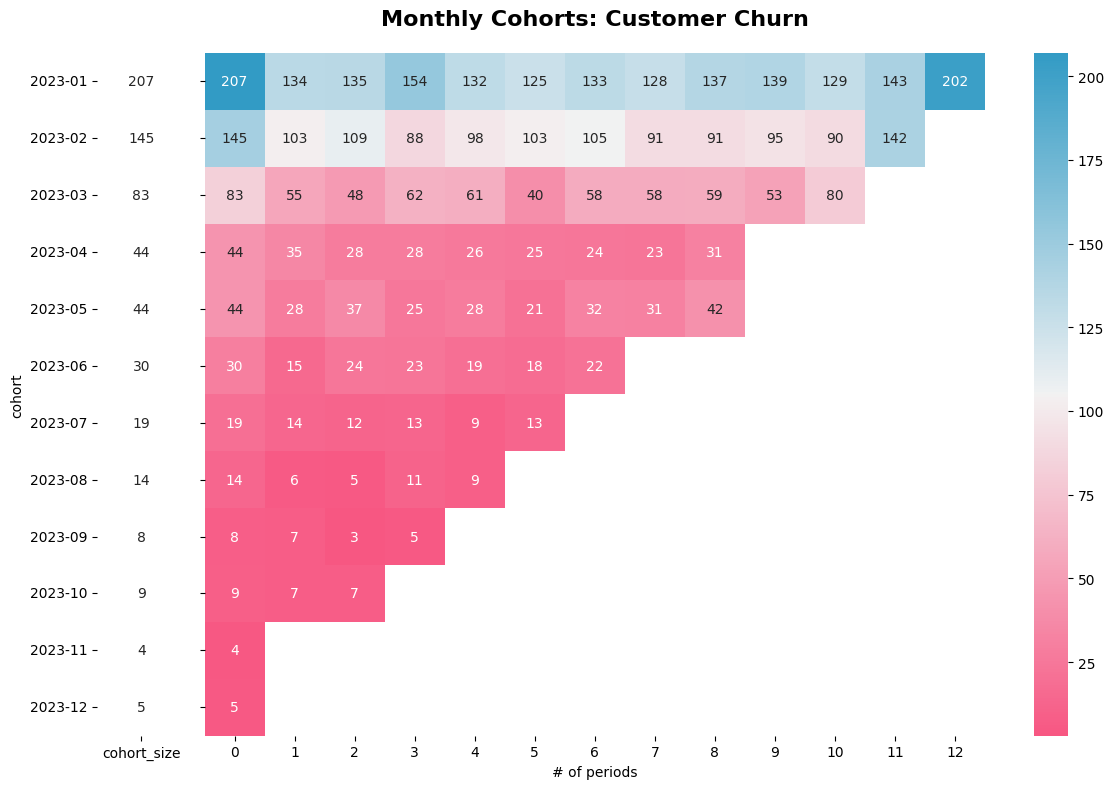

In [307]:
cohort_size_churn = n_customer_churn.iloc[:, 0]
fig, ax = plt.subplots(1, 2, figsize=(12, 8), sharey=True, gridspec_kw={"width_ratios": [1, 11]})
cmap = sns.diverging_palette(0, 230, 90, 60, as_cmap=True)
# retention matrix
sns.heatmap(n_customer_churn, mask=n_customer_churn.isnull(), annot=True, fmt=".0f", cmap=cmap, ax=ax[1])
ax[1].set_title("Monthly Cohorts: Customer Churn", fontsize=16, pad=20, weight="bold")
ax[1].set(xlabel="# of periods", ylabel="")

# cohort size
cohort_size_df = pd.DataFrame(cohort_size_churn).rename(columns={0: "cohort_size"})
white_cmap = mcolors.ListedColormap(["white"])
sns.heatmap(cohort_size_df, annot=True, cbar=False, fmt="g", cmap=white_cmap, ax=ax[0])

plt.tight_layout()
plt.show()

In [308]:
churn_rate_matrix = n_customer_churn.divide(cohort_size_churn, axis=0)
churn_rate_matrix

period_number,0,1,2,3,4,5,6,7,8,9,10,11,12
cohort,,,,,,,,,,,,,
2023-01,1.0,0.647343,0.652174,0.743961,0.637681,0.603865,0.642512,0.618357,0.661836,0.671498,0.623188,0.690821,0.975845
2023-02,1.0,0.710345,0.751724,0.606897,0.675862,0.710345,0.724138,0.627586,0.627586,0.655172,0.620690,0.979310,NaN
2023-03,1.0,0.662651,0.578313,0.746988,0.734940,0.481928,0.698795,0.698795,0.710843,0.638554,0.963855,NaN,NaN
2023-04,1.0,0.795455,0.636364,0.636364,0.590909,0.568182,0.545455,0.522727,0.704545,NaN,NaN,NaN,NaN
2023-05,1.0,0.636364,0.840909,0.568182,0.636364,0.477273,0.727273,0.704545,0.954545,NaN,NaN,NaN,NaN
2023-06,1.0,0.500000,0.800000,0.766667,0.633333,0.600000,0.733333,NaN,NaN,NaN,NaN,NaN,NaN
2023-07,1.0,0.736842,0.631579,0.684211,0.473684,0.684211,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2023-08,1.0,0.428571,0.357143,0.785714,0.642857,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2023-09,1.0,0.875000,0.375000,0.625000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


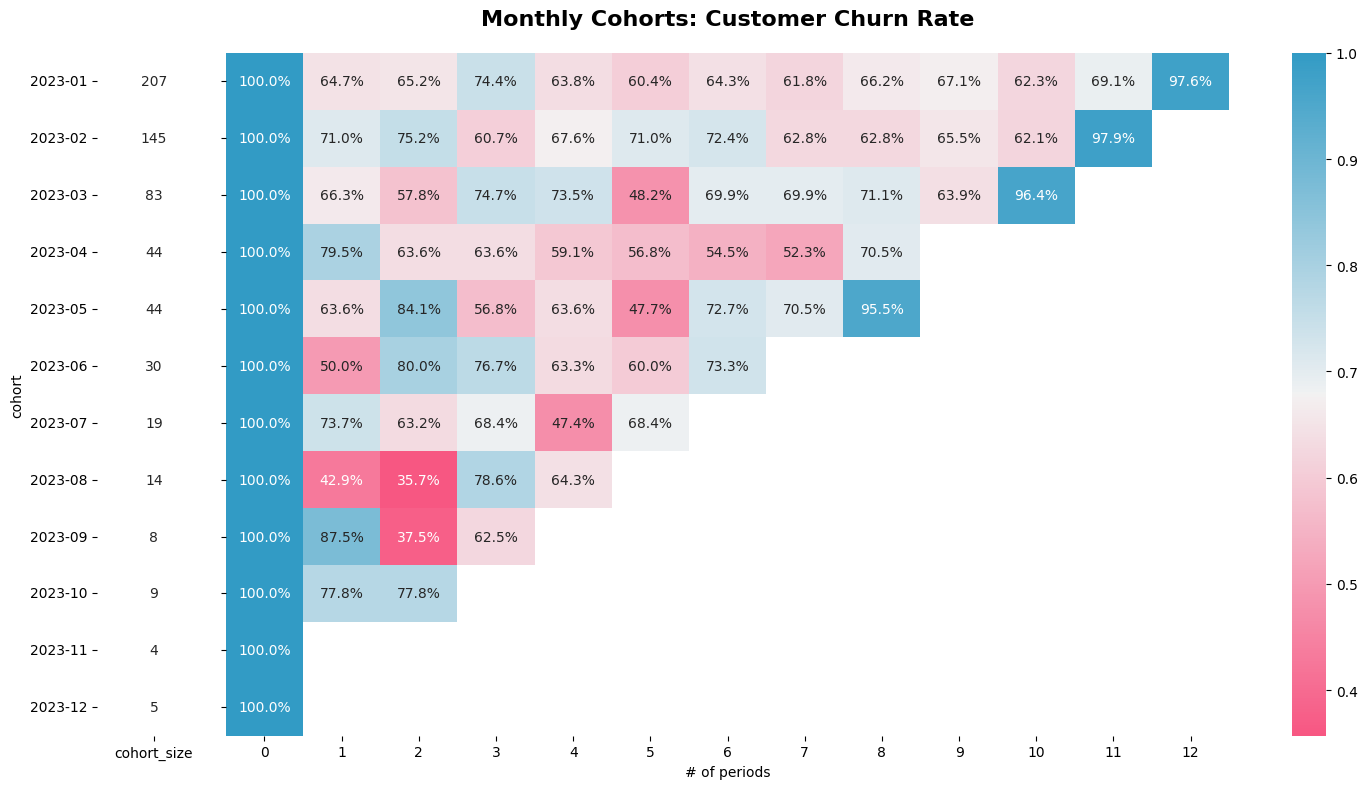

In [309]:
fig, ax = plt.subplots(1, 2, figsize=(15, 8), sharey=True, gridspec_kw={"width_ratios": [1, 11]})
cmap = sns.diverging_palette(0, 230, 90, 60, as_cmap=True)
# retention matrix
sns.heatmap(churn_rate_matrix, mask=churn_rate_matrix.isnull(), annot=True, fmt=".1%", cmap=cmap, ax=ax[1])
ax[1].set_title("Monthly Cohorts: Customer Churn Rate", fontsize=16, pad=20, weight="bold")
ax[1].set(xlabel="# of periods", ylabel="")

# cohort size
cohort_size_df = pd.DataFrame(cohort_size).rename(columns={0: "cohort_size"})
white_cmap = mcolors.ListedColormap(["white"])
sns.heatmap(cohort_size_df, annot=True, cbar=False, fmt="g", cmap=white_cmap, ax=ax[0])

plt.tight_layout()
plt.show()

### Cohort Retention & Churn Analysis

**1. Customer Retention**

* **Low and declining retention rates:**

  * After the first month, retention drops sharply. Many cohorts retain only **20–40% of customers** in months 1–2.
  * Example: The **2023-01 cohort** started with 207 customers, but by month 2 only **73 customers (35.3%)** remained active, and it fell below 10% in later months.

* **Recent cohorts show no significant improvement:**

  * Mid-2023 cohorts such as **2023-06, 2023-07, and 2023-08** maintained retention rates of **20–50%** in early periods but declined quickly afterward.

* **Key takeaway:**

  * Very few customers maintain continuous transactions across multiple months.
  * The overall pattern shows most customers transact **only once or twice** before leaving.

**2. Customer Churn**

* **High churn rates:**

  * Immediately after the first month, churn typically exceeds **60–70%**, meaning the majority of customers never return.
  * Example: The **2023-01 cohort** had 207 customers, but **134 (\~65%) churned** by the next month.

* **Consistent trend across cohorts:**

  * More recent cohorts (Q3–Q4/2023) follow the same pattern: within 2–3 months, nearly all customers churn.

* **Key characteristic:**

  * Most customers generate only **a single transaction**, with very few showing long-term engagement.

**3. Overall Observations**

* **Low retention & high churn are structural patterns:**

  * The data reflects real customer behavior, where the majority **purchase once and leave**.
  * This is not a data error but a critical insight for customer lifecycle management.

* **Business implications:**

  * Building **loyal customers** is highly challenging with this dataset.
  * Strategic initiatives are required, such as:

    * **Incentives for returning customers** (discounts, loyalty points).
    * **Reactivation campaigns** targeting early churners.
    * **Personalized experiences** to encourage repeat purchases.

**In summary:**

* Cohort analysis shows that **most customers make only 1–2 transactions**.
* **Retention declines rapidly, churn rises sharply from the first month.**
* Improving performance requires **customer retention strategies**: after-sales engagement, repurchase incentives, and enhancing the overall customer journey.

## QoQ Analysis

In [310]:
df_bank_transactions_cohort["quarter"] = df_bank_transactions["TransactionDate"].dt.to_period("Q").astype(str)

quarterly_summary = df_bank_transactions_cohort.groupby("quarter").agg(
    revenue=("TransactionAmount", "sum"),
    account_count=("AccountID", "nunique")
).reset_index()

# Calculate revenue growth (QoQ growth)
quarterly_summary["qoq_growth"] = quarterly_summary["revenue"].pct_change() * 100
quarterly_summary["qoq_growth"] = quarterly_summary["qoq_growth"].round(2)
quarterly_summary["qoq_growth_label"] = quarterly_summary["qoq_growth"].apply(
    lambda x: f"+{x}%" if pd.notnull(x) and x > 0 else (f"{x}%" if pd.notnull(x) else "–")
)
quarterly_summary

,quarter,revenue,account_count,qoq_growth,qoq_growth_label
0,2023Q1,182451.26,352,NaN,–
1,2023Q2,165431.43,339,-9.33,-9.33%
2,2023Q3,203131.40,358,22.79,+22.79%
3,2023Q4,194476.18,365,-4.26,-4.26%
4,2024Q1,2065.30,13,-98.94,-98.94%


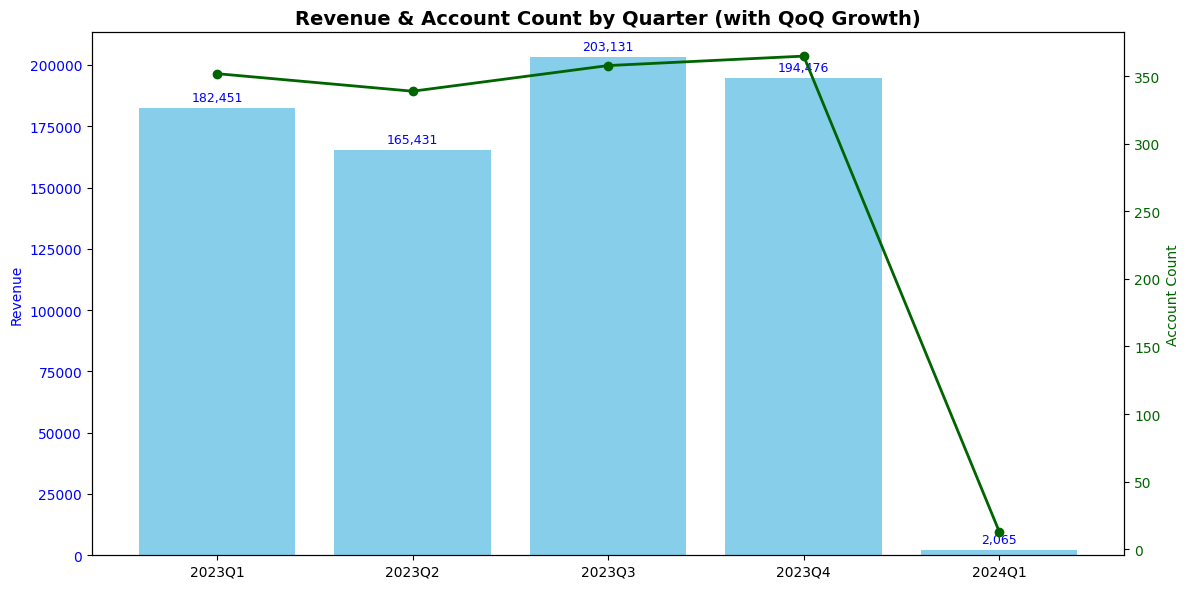

In [311]:
# Plot the chart
fig, ax1 = plt.subplots(figsize=(12, 6))

# Revenue bars
bars = ax1.bar(quarterly_summary["quarter"], quarterly_summary["revenue"],
               color="skyblue", label="Revenue")
ax1.set_ylabel("Revenue", color="blue")
ax1.tick_params(axis="y", labelcolor="blue")

# Add value labels on top of each bar
ax1.bar_label(bars, labels=[f"{v:,.0f}" for v in quarterly_summary["revenue"]],
              padding=3, fontsize=9, color="blue")

# Secondary axis for line chart (Account Count)
ax2 = ax1.twinx()
ax2.plot(quarterly_summary["quarter"], quarterly_summary["account_count"], color="darkgreen",
         marker="o", linewidth=2, label="Account Count")
ax2.set_ylabel("Account Count", color="darkgreen")
ax2.tick_params(axis="y", labelcolor="darkgreen")

# Add title and format axes
plt.title("Revenue & Account Count by Quarter (with QoQ Growth)", fontsize=14, fontweight="bold")
plt.xticks(rotation=45)
fig.tight_layout()
plt.show()

### Insights from Revenue & Account Count by Quarter

1. **Revenue Trend**

   * Revenue fluctuated throughout 2023: slight decline from **Q1 → Q2**, strong increase in **Q3**, and a small dip in **Q4**.
   * In **2024Q1**, revenue dropped almost to **zero**, likely due to incomplete or missing data.

2. **Account Count Trend**

   * Account counts remained relatively stable around **200–360 accounts** during 2023.
   * In **2024Q1**, accounts dropped sharply, almost disappearing.

3. **QoQ Growth Implications**

   * 2023 shows a generally **stable performance**, with notable growth in Q3.
   * The unusual drop in **2024Q1** is most likely caused by **data issues** rather than an actual business decline.

👉 In summary: 2023 was stable with positive growth in Q3, but **2024Q1 anomalies** indicate a need to validate the dataset.

## CLV Analysis

> **CLV = Total profit a customer generates during their relationship with the company.**
> It measures **long-term customer value** and helps optimize **marketing spend, retention, and growth strategy.**

$$
CLV = (Average Purchase Value × Gross Margin) × Purchase Frequency × Lifespan
$$

* **Average Purchase Value × Gross Margin:** Profit per purchase
* **Purchase Frequency:** How often customers buy (e.g., times per year)
* **Lifespan:** Average years a customer stays active
* **Interpretation:** Total lifetime profit from an average customer.

In [312]:
# Compute average purchase value (APV), purchase frequency, and lifespan
clv_df = df_bank_transactions.groupby("AccountID").agg(
    Total_Revenue=("TransactionAmount", "sum"),
    Num_Transactions=("TransactionID", "nunique"),
    First_Purchase=("TransactionDate", "min"),
    Last_Purchase=("TransactionDate", "max")
).reset_index()

display(clv_df.head(10))

,AccountID,Total_Revenue,Num_Transactions,First_Purchase,Last_Purchase
0,AC00001,260.76,2,2023-09-15 17:00:20,2023-11-14 16:56:34
1,AC00002,2056.21,7,2023-01-10 16:00:32,2023-12-21 17:00:50
2,AC00003,1266.34,5,2023-01-02 16:45:05,2023-10-02 18:57:19
3,AC00004,2180.08,9,2023-05-01 17:36:10,2024-01-01 16:08:49
4,AC00005,3131.77,9,2023-02-22 16:18:32,2023-12-04 18:01:53
5,AC00006,1017.72,4,2023-02-28 17:28:13,2023-10-05 16:46:31
6,AC00007,1495.38,5,2023-06-12 17:53:52,2023-11-27 17:34:33
7,AC00008,76.16,1,2023-11-21 16:45:29,2023-11-21 16:45:29
8,AC00009,984.08,5,2023-02-14 16:21:23,2023-12-25 17:19:08
9,AC00010,2768.67,7,2023-01-12 17:10:03,2023-11-30 16:52:42


Average CLV across all customers: 3800.34


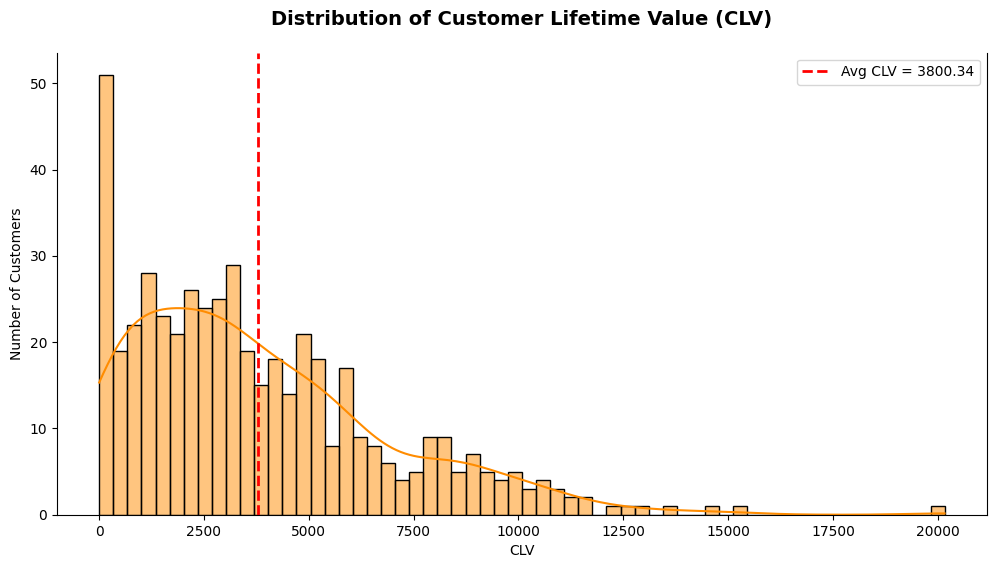

Top 10 High-Value Customers:


,AccountID,Total_Revenue,Num_Transactions,First_Purchase,Last_Purchase,APV,Frequency,Lifespan_Months,COGS,GrossMargin,CLV
455,AC00460,5570.34,12,2023-01-03 17:14:14,2024-01-01 16:45:56,464.195000,12,12.066667,3899.238,0.3,20164.6308
358,AC00363,4702.91,12,2023-01-31 17:14:32,2023-12-20 16:17:11,391.909167,12,10.733333,3292.037,0.3,15143.3702
69,AC00071,4050.12,8,2023-01-02 17:00:33,2023-12-25 17:41:30,506.265000,8,11.900000,2835.084,0.3,14458.9284
20,AC00021,4263.34,8,2023-01-23 16:03:04,2023-12-08 16:36:30,532.917500,8,10.633333,2984.338,0.3,13600.0546
300,AC00304,3651.80,11,2023-01-02 16:07:17,2023-12-20 17:13:50,331.981818,11,11.733333,2556.260,0.3,12854.3360
261,AC00265,3953.60,9,2023-01-17 16:48:10,2023-12-04 16:14:07,439.288889,9,10.666667,2767.520,0.3,12651.5200
134,AC00136,3880.53,8,2023-01-03 18:18:14,2023-11-20 16:31:36,485.066250,8,10.666667,2716.371,0.3,12417.6960
253,AC00257,3410.02,11,2023-01-02 16:27:18,2023-12-06 17:10:35,310.001818,11,11.266667,2387.014,0.3,11525.8676
19,AC00020,3788.01,9,2023-01-12 17:58:56,2023-11-13 16:46:06,420.890000,9,10.133333,2651.607,0.3,11515.5504
312,AC00316,3437.56,6,2023-01-02 16:01:14,2023-11-30 16:51:46,572.926667,6,11.066667,2406.292,0.3,11412.6992


In [313]:
# Average purchase value per transaction
clv_df["APV"] = clv_df["Total_Revenue"] / clv_df["Num_Transactions"]

# Frequency (number of transactions)
clv_df["Frequency"] = clv_df["Num_Transactions"]

# Lifespan: number of months between first and last purchase (+1 to avoid division by zero)
clv_df["Lifespan_Months"] = ((clv_df["Last_Purchase"] - clv_df["First_Purchase"]).dt.days / 30).clip(lower=1)

clv_df["COGS"] = clv_df["Total_Revenue"] * 0.7 # We assume COGS = 70% Total_Revenue.
clv_df["GrossMargin"] = (clv_df["Total_Revenue"] - clv_df["COGS"]) / clv_df["Total_Revenue"]

# Customer Lifetime Value
clv_df["CLV"] = clv_df["APV"] * clv_df["GrossMargin"] * clv_df["Frequency"] * clv_df["Lifespan_Months"]

# --- 2. Calculate the average CLV across all customers ---
avg_clv = clv_df["CLV"].mean()
print(f"Average CLV across all customers: {avg_clv:.2f}")

# --- 3. Plot CLV distribution with Seaborn ---
plt.figure(figsize=(12,6))
sns.histplot(clv_df["CLV"], bins=60, edgecolor="black", kde=True, color="darkorange")
sns.despine(top=True, right=False, left=False, bottom=False)

# Add vertical line for average CLV
plt.axvline(avg_clv, color="red", linestyle="dashed", linewidth=2, label=f"Avg CLV = {avg_clv:.2f}")

# Titles and labels
plt.title("Distribution of Customer Lifetime Value (CLV)", fontsize=14, fontweight="bold", pad=20)
plt.xlabel("CLV")
plt.ylabel("Number of Customers")
plt.legend()
plt.show()

# Display top customers with highest CLV (VIP customers)
print("Top 10 High-Value Customers:")
display(clv_df.sort_values(by="CLV", ascending=False).head(10))

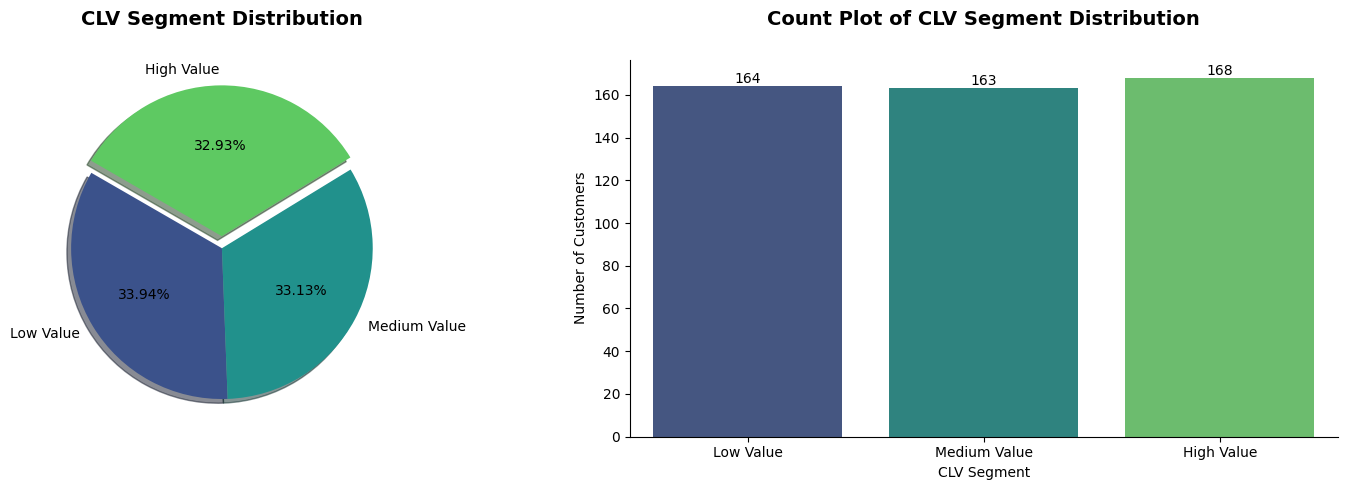

In [314]:
q33 = clv_df["CLV"].quantile(0.33)
q66 = clv_df["CLV"].quantile(0.66)

# Function to classify customers
def clv_segment(x):
    if x <= q33:
        return "Low Value"
    elif x <= q66:
        return "Medium Value"
    else:
        return "High Value"

# Add Segment column
clv_df["CLV_Segment"] = clv_df["CLV"].apply(clv_segment)

# Segment distribution
CLV_Segment_Distribution = clv_df["CLV_Segment"].value_counts()

fig, ax = plt.subplots(nrows=1, ncols=2, sharey=False, figsize=(15, 5))
n_colors = clv_df["CLV_Segment"].nunique()
viridis_colors = sns.color_palette("viridis", n_colors=n_colors)

# ax[0] – Pie chart
ax[0].pie(
    CLV_Segment_Distribution,
    labels=["Low Value", "Medium Value", "High Value"],
    colors=viridis_colors,
    autopct="%1.2f%%",
    startangle=150,
    explode=(0, 0, 0.08),
    shadow=True
)
ax[0].set_title("CLV Segment Distribution", weight="bold", fontsize=14, pad=25)

# ax[1] – Count plot
sns.countplot(
    data=clv_df,
    x="CLV_Segment",
    palette=viridis_colors,
    ax=ax[1],
    order=["Low Value", "Medium Value", "High Value"]
)
ax[1].set_title("Count Plot of CLV Segment Distribution", weight="bold", fontsize=14, pad=25)

# Add labels on top of bars
for container in ax[1].containers:
    ax[1].bar_label(container, fmt="%d", label_type="edge", fontsize=10)

ax[1].set_ylabel("Number of Customers")
ax[1].set_xlabel("CLV Segment")
sns.despine(ax=ax[1], top=True, right=True, left=False, bottom=False)

plt.tight_layout()
plt.show()


**Key Insights**

* Most customers have CLV **below average**, suggesting a need to **increase purchase frequency or order value**.
* The **High Value** group (~33%) should be the main focus for **retention and loyalty programs**.
* **Average CLV ≈ 3.8K** can serve as a **benchmark** for evaluating marketing and customer strategies.

## Let's address some questions

In [315]:
df_bank_transactions_ba = df_bank_transactions.copy()

### Transaction Amount

#### What is the distribution of high-value transactions (e.g., top 5%) across all customers by TransactionType?

Number of high-value transactions (top 5%): 126


,TransactionID,AccountID,TransactionAmount,TransactionDate,TransactionType,DeviceID,IP Address,MerchantID,Channel,CustomerAge,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance,PreviousTransactionDate,Region
74,TX000075,AC00265,1212.51,2023-10-04 16:36:29,Debit,D000231,193.83.0.183,M036,Branch,20,Student,24,1,605.95,2024-11-04 08:06:51,Midwest
82,TX000083,AC00236,922.55,2023-01-23 16:32:48,Debit,D000206,21.97.154.92,M004,ATM,63,Retired,87,1,4715.84,2024-11-04 08:11:07,Midwest
85,TX000086,AC00098,1340.19,2023-09-29 17:22:10,Credit,D000574,165.114.224.47,M012,Online,54,Engineer,30,1,8654.28,2024-11-04 08:06:53,South
110,TX000111,AC00068,1045.22,2023-11-22 16:13:39,Debit,D000400,77.7.223.184,M077,ATM,53,Retired,73,1,1829.90,2024-11-04 08:07:35,Midwest
129,TX000130,AC00320,1036.66,2023-07-11 16:39:53,Debit,D000015,53.218.177.171,M062,Branch,58,Doctor,144,1,5541.57,2024-11-04 08:09:24,South


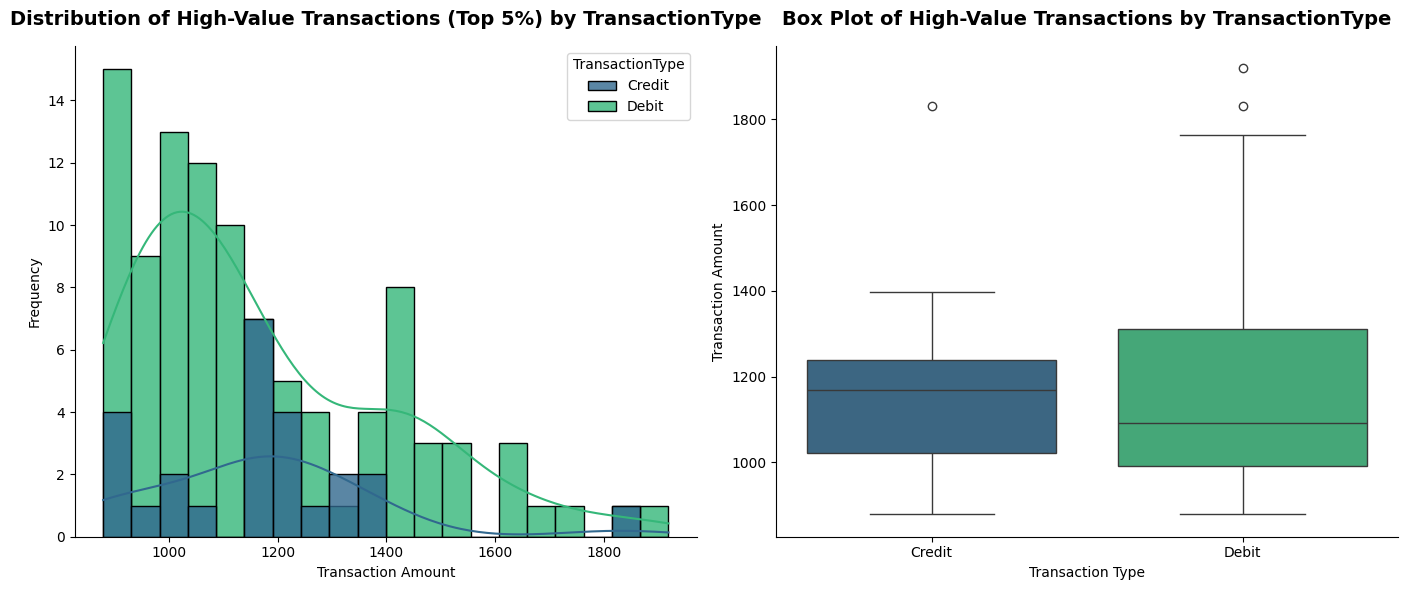

In [316]:
high_value_threshold = df_bank_transactions_ba["TransactionAmount"].quantile(0.95)
high_value_transactions = df_bank_transactions_ba[df_bank_transactions_ba["TransactionAmount"] > high_value_threshold]

print(f"Number of high-value transactions (top 5%): {len(high_value_transactions)}")
display(high_value_transactions.head())

# Plot high-value transactions
plt.figure(figsize=(14, 6))

# --- Histogram ---
plt.subplot(1, 2, 1)
sns.histplot(data=high_value_transactions, x="TransactionAmount", hue="TransactionType",
    bins=20, kde=True, palette=color(n_colors=2), alpha=0.8)
sns.despine(top=True, right=True)
plt.title("Distribution of High-Value Transactions (Top 5%) by TransactionType",
          fontsize=14, pad=15, weight="bold")
plt.xlabel("Transaction Amount")
plt.ylabel("Frequency")

# --- Boxplot ---
plt.subplot(1, 2, 2)
sns.boxplot(data=high_value_transactions, x="TransactionType", y="TransactionAmount",
    palette=color(n_colors=2))
sns.despine(top=True, right=True)
plt.title("Box Plot of High-Value Transactions by TransactionType",
          fontsize=14, pad=15, weight="bold")
plt.xlabel("Transaction Type")
plt.ylabel("Transaction Amount")

plt.tight_layout()
plt.show()

**High-Value Transaction Insights (Top 5%)**

* Total of **126 transactions** fall within the top 5% by amount.
* **Debit transactions** slightly dominate high-value activity compared to **Credit**.
* Both types show similar distributions, but **Debit** exhibits **a wider range indicating a few unusually large withdrawals.**
* Overall, high-value behavior appears **balanced across transaction types**, with **no major bias** toward Credit or Debit.

#### Are there **outliers in transaction amount** per channel (ATM, Online, Branch)?

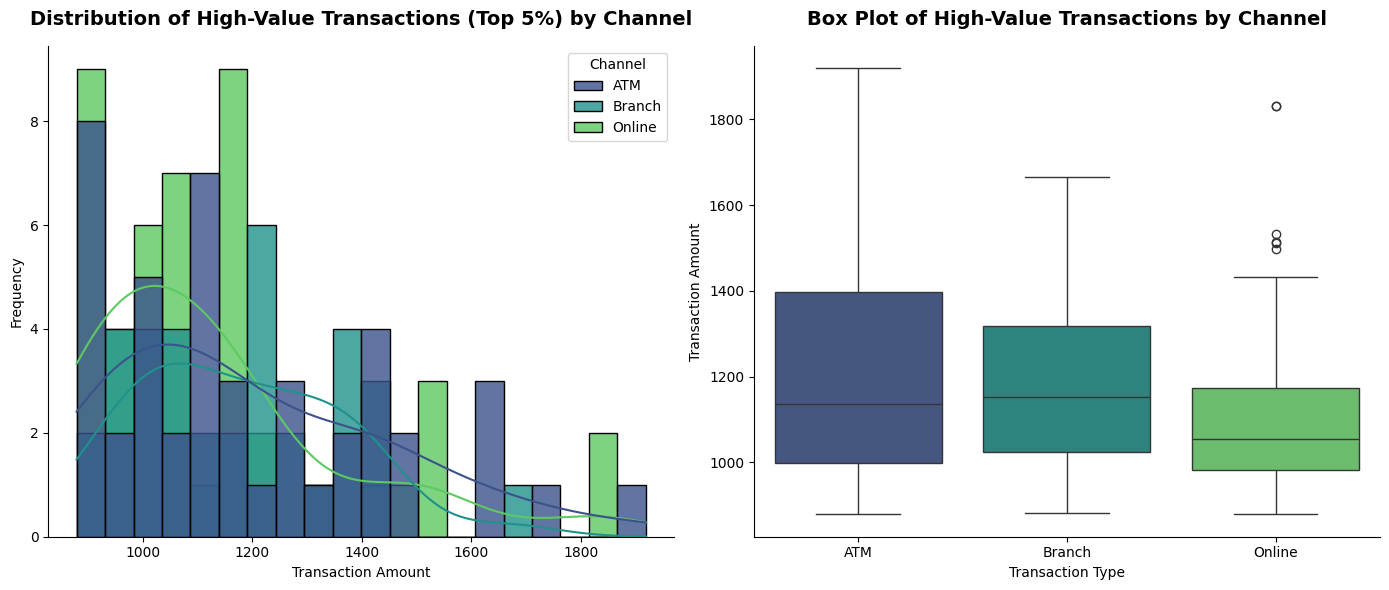

In [317]:
# Plot high-value transactions
plt.figure(figsize=(14, 6))

# --- Histogram ---
plt.subplot(1, 2, 1)
sns.histplot(data=high_value_transactions, x="TransactionAmount", hue="Channel",
    bins=20, kde=True, palette=color(n_colors=3), alpha=0.8)
sns.despine(top=True, right=True)
plt.title("Distribution of High-Value Transactions (Top 5%) by Channel",
          fontsize=14, pad=15, weight="bold")
plt.xlabel("Transaction Amount")
plt.ylabel("Frequency")

# --- Boxplot ---
plt.subplot(1, 2, 2)
sns.boxplot(data=high_value_transactions, x="Channel", y="TransactionAmount",
    palette=color(n_colors=3))
sns.despine(top=True, right=True)
plt.title("Box Plot of High-Value Transactions by Channel",
          fontsize=14, pad=15, weight="bold")
plt.xlabel("Transaction Type")
plt.ylabel("Transaction Amount")

plt.tight_layout()
plt.show()

**High-Value Transactions by Channel**

* **ATM** transactions show the **widest range** and **highest upper values**, including some extreme outliers.
* **Branch** transactions have a **moderate spread**, centered around 1,200.
* **Online** transactions are slightly **lower in value** and **more concentrated**, with several small outliers.
* Overall, **ATM appears most variable**, suggesting it could carry **a higher anomaly risk** among high-value transactions.

#### What is the distribution of time differences between frequent transactions?

Number of frequent transactions (within 1 hour 30 min): 29


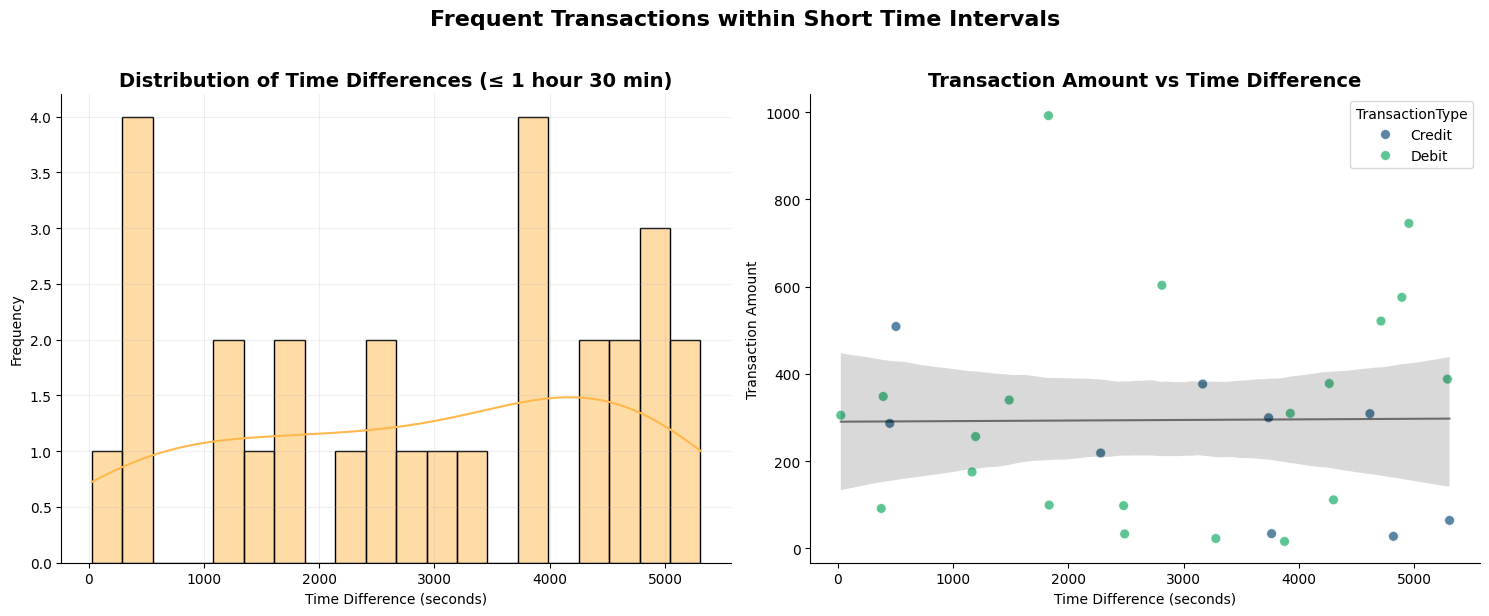

In [318]:
# Sort and compute time differences
df_sorted = df_bank_transactions_ba.sort_values(by=["AccountID", "TransactionDate"])
df_sorted["TimeDifference"] = df_sorted.groupby("AccountID")["TransactionDate"].diff().dt.total_seconds()

# Identify frequent transactions with short intervals
short_interval_threshold = 5400  # 1 hour 30 min in seconds
frequent_transactions = df_sorted[df_sorted["TimeDifference"] <= short_interval_threshold]
print(f"Number of frequent transactions (within 1 hour 30 min): {len(frequent_transactions)}")

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# --- Histogram: Distribution of Time Differences
sns.histplot(data=frequent_transactions, x="TimeDifference", bins=20, kde=True, color="#FFB84C", ax=axes[0])
axes[0].set_title("Distribution of Time Differences (≤ 1 hour 30 min)", fontsize=14, weight="bold")
axes[0].set_xlabel("Time Difference (seconds)")
axes[0].set_ylabel("Frequency")
axes[0].grid(alpha=0.2)
sns.despine(ax=axes[0], top=True, right=True)

# --- Regression: Amount vs TimeDifference
sns.scatterplot(data=frequent_transactions, x="TimeDifference", y="TransactionAmount", hue="TransactionType", palette=color(n_colors=2),
    alpha=0.8,s=50, ax=axes[1])
sns.regplot(data=frequent_transactions, x="TimeDifference", y="TransactionAmount", scatter=False, ax=axes[1], color="black", 
            line_kws={"linewidth": 1.5, "alpha": 0.5}, marker="o", scatter_kws={"color": "#FF6F00", "alpha": 0.7, "s": 50})
axes[1].set_title("Transaction Amount vs Time Difference", fontsize=14, weight="bold")
axes[1].set_xlabel("Time Difference (seconds)")
axes[1].set_ylabel("Transaction Amount")
sns.despine(ax=axes[1], top=True, right=True)

plt.suptitle("Frequent Transactions within Short Time Intervals", fontsize=16, weight="bold", y=1.02)
plt.tight_layout()
plt.show()

**Key Insights:**

* Many transactions occur within **5–10 minutes**, indicating **rapid repeated activity**.
* The regression plot shows **no strong correlation** between *Transaction Amount* and *Time Difference*.
* Both **Credit and Debit** transactions are **scattered randomly**, though a few **high-value transactions** still appear in short intervals.

### Balance Behavior

#### What is the overall **distribution of balance changes** across customers?

Number of transactions with large balance changes: 105


,TransactionID,AccountID,TransactionAmount,TransactionDate,TransactionType,DeviceID,IP Address,MerchantID,Channel,CustomerAge,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance,PreviousTransactionDate,Region,BalanceChange
1167,TX001168,AC00010,838.57,2023-06-26 16:08:25,Debit,D000430,115.30.82.168,M040,ATM,41,Doctor,273,1,14576.47,2024-11-04 08:11:25,West,12970.80
519,TX000520,AC00014,121.91,2023-06-26 18:39:52,Debit,D000264,135.29.211.116,M015,Branch,60,Doctor,133,1,14510.80,2024-11-04 08:08:59,Midwest,14118.46
2086,TX002087,AC00029,1192.95,2023-12-04 18:30:00,Debit,D000227,71.93.189.160,M068,Branch,23,Student,73,1,325.15,2024-11-04 08:08:01,West,-14064.30
1589,TX001590,AC00035,70.88,2023-12-04 16:18:39,Credit,D000315,169.67.220.37,M087,Branch,74,Retired,176,1,1794.65,2024-11-04 08:06:26,Midwest,-13038.69
180,TX000181,AC00036,740.25,2023-07-19 17:03:58,Debit,D000030,1.198.76.182,M010,Online,41,Doctor,123,1,14464.30,2024-11-04 08:08:27,Northeast,12789.36


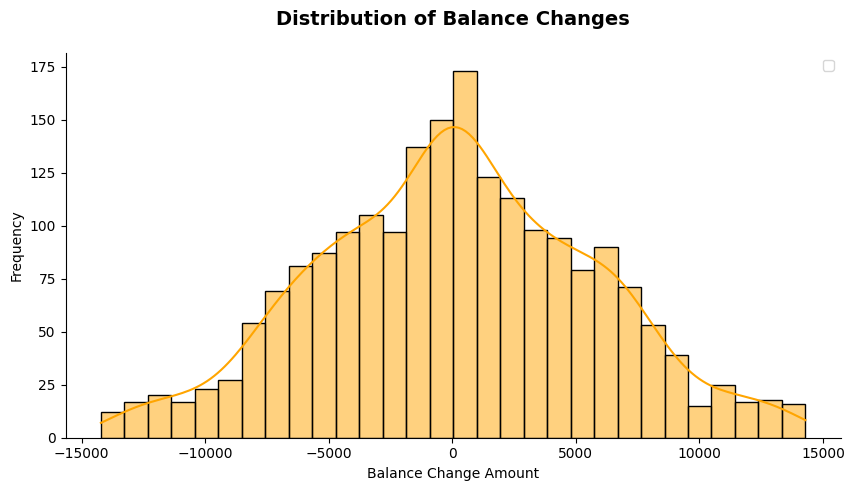

In [319]:
# Calculate balance change = current balance - previous balance
df_sorted = df_bank_transactions_ba.sort_values(by=["AccountID", "TransactionDate"])
df_sorted["BalanceChange"] = df_sorted.groupby("AccountID")["AccountBalance"].diff()

# Identify large balance changes based on threshold (e.g., 2 standard deviations)
balance_change_threshold = df_sorted["BalanceChange"].mean() + 2 * df_sorted["BalanceChange"].std()
large_balance_changes = df_sorted[df_sorted["BalanceChange"].abs() > balance_change_threshold]
print(f"Number of transactions with large balance changes: {len(large_balance_changes)}")
display(large_balance_changes.head())

# 4. Visualization
plt.figure(figsize=(10, 5))
sns.histplot(df_sorted["BalanceChange"], bins=30, kde=True, color="orange")
sns.despine(top=True, right=True, left=False, bottom=False)

plt.title("Distribution of Balance Changes", fontsize=14, pad=20, weight="bold")
plt.xlabel("Balance Change Amount")
plt.ylabel("Frequency")
plt.legend()
plt.show()

* The distribution is **roughly symmetric but slightly left-skewed**, showing **more frequent withdrawals**.

#### Which accounts show **sudden large increases or decreases** in balance?

In [320]:
# Calculate balance change = current balance - previous balance
df_sorted = df_bank_transactions_ba.sort_values(by=["AccountID", "TransactionDate"])
df_sorted["BalanceChange"] = df_sorted.groupby("AccountID")["AccountBalance"].diff()

# Threshold for identifying large balance fluctuations (e.g., ±1.5 standard deviations)
threshold = 1.5 * df_sorted["BalanceChange"].std()

sudden_changes = df_sorted[
    (df_sorted["BalanceChange"].abs() >= threshold)
][["AccountID", "TransactionDate", "BalanceChange"]]

# View top accounts with the most significant balance changes
top_account = (
        sudden_changes.groupby("AccountID", as_index=False)
        .agg(TxChange = ("BalanceChange", "count")).sort_values(by="TxChange", ascending=False).head(10))

# Identify accounts with unusually frequent small transactions (e.g., ≥3)
suspicious_change_tx = top_account[top_account["TxChange"] >= 3].reset_index(drop=True)

# Output
print(f"Threshold for identifying large balance fluctuations: {threshold:.2f}")
print(f"Total transactions: {len(sudden_changes)}")
print(f"Number of suspicious accounts (≥3): {len(suspicious_change_tx)}")

display(suspicious_change_tx.head(5))

Threshold for identifying large balance fluctuations: 8385.34
Total transactions: 257
Number of suspicious accounts (≥3): 10


,AccountID,TxChange
0,AC00430,4
1,AC00035,4
2,AC00431,4
3,AC00322,4
4,AC00233,4


**Unusual Balance Fluctuations**

* Detection threshold: **±8,385** (≈ 1.5 standard deviations).
* **257 transactions** exceeded this threshold.
* **10 accounts** showed **≥3 major fluctuations**, notably **AC00430, AC00335, and AC00431** (4 each).
* Indicates **unusual cash flow movements**, possibly linked to **suspicious transaction behavior**.

#### Are there **patterns of repeated small withdrawals/deposits** that look unusual?

In [321]:
df_sorted = df_bank_transactions_ba.sort_values(by=["AccountID", "TransactionDate"])
# Define threshold for "small transactions" (e.g., below mean - 1 std)
threshold_small = df_sorted["TransactionAmount"].quantile(0.25)

# Filter only small transactions
small_tx = df_sorted[(df_sorted["TransactionAmount"] <= threshold_small)]

# Count number of small transactions per account
small_tx_count = (
    small_tx.groupby("AccountID", as_index=False)
    .agg(SmallTxCount=("TransactionID", "count"))
    .sort_values(by="SmallTxCount", ascending=False)
)

# Identify accounts with unusually frequent small transactions (e.g., ≥4)
suspicious_small_tx = small_tx_count[small_tx_count["SmallTxCount"] >= 4].reset_index(drop=True)

# Output
print(f"Threshold for small transactions: {threshold_small:.2f}")
print(f"Total small transactions: {len(small_tx)}")
print(f"Number of suspicious accounts (≥4 small transactions): {len(suspicious_small_tx)}")

display(suspicious_small_tx.head(5))

Threshold for small transactions: 81.89
Total small transactions: 628
Number of suspicious accounts (≥4 small transactions): 19


,AccountID,SmallTxCount
0,AC00261,5
1,AC00056,4
2,AC00456,4
3,AC00452,4
4,AC00063,4


**Insight: Repeated Small Transactions**

* Using the **25th percentile (≈ 81.89)** as the threshold for “small transactions”, a total of **628 small-value transactions** were identified.
* **19 accounts** show **≥4 small transactions**, indicating **repeated low-value activity** within the dataset.
* These accounts may represent **potential structuring behavior** — splitting larger amounts into multiple smaller transactions to avoid detection.

#### Do large balance changes happen more often in **specific regions or times of day**?

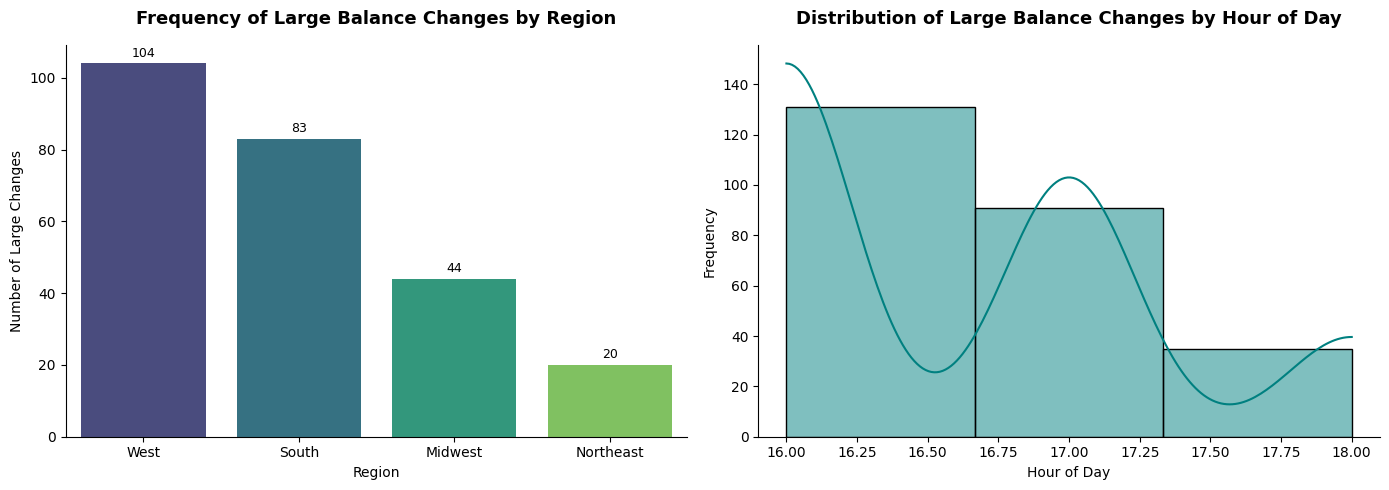

In [322]:
# Calculate balance change = current balance - previous balance
df_sorted = df_bank_transactions_ba.sort_values(by=["AccountID", "TransactionDate"])
df_sorted["BalanceChange"] = df_sorted.groupby("AccountID")["AccountBalance"].diff()

# Threshold for identifying large balance fluctuations (e.g., ±1.5 standard deviations)
threshold = 1.5 * df_sorted["BalanceChange"].std()

# Step 1: Filter only large balance change transactions
large_changes = df_sorted[
    df_sorted["BalanceChange"].abs() >= threshold
].copy()

# Extract hour of transaction
large_changes["Hour"] = pd.to_datetime(large_changes["TransactionDate"]).dt.hour

# --- Create subplot ---
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(14, 5))

# --- (1) Plot by Region ---
sns.countplot(data=large_changes, x="Region", order=large_changes["Region"].value_counts().index, palette="viridis", ax=ax[0])
ax[0].set_title("Frequency of Large Balance Changes by Region", fontsize=13, weight="bold", pad=15)
ax[0].set_xlabel("Region")
ax[0].set_ylabel("Number of Large Changes")
sns.despine(ax=ax[0], top=True, right=True)

# Add value labels on bars
for p in ax[0].patches:
    height = p.get_height()
    ax[0].text(p.get_x() + p.get_width() / 2, height + 1,
        f"{int(height)}", ha="center", va="bottom", fontsize=9)

# --- (2) Plot by Hour of Day ---
sns.histplot(data=large_changes, x="Hour", bins=3, kde=True, color="teal", ax=ax[1])
ax[1].set_title("Distribution of Large Balance Changes by Hour of Day", fontsize=13, weight="bold", pad=15)
ax[1].set_xlabel("Hour of Day")
ax[1].set_ylabel("Frequency")
sns.despine(ax=ax[1], top=True, right=True)

# --- Final Layout ---
plt.tight_layout()
plt.show()

**Insight: Large Balance Changes by Region & Time of Day**

* Most large balance fluctuations occur in the **West (104)** and **South (83)** regions, indicating regional transaction concentration.
* Activity peaks between **16:00–18:00**, suggesting end-of-day or batch transaction behavior.
* These spatiotemporal patterns could point to **regional or timing-based transaction anomalies**.

### Temporal Patterns

#### What is the **average time interval** between consecutive transactions per account?

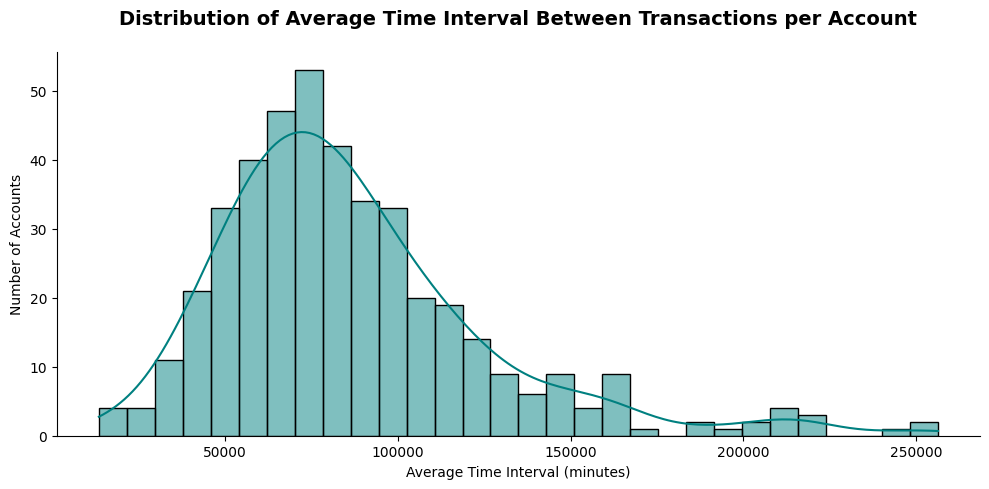

In [323]:
# Ensure TransactionDate is in datetime format
df_bank_transactions_ba["TransactionDate"] = pd.to_datetime(df_bank_transactions_ba["TransactionDate"])

# Sort data by AccountID and TransactionDate
df_sorted = df_bank_transactions_ba.sort_values(by=["AccountID", "TransactionDate"])

# Compute the time difference (in minutes) between consecutive transactions for each account
df_sorted["TimeDiff_Minutes"] = (
    df_sorted.groupby("AccountID")["TransactionDate"].diff().dt.total_seconds() / 60
)

# Keep only accounts with at least 3 transactions
active_ids = df_sorted["AccountID"].value_counts()
active_ids = active_ids[active_ids >= 3].index
df_active = df_sorted[df_sorted["AccountID"].isin(active_ids)]

# Calculate the average time difference between transactions per account
avg_time_diff = (
    df_active.groupby("AccountID", as_index=False)
    .agg(AvgTimeDiff_Minutes=("TimeDiff_Minutes", "mean"))
)

# --- Visualization ---
plt.figure(figsize=(10, 5))
sns.histplot(avg_time_diff["AvgTimeDiff_Minutes"], bins=30, kde=True, color="teal")
plt.title("Distribution of Average Time Interval Between Transactions per Account", fontsize=14, weight="bold", pad=20)
plt.xlabel("Average Time Interval (minutes)")
plt.ylabel("Number of Accounts")
sns.despine(top=True, right=True)
plt.tight_layout()
plt.show()

**Insight: Transaction Time Intervals**

* The average time between transactions varies widely across accounts, with a strong right-skewed distribution.
* Most accounts show intervals between **40,000 and 100,000 minutes** (≈ 1–2 months), indicating infrequent transactions.
* A few accounts have **much longer gaps**, suggesting inactive or dormant customers.
* No accounts show extremely short intervals, implying **no high-frequency or automated transaction behavior**.

#### Are there **clusters of transactions occurring within seconds/minutes**, suggesting automated behavior?

In [324]:
# Sort data by AccountID and TransactionDate
df_sorted = df_bank_transactions_ba.sort_values(by=["AccountID", "TransactionDate"])

# Compute the time difference (in minutes) between consecutive transactions for each account
df_sorted["TimeDiff_Second"] = (
    df_sorted.groupby("AccountID")["TransactionDate"].diff().dt.total_seconds()
)

# Identify potential automated behavior: multiple transactions within < 60 seconds
auto_clusters = df_sorted[df_sorted["TimeDiff_Second"] <= 60]

print(f"Number of potential automated transactions: {len(auto_clusters)}")
display(auto_clusters.head())

df_sorted[df_sorted["AccountID"] == "AC00151"][["TransactionID", "TransactionDate", "TransactionAmount", "TransactionDuration"]]

Number of potential automated transactions: 1


,TransactionID,AccountID,TransactionAmount,TransactionDate,TransactionType,DeviceID,IP Address,MerchantID,Channel,CustomerAge,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance,PreviousTransactionDate,Region,TimeDiff_Second
1746,TX001747,AC00151,305.18,2023-06-05 17:48:33,Debit,D000699,93.146.251.20,M065,Online,58,Retired,216,1,4474.2,2024-11-04 08:08:22,Midwest,26.0


,TransactionID,TransactionDate,TransactionAmount,TransactionDuration
1909,TX001910,2023-01-26 16:13:15,301.47,291
1241,TX001242,2023-05-19 16:44:53,168.11,12
1054,TX001055,2023-06-05 17:48:07,382.07,147
1746,TX001747,2023-06-05 17:48:33,305.18,216


> Only **one account (`AC00151`)** exhibited transactions occurring within **60 seconds**, suggesting **no strong evidence of automated or bot-like behavior** in the dataset.

#### Do unusual transactions happen more often **at night or weekends**?

In [325]:
# Sort data by AccountID and TransactionDate
df_sorted = df_bank_transactions_ba.sort_values(by=["AccountID", "TransactionDate"])

# --- Create time-based features ---
df_sorted["Hour"] = df_sorted["TransactionDate"].dt.hour
df_sorted["DayOfWeek"] = df_sorted["TransactionDate"].dt.dayofweek  # 0 = Monday, 6 = Sunday
df_sorted["IsWeekend"] = df_sorted["DayOfWeek"].isin([5, 6])
df_sorted["IsNight"] = df_sorted["Hour"].between(22, 5, inclusive="both")

# --- Filter unusual transactions (based on an existing variable, e.g., BalanceChange or TransactionAmount) ---
threshold = df_sorted["TransactionAmount"].quantile(0.95)
unusual_tx = df_sorted[df_sorted["TransactionAmount"] >= threshold]

# --- Calculate time-based frequency ratios ---
night_ratio = unusual_tx["IsNight"].mean()
weekend_ratio = unusual_tx["IsWeekend"].mean()

print(f"Percentage of unusual transactions occurring at night: {night_ratio:.2%}")
print(f"Percentage of unusual transactions occurring on weekends: {weekend_ratio:.2%}")

Percentage of unusual transactions occurring at night: 0.00%
Percentage of unusual transactions occurring on weekends: 0.00%


#### Are there **seasonal or weekday trends** for suspicious transactions?

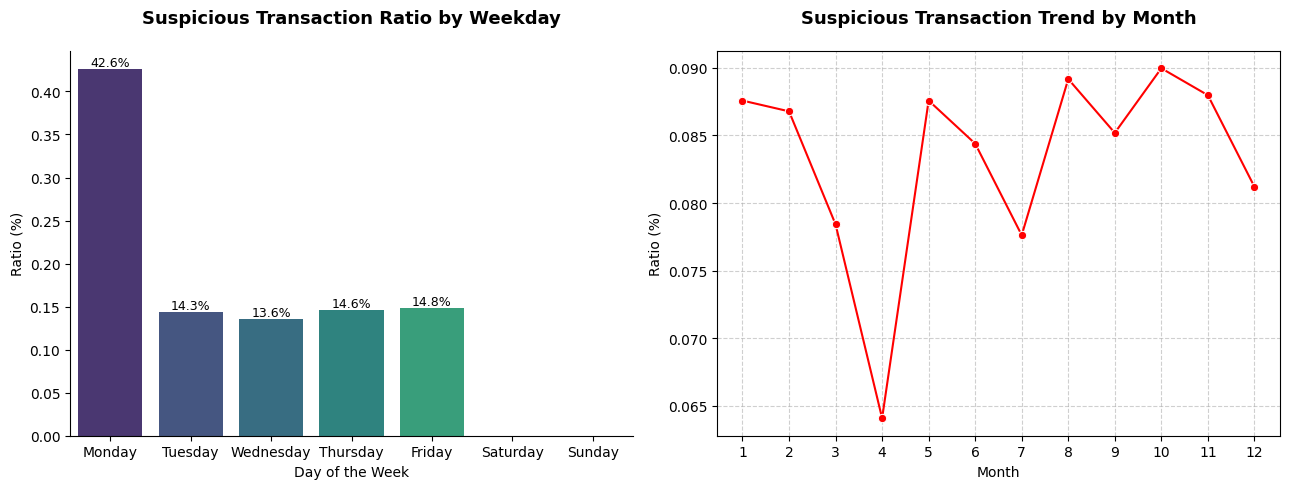

In [326]:
# Sort data by AccountID and TransactionDate
df_sorted = df_bank_transactions_ba.sort_values(by=["AccountID", "TransactionDate"])

# --- Extract weekday and month ---
df_sorted["DayOfWeek"] = df_sorted["TransactionDate"].dt.day_name()
df_sorted["Month"] = df_sorted["TransactionDate"].dt.month

# --- Calculate ratios ---
weekday_ratio = df_sorted["DayOfWeek"].value_counts(normalize=True)
month_ratio = df_sorted["Month"].value_counts(normalize=True).sort_index()

# --- Define order for weekdays ---
order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]

# --- Create subplots ---
fig, ax = plt.subplots(1, 2, figsize=(13, 5))
plt.subplots_adjust(hspace=0.4)

# --- Plot 1: Weekday distribution ---
sns.barplot(x=weekday_ratio.index, y=weekday_ratio.values, order=order, ax=ax[0], errorbar="ci", palette="viridis")
sns.despine(ax=ax[0])
# --- Add percentage labels on bars ---
for p in ax[0].patches:
    height = p.get_height()
    ax[0].annotate(f"{height*100:.1f}%",
                     (p.get_x() + p.get_width() / 2., height),
                     ha="center", va="bottom", fontsize=9, color="black")

ax[0].set_title("Suspicious Transaction Ratio by Weekday", fontsize=13, fontweight="bold", pad=20)
ax[0].set_xlabel("Day of the Week")
ax[0].set_ylabel("Ratio (%)")

# --- Plot 2: Monthly distribution ---
sns.lineplot(x=month_ratio.index, y=month_ratio.values, marker="o", ax=ax[1], color="red")
ax[1].set_title("Suspicious Transaction Trend by Month", fontsize=13, fontweight="bold", pad=20)
ax[1].set_xlabel("Month")
ax[1].set_ylabel("Ratio (%)")
ax[1].set_xticks(range(1, 13))
ax[1].grid(True, linestyle="--", alpha=0.6)

# --- Show combined figure ---
plt.tight_layout()
plt.show()

**Trends in Suspicious Transactions**

**Weekday Pattern**

* Highest on **Monday (≈42.6%)**, much higher than other days.
* **Tue–Fri** stable around 14–15%.
* **Weekend** nearly no suspicious activity.
  → Likely due to **post-weekend backlog** or system activity resuming on Monday.

**Monthly Pattern**

* Overall stable (6–9%) with a **dip in April** and **peak around Aug–Oct**.
  → Suggests **seasonal spending behavior** or **business cycle effects**.

**Insight**
Suspicious transactions concentrate **early in the week** and **late in the year**, hinting at **operational or behavioral seasonality**.

### Channel & Device Analysis

#### Are there customers using **multiple new DeviceIDs or IPs** in a short period?

In [327]:
# Sort data by AccountID and TransactionDate
df_sorted = df_bank_transactions_ba.sort_values(by=["AccountID", "TransactionDate"])

# --- Define "short period" (e.g., within 1 day or 2 hours) ---
df_sorted["PrevDate"] = df_sorted.groupby("AccountID")["TransactionDate"].shift(1)
df_sorted["TimeDiff_Hours"] = (df_sorted["TransactionDate"] - df_sorted["PrevDate"]).dt.total_seconds() / 3600

# --- Identify accounts with multiple new DeviceIDs/IPs in short time ---
def detect_device_ip_change(group, time_threshold=2):
    """Return True if the account changes DeviceID or IP within < time_threshold hours"""
    changed = (
        (group["DeviceID"] != group["DeviceID"].shift(1)) |
        (group["IP Address"] != group["IP Address"].shift(1))
    ) & (group["TimeDiff_Hours"] <= time_threshold)
    return changed.sum()

# Apply detection per account
device_ip_change = (
    df_sorted.groupby("AccountID")
    .apply(detect_device_ip_change)
    .reset_index(name="RapidDeviceIPChanges")
)

# Accounts with at least 2 rapid device/IP changes
suspicious_accounts = device_ip_change[device_ip_change["RapidDeviceIPChanges"] >= 2]
print(f"Suspicious accounts: {len(suspicious_accounts)}")
if len(suspicious_accounts) > 0:
    display(suspicious_accounts.head())

Suspicious accounts: 0


> No accounts were found switching to multiple new DeviceIDs or IPs within short periods (<2 hours).
> → This suggests **consistent login behavior** across customers, with **no signs of automated or account-sharing activity**.

#### Does a customer suddenly switch **from Branch to Online or ATM** unexpectedly?

In [328]:
# Sort data by AccountID and TransactionDate
df_sorted = df_bank_transactions_ba.sort_values(by=["AccountID", "TransactionDate"])

df_sorted["PrevChannel"] = df_sorted.groupby("AccountID")["Channel"].shift(1)
df_sorted["SwitchType"] = df_sorted["PrevChannel"].astype(str) + " -> " + df_sorted["Channel"].astype(str)

# --- Define "short period" (e.g., within 1 day or 2 hours) ---
df_sorted["PrevDate"] = df_sorted.groupby("AccountID")["TransactionDate"].shift(1)
df_sorted["TimeDiff_Hours"] = (df_sorted["TransactionDate"] - df_sorted["PrevDate"]).dt.total_seconds() / 3600

suspicious_switch = df_sorted[
    (df_sorted["SwitchType"].isin(["Branch -> Online", "Branch -> ATM"])) &
    (df_sorted["TimeDiff_Hours"] <= 24)  # Occur in 1 day.
]

switch_summary = suspicious_switch[(suspicious_switch["SwitchType"] == "Branch -> Online") |
                  (suspicious_switch["SwitchType"] == "Branch -> ATM")][["AccountID", "TransactionID", "PrevChannel", 
                                                    "Channel", "SwitchType"]].reset_index(drop=True)
print(f"Number customer switch channel : {len(switch_summary)}")
display(switch_summary.head())

Number customer switch channel : 16


,AccountID,TransactionID,PrevChannel,Channel,SwitchType
0,AC00054,TX002470,Branch,Online,Branch -> Online
1,AC00076,TX000831,Branch,ATM,Branch -> ATM
2,AC00150,TX000585,Branch,ATM,Branch -> ATM
3,AC00151,TX001747,Branch,Online,Branch -> Online
4,AC00164,TX000742,Branch,ATM,Branch -> ATM


> Around **3% of customers** switched from **Branch to Online/ATM** in a short period —> potentially signaling **behavioral anomalies** or **early signs of digital fraud**.

#### Which **channels** (ATM/Online/Branch) are associated with the **largest anomalies** in amount or duration?

Number of anomalous transactions: 250
Amount threshold (95th percentile): 878.18
Duration threshold (95th percentile): 265.00



,Channel,AvgAmount,MedianAmount,MaxAmount,AvgDuration,MedianDuration,MaxDuration,Count
0,Online,688.963111,880.285,1831.02,193.622222,253.0,300,90
1,ATM,738.663647,885.330,1919.11,191.741176,248.0,300,85
2,Branch,681.003733,734.860,1664.33,215.746667,268.0,298,75


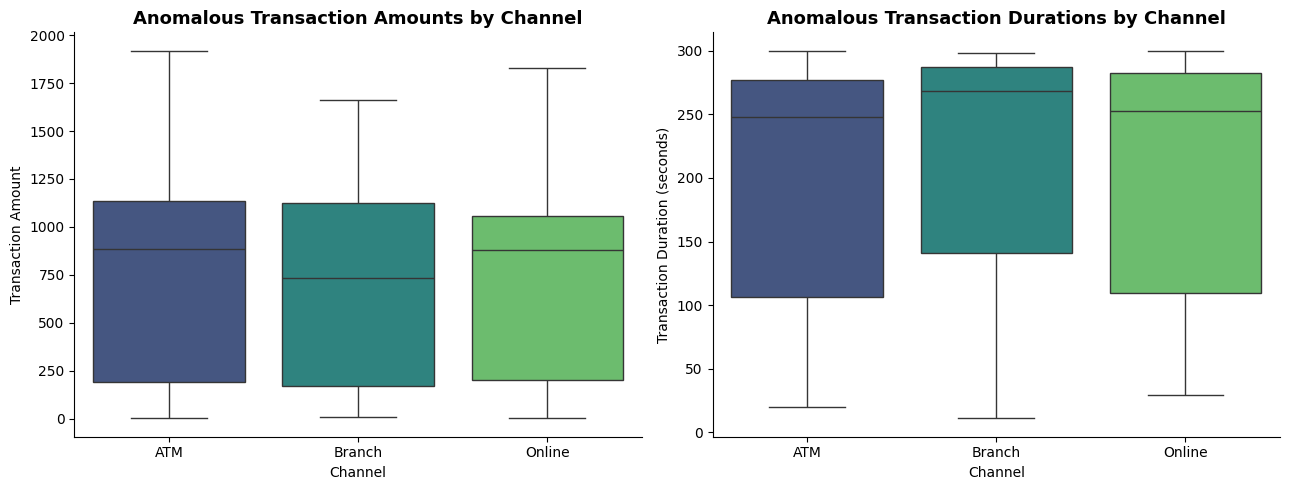

In [329]:
# Sort data by AccountID and TransactionDate
df_sorted = df_bank_transactions_ba.sort_values(by=["AccountID", "TransactionDate"])

# --- Step 1: Define anomaly thresholds ---
amount_threshold = df_sorted["TransactionAmount"].quantile(0.95)
duration_threshold = df_sorted["TransactionDuration"].quantile(0.95)

# --- Step 2: Filter anomalous transactions ---
anomalies = df_sorted[
    (df_sorted["TransactionAmount"] >= amount_threshold) |
    (df_sorted["TransactionDuration"] >= duration_threshold)
].copy()

print(f"Number of anomalous transactions: {len(anomalies)}")
print(f"Amount threshold (95th percentile): {amount_threshold:.2f}")
print(f"Duration threshold (95th percentile): {duration_threshold:.2f}\n")

# --- Step 3: Summarize anomalies by Channel ---
channel_summary = (
    anomalies.groupby("Channel")
    .agg(
        AvgAmount=("TransactionAmount", "mean"),
        MedianAmount=("TransactionAmount", "median"),
        MaxAmount=("TransactionAmount", "max"),
        AvgDuration=("TransactionDuration", "mean"),
        MedianDuration=("TransactionDuration", "median"),
        MaxDuration=("TransactionDuration", "max"),
        Count=("TransactionID", "count")
    )
    .sort_values(by="Count", ascending=False)
    .reset_index()
)

display(channel_summary.head(10))

# --- Step 4: Visualization ---
fig, ax = plt.subplots(1, 2, figsize=(13, 5))

# Left: Transaction Amount anomalies by channel
order_channels = ["ATM", "Branch", "Online"]
sns.boxplot(data=anomalies, x="Channel", y="TransactionAmount", palette="viridis", ax=ax[0],
               order=order_channels)
ax[0].set_title("Anomalous Transaction Amounts by Channel", fontsize=13, weight="bold")
ax[0].set_xlabel("Channel")
ax[0].set_ylabel("Transaction Amount")

# Right: Transaction Duration anomalies by channel
sns.boxplot(data=anomalies, x="Channel", y="TransactionDuration", palette="viridis", ax=ax[1],
               order=order_channels)
ax[1].set_title("Anomalous Transaction Durations by Channel", fontsize=13, weight="bold")
ax[1].set_xlabel("Channel")
ax[1].set_ylabel("Transaction Duration (seconds)")

sns.despine(top=True, right=True)
plt.tight_layout()
plt.show()

> **Digital channels (ATM & Online)** are more associated with large or long-duration anomalies —
> implying greater **operational risk and fraud exposure** compared to in-branch transactions.

#### Are there IPs or devices **shared by multiple accounts**?

In [330]:
# Sort data by AccountID and TransactionDate
df_sorted = df_bank_transactions_ba.sort_values(by=["AccountID", "TransactionDate"])

# --- Step 1: Define anomaly thresholds (top 5% by amount / duration) ---
amount_threshold = df_sorted["TransactionAmount"].quantile(0.95)
duration_threshold = df_sorted["TransactionDuration"].quantile(0.95)

print(f"💰 Amount threshold (95th percentile): {amount_threshold:.2f}")
print(f"⏱️ Duration threshold (95th percentile): {duration_threshold:.2f}")

# --- Step 2: Keep only anomalous transactions (amount OR duration above threshold) ---
anomalies = df_sorted[
    (df_sorted["TransactionAmount"] >= amount_threshold) |
    (df_sorted["TransactionDuration"] >= duration_threshold)
].copy()

# --- Step 3: Aggregate anomalies by IP ---
# NOTE: 'count' below counts number of TRANSACTIONS, not unique accounts
ip_summary = (
    anomalies.groupby(["IP Address"])
    .agg(
            CountAccount=("AccountID", "count"),
            TxCount = ("TransactionID", "count")
        ) # number of anomalous rows per IP
    .query("CountAccount >= 2")
    .sort_values(by="CountAccount", ascending=False)
    .reset_index()
)

# --- Step 4: Aggregate anomalies by DeviceID ---
device_summary = (
    anomalies.groupby(["DeviceID"])
    .agg(
            CountAccount=("AccountID", "count"),
            TxCount = ("TransactionID", "count")
        ) # number of anomalous rows per device
    .query("CountAccount >= 2")
    .sort_values(by="CountAccount", ascending=False)
    .reset_index()
)

# --- Step 5: Report & preview ---
print(f"Number IP shared by multiple accounts : {len(ip_summary)}\n")
display(ip_summary.head())

print(f"Number device shared by multiple accounts : {len(device_summary)}\n")
display(device_summary.head())

💰 Amount threshold (95th percentile): 878.18
⏱️ Duration threshold (95th percentile): 265.00
Number IP shared by multiple accounts : 45



,IP Address,CountAccount,TxCount
0,87.50.72.69,4,4
1,77.7.223.184,3,3
2,62.152.134.92,3,3
3,90.111.245.138,3,3
4,166.79.195.157,3,3


Number device shared by multiple accounts : 37



,DeviceID,CountAccount,TxCount
0,D000015,3,3
1,D000673,3,3
2,D000645,3,3
3,D000294,3,3
4,D000072,3,3


> The sharing of IPs and devices across multiple accounts is a **strong red flag** <br>
> indicating potential **account farming, money laundering, or organized fraudulent behavior**.

### Customer Behavior Consistency

#### Do customers maintain **consistent transaction amounts** and frequencies, or do some show spikes?

Total number of customers with strong transaction volatility: 145


,AccountID,MeanAmount,StdAmount,TxCount,AvgInterval,AmountCV
0,AC00217,232.596667,414.565256,6,1444.803944,1.782335
1,AC00170,247.325714,420.126082,7,1411.959491,1.698675
2,AC00052,141.490000,232.216209,3,2436.354167,1.641220
3,AC00261,145.128750,210.756684,8,538.148810,1.452205
4,AC00312,489.730000,709.147879,4,1671.787037,1.448038


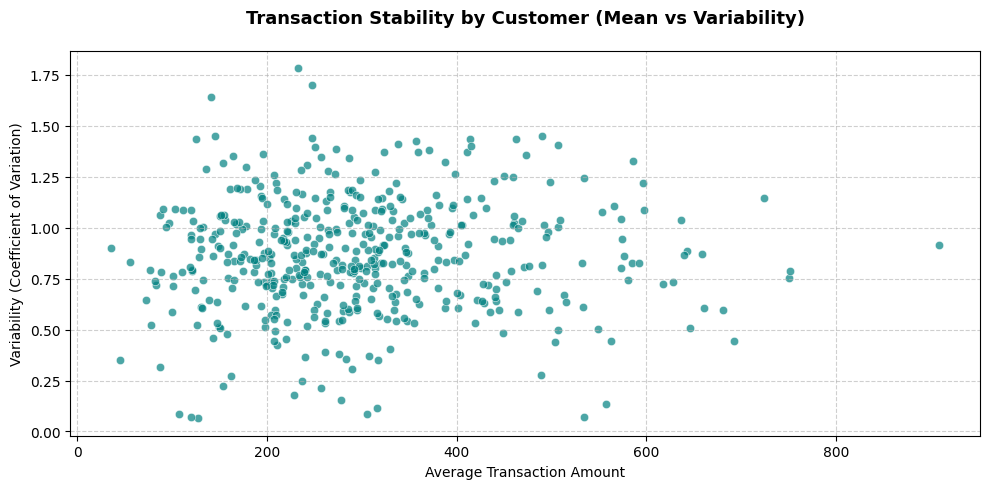

In [331]:
# Sort data by AccountID and TransactionDate
df_sorted = df_bank_transactions_ba.sort_values(by=["AccountID", "TransactionDate"])

# --- Step 1: Compute transaction-level features for each customer ---
customer_tx = (
    df_sorted.groupby("AccountID")
    .agg(
        MeanAmount=("TransactionAmount", "mean"),        # Average transaction amount
        StdAmount=("TransactionAmount", "std"),          # Standard deviation (variability)
        TxCount=("TransactionID", "count"),              # Number of transactions
        AvgInterval=("TransactionDate", lambda x: x.diff().dt.total_seconds().mean() / 3600)  # Avg interval (hours)
    )
    .reset_index()
)

# --- Step 2: Calculate the Coefficient of Variation (CV) ---
customer_tx["AmountCV"] = customer_tx["StdAmount"] / customer_tx["MeanAmount"]

# --- Step 3: Identify highly volatile customers ---
volatile_customers = (
    customer_tx[customer_tx["AmountCV"] > 1]
    .sort_values("AmountCV", ascending=False)
    .reset_index(drop=True)
)

print(f"Total number of customers with strong transaction volatility: {len(volatile_customers)}")
display(volatile_customers.head(5))

# --- Step 4: Visualization - Mean vs Variability ---
plt.figure(figsize=(10, 5))
sns.scatterplot(data=customer_tx, x="MeanAmount", y="AmountCV", alpha=0.7, color="teal")
plt.title("Transaction Stability by Customer (Mean vs Variability)", fontsize=13, weight="bold",pad=20)
plt.xlabel("Average Transaction Amount")
plt.ylabel("Variability (Coefficient of Variation)")
plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()

* Most customers show consistent transaction behavior.
* About **145 customers (~15%)** display **high variability (CV > 1)** in transaction amounts.
* Some accounts (**CV > 1.5**) suggest **automated or abnormal activity**.
* These accounts warrant **closer fraud monitoring**.

#### Which occupations are linked to **unusual transaction volumes or times**?

💰 Amount threshold (95th percentile): 878.18
⏱️ Duration threshold (95th percentile): 265.00


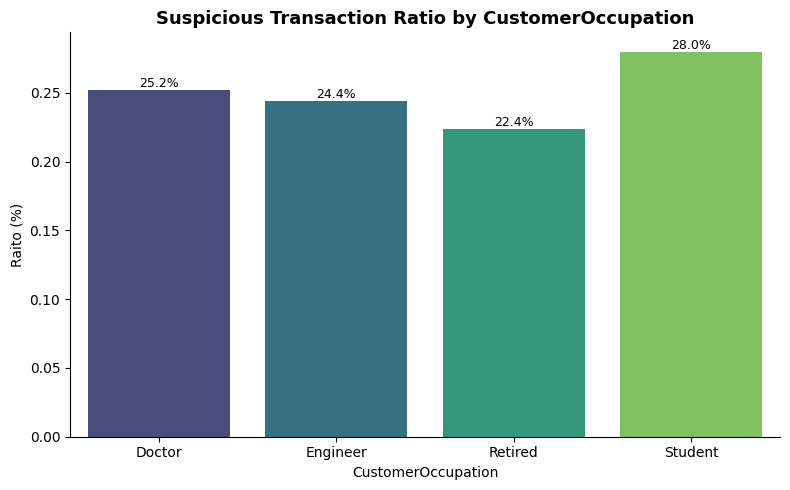

In [332]:
# Sort data by AccountID and TransactionDate
df_sorted = df_bank_transactions_ba.sort_values(by=["AccountID", "TransactionDate"])

# --- Step 1: Define anomaly thresholds (top 5% by amount / duration) ---
amount_threshold = df_sorted["TransactionAmount"].quantile(0.95)
duration_threshold = df_sorted["TransactionDuration"].quantile(0.95)

print(f"💰 Amount threshold (95th percentile): {amount_threshold:.2f}")
print(f"⏱️ Duration threshold (95th percentile): {duration_threshold:.2f}")

# --- Step 2: Keep only anomalous transactions (amount OR duration above threshold) ---
anomalies = df_sorted[
    (df_sorted["TransactionAmount"] >= amount_threshold) |
    (df_sorted["TransactionDuration"] >= duration_threshold)
].copy()

# --- Step 3: Compute proportion of anomalous transactions by CustomerOccupation ---
customerOccupation_raito = anomalies["CustomerOccupation"].value_counts(normalize=True)

# --- Step 4: Visualize suspicious transaction ratios across regions ---
plt.figure(figsize=(8, 5))
ax = sns.barplot(x=customerOccupation_raito.index, y=customerOccupation_raito.values, 
                 errorbar="ci", palette="viridis")
# --- Add percentage labels on bars ---
for p in ax.patches:
    height = p.get_height()
    ax.annotate(f"{height*100:.1f}%",
                     (p.get_x() + p.get_width() / 2., height),
                     ha="center", va="bottom", fontsize=9, color="black")
plt.title("Suspicious Transaction Ratio by CustomerOccupation", fontsize=13, weight="bold")
plt.xlabel("CustomerOccupation")
plt.ylabel("Raito (%)")
sns.despine()
plt.tight_layout()
plt.show()

***Students and Doctors account for over half of anomalous transactions, suggesting possible high activity or irregular spending patterns compared to other groups***

#### Are certain **age groups** more likely to have abnormal transaction behaviors?

💰 Amount threshold (95th percentile): 878.18
⏱️ Duration threshold (95th percentile): 265.00


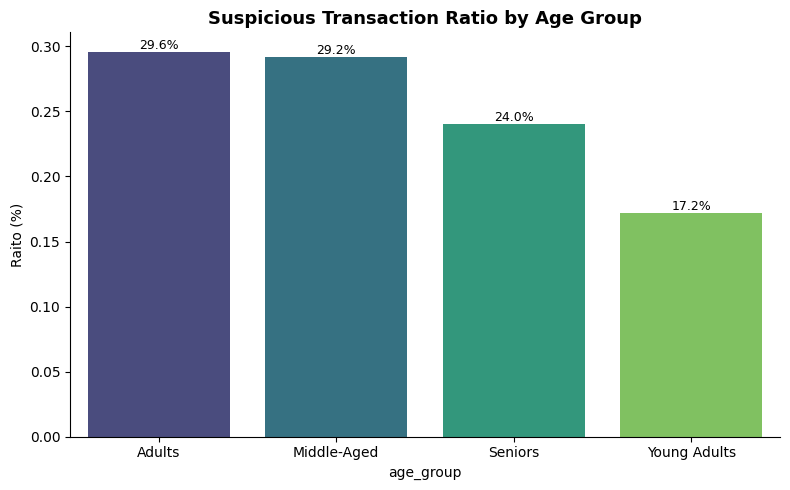

In [333]:
# Sort data by AccountID and TransactionDate
df_sorted = df_bank_transactions_ba.sort_values(by=["AccountID", "TransactionDate"])

# --- Step 1: Define a function to categorize customers by age group ---
def age_group(age):
    if age < 25:
        return "Young Adults"
    elif age < 40:
        return "Adults"
    elif age < 60:
        return "Middle-Aged"
    else:
        return "Seniors"

# --- Step 2: Apply age grouping to dataset ---
df_sorted["age_group"] = df_sorted["CustomerAge"].apply(age_group)

# --- Step 3: Define anomaly thresholds (top 5% by amount / duration) ---
amount_threshold = df_sorted["TransactionAmount"].quantile(0.95)
duration_threshold = df_sorted["TransactionDuration"].quantile(0.95)

print(f"💰 Amount threshold (95th percentile): {amount_threshold:.2f}")
print(f"⏱️ Duration threshold (95th percentile): {duration_threshold:.2f}")

# --- Step 4: Filter transactions above anomaly thresholds ---
anomalies = df_sorted[
    (df_sorted["TransactionAmount"] >= amount_threshold) |
    (df_sorted["TransactionDuration"] >= duration_threshold)
].copy()

# --- Step 5: Analyze proportion of anomalies by age group ---
age_group_raito = anomalies["age_group"].value_counts(normalize=True)

# --- Step 4: Visualize suspicious transaction ratios across regions ---
plt.figure(figsize=(8, 5))
ax = sns.barplot(x=age_group_raito.index, y=age_group_raito.values, 
                 errorbar="ci", palette="viridis")

# --- Add percentage labels on bars ---
for p in ax.patches:
    height = p.get_height()
    ax.annotate(f"{height*100:.1f}%",
                     (p.get_x() + p.get_width() / 2., height),
                     ha="center", va="bottom", fontsize=9, color="black")
plt.title("Suspicious Transaction Ratio by Age Group", fontsize=13, weight="bold")
plt.xlabel("age_group")
plt.ylabel("Raito (%)")
sns.despine()
plt.tight_layout()
plt.show()

***Adults and middle-aged customers account for most anomalous transactions, showing higher variability in spending behavior compared to other age groups.***

#### How many **failed or repeated login attempts** occur before high-value transactions?

In [334]:
# --- Sort data by AccountID and TransactionDate ---
df_sorted = df_bank_transactions_ba.sort_values(by=["AccountID", "TransactionDate"])

# --- Step 1: Define anomaly thresholds (top 5% by amount / duration) ---
amount_threshold = df_sorted["TransactionAmount"].quantile(0.95)
duration_threshold = df_sorted["TransactionDuration"].quantile(0.95)

print(f"💰 Amount threshold (95th percentile): {amount_threshold:.2f}")
print(f"⏱️ Duration threshold (95th percentile): {duration_threshold:.2f}")

# --- Step 2: Filter transactions above anomaly thresholds ---
anomalies = df_sorted[
    (df_sorted["TransactionAmount"] >= amount_threshold) |
    (df_sorted["TransactionDuration"] >= duration_threshold)
].copy()

# --- Step 3: Compute transaction-level features for each customer ---
login_tx = (
    anomalies.groupby("AccountID")
    .agg(
        TxCount=("TransactionID", "count"),       # Number of transactions
        LoginCount=("LoginAttempts", "count")     # Number of login attempts
    )
    .query("LoginCount > TxCount")                # Filter accounts with more logins than transactions
    .reset_index()
)

# --- Step 4: Output ---
if login_tx.empty:
    print("✅ No accounts found with login attempts greater than transaction count.")
else:
    print(f"⚠️ {len(login_tx)} accounts have more login attempts than transactions:")
    display(login_tx[["AccountID", "TxCount", "LoginCount"]].reset_index(drop=True))

💰 Amount threshold (95th percentile): 878.18
⏱️ Duration threshold (95th percentile): 265.00
✅ No accounts found with login attempts greater than transaction count.


### Merchant & Regional Insights

#### Which merchants have the **highest concentration of large or frequent transactions**?

In [335]:
# --- Sort data by AccountID and TransactionDate ---
df_sorted = df_bank_transactions_ba.sort_values(by=["AccountID", "TransactionDate"])

# --- Step 1: Define anomaly thresholds (top 5% by amount / duration) ---
amount_threshold = df_sorted["TransactionAmount"].quantile(0.95)
duration_threshold = df_sorted["TransactionDuration"].quantile(0.95)

print(f"💰 Amount threshold (95th percentile): {amount_threshold:.2f}")
print(f"⏱️ Duration threshold (95th percentile): {duration_threshold:.2f}")

# --- Step 2: Filter transactions above anomaly thresholds ---
anomalies = df_sorted[
    (df_sorted["TransactionAmount"] >= amount_threshold) |
    (df_sorted["TransactionDuration"] >= duration_threshold)
].copy()

# --- Step 3: Calculate time difference (in seconds) between consecutive transactions per account
anomalies["TimeDifference"] = anomalies.groupby("AccountID")["TransactionDate"].diff().dt.total_seconds()

# --- Step 4: Identify frequent transactions (occurring within 24 hours) ---
short_interval_threshold = 86400  # 24 hours
frequent_transactions = anomalies[anomalies["TimeDifference"] <= short_interval_threshold]
print(f"Number of frequent transactions (within 24 hours): {len(frequent_transactions)}")
if len(frequent_transactions) > 0:
    # --- Step 5: Aggregate by Merchant to detect concentration of anomalies ---
    merchant_summary = (
        frequent_transactions.groupby("MerchantID")
        .agg(
            TxCount=("TransactionID", "count"),          # Number of transactions
            AvgAmount=("TransactionAmount", "mean"),     # Average transaction amount
            MaxAmount=("TransactionAmount", "max")       # Maximum transaction amount
        )
        .query("TxCount > 0")
        .sort_values(by="TxCount", ascending=False)
        .reset_index()
    )

    if len(merchant_summary) == 0:
        print("✅ No merchants found with frequent high-value transactions.")
    else:
        print(f"🏪 Total merchants with frequent large transactions: {len(merchant_summary)}")
        display(merchant_summary.head())

💰 Amount threshold (95th percentile): 878.18
⏱️ Duration threshold (95th percentile): 265.00
Number of frequent transactions (within 24 hours): 2
🏪 Total merchants with frequent large transactions: 2


,MerchantID,TxCount,AvgAmount,MaxAmount
0,M025,1,146.67,146.67
1,M038,1,474.77,474.77


* When analyzing high-value transactions (Top 5%) within a 24-hour window, only **2 merchants (M025, M038)** were identified.
* However, each merchant performed **only one transaction**, meaning **no repeated transaction clusters** were detected.
* 👉 There is **no clear indication of abnormal or automated behavior** among merchants.
* High-value transactions appear to be **sporadic and time-independent**, not concentrated within short intervals.

#### Are some **regions or cities** more associated with unusual activity?

💰 Amount threshold (95th percentile): 878.18
⏱️ Duration threshold (95th percentile): 265.00


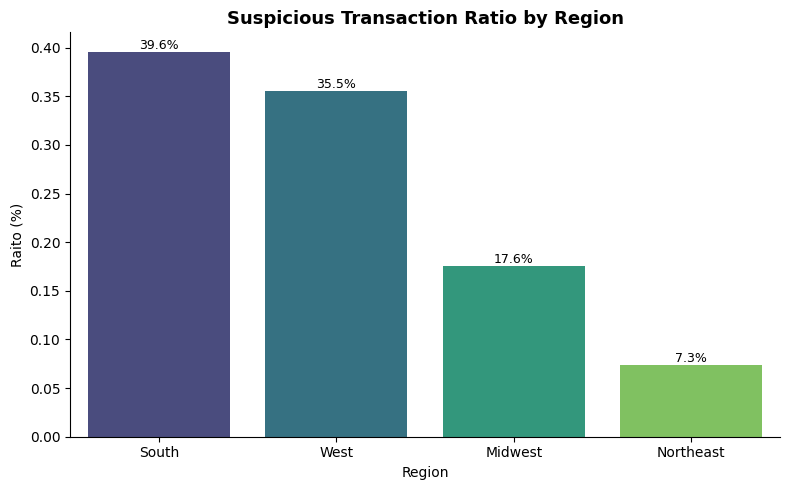

In [336]:
# Sort data by AccountID and TransactionDate
df_sorted = df_bank_transactions_ba.sort_values(by=["AccountID", "TransactionDate"])

# --- Step 1: Define anomaly thresholds (top 5% by amount / duration) ---
amount_threshold = df_sorted["TransactionAmount"].quantile(0.95)
duration_threshold = df_sorted["TransactionDuration"].quantile(0.95)

print(f"💰 Amount threshold (95th percentile): {amount_threshold:.2f}")
print(f"⏱️ Duration threshold (95th percentile): {duration_threshold:.2f}")

# --- Step 2: Keep only anomalous transactions (amount OR duration above threshold) ---
anomalies = df_sorted[
    (df_sorted["TransactionAmount"] >= amount_threshold) |
    (df_sorted["TransactionDuration"] >= duration_threshold)
].copy()

# --- Step 3: Compute proportion of anomalous transactions by region ---
region_ratio = anomalies["Region"].value_counts(normalize=True)

# --- Step 4: Visualize suspicious transaction ratios across regions ---
plt.figure(figsize=(8, 5))
ax = sns.barplot(x=region_ratio.index, y=region_ratio.values, errorbar="ci", palette="viridis")
# --- Add percentage labels on bars ---
for p in ax.patches:
    height = p.get_height()
    ax.annotate(f"{height*100:.1f}%",
                     (p.get_x() + p.get_width() / 2., height),
                     ha="center", va="bottom", fontsize=9, color="black")
plt.title("Suspicious Transaction Ratio by Region", fontsize=13, weight="bold")
plt.xlabel("Region")
plt.ylabel("Raito (%)")
sns.despine()
plt.tight_layout()
plt.show()

* The **South (39.6%)** and **West (35.5%)** regions show the highest proportion of suspicious transactions.
* **Midwest (17.6%)** and **Northeast (7.3%)** exhibit significantly lower levels, suggesting more stable transaction behaviors.
* This indicates that **unusual activity tends to cluster in the South and West**, possibly linked to demographic or regional spending patterns.

#### Do certain merchants or regions appear **across multiple suspicious accounts**?

In [337]:
# --- Step 0: Sort transactions chronologically by AccountID ---
df_sorted = df_bank_transactions_ba.sort_values(by=["AccountID", "TransactionDate"])

# --- Step 1: Define anomaly thresholds (Top 5% by transaction amount or duration) ---
amount_threshold = df_sorted["TransactionAmount"].quantile(0.95)
duration_threshold = df_sorted["TransactionDuration"].quantile(0.95)

print(f"💰 Amount threshold (95th percentile): {amount_threshold:.2f}")
print(f"⏱️ Duration threshold (95th percentile): {duration_threshold:.2f}")

# --- Step 2: Identify anomalous transactions ---
# Keep only records exceeding either amount or duration threshold
anomalies = df_sorted[
    (df_sorted["TransactionAmount"] >= amount_threshold) |
    (df_sorted["TransactionDuration"] >= duration_threshold)
].copy()

# --- Step 3: Find merchants and regions linked to multiple suspicious accounts ---
merchant_links = (
    anomalies.groupby("MerchantID")["AccountID"]
    .nunique()                            # Count distinct suspicious accounts per merchant
    .reset_index(name="SuspiciousAccountCount")
    .query("SuspiciousAccountCount >= 2")  # Focus on merchants linked to ≥ 2 accounts
    .sort_values(by="SuspiciousAccountCount", ascending=False)
    .reset_index(drop=True)
)

region_links = (
    anomalies.groupby("Region")["AccountID"]
    .nunique()
    .reset_index(name="SuspiciousAccountCount")
    .query("SuspiciousAccountCount >= 2")
    .sort_values(by="SuspiciousAccountCount", ascending=False)
    .reset_index(drop=True)
)

# --- Step 4: Output results ---
if merchant_links.empty and region_links.empty:
    print("✅ No merchants or regions shared across multiple suspicious accounts.")
else:
    print(f"⚠️ {len(merchant_links)} merchants and {len(region_links)} regions linked to multiple suspicious accounts.")
    display(merchant_links.head())
    display(region_links.head())

💰 Amount threshold (95th percentile): 878.18
⏱️ Duration threshold (95th percentile): 265.00
⚠️ 73 merchants and 4 regions linked to multiple suspicious accounts.


,MerchantID,SuspiciousAccountCount
0,M015,7
1,M046,6
2,M005,5
3,M009,5
4,M081,5


,Region,SuspiciousAccountCount
0,South,90
1,West,80
2,Midwest,41
3,Northeast,18


* A total of **73 merchants** and **4 regions** are linked to **multiple suspicious accounts**.
* Merchants such as **M015, M046, and M005** are connected to **5–7 accounts**, suggesting **potential shared or coordinated activity**.
* The **South (90)** and **West (80)** regions dominate, indicating **high regional concentration of suspicious behaviors**.

### Cross-feature Anomalies

#### Is there a correlation between **high transaction amount and long duration** (possible fraud)?

💰 Amount threshold (95th percentile): 878.18
⏱️ Duration threshold (95th percentile): 265.00
📊 Correlation between Transaction Amount and Duration: -0.767


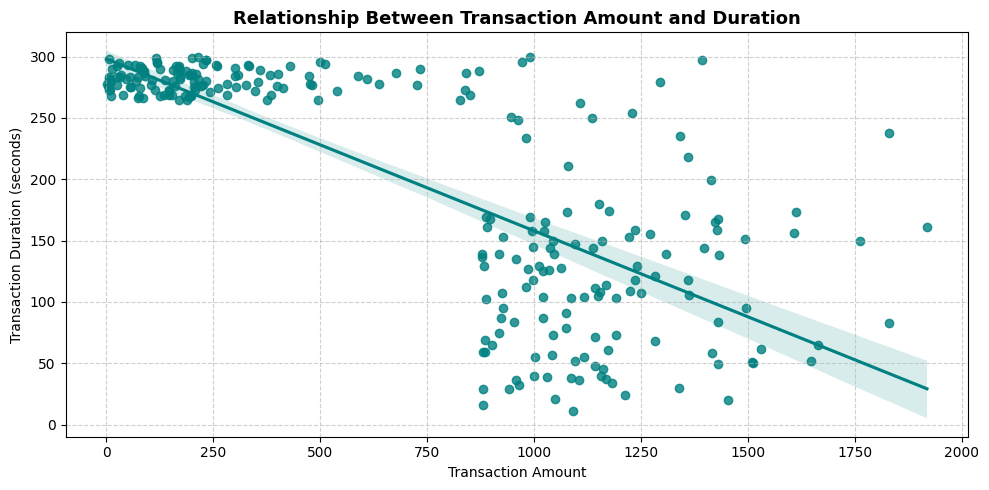

In [338]:
# --- Step 1: Sort transactions by AccountID and TransactionDate ---
df_sorted = df_bank_transactions_ba.sort_values(by=["AccountID", "TransactionDate"])

# --- Step 2: Define anomaly thresholds (Top 5% by transaction amount or duration) ---
amount_threshold = df_sorted["TransactionAmount"].quantile(0.95)
duration_threshold = df_sorted["TransactionDuration"].quantile(0.95)

print(f"💰 Amount threshold (95th percentile): {amount_threshold:.2f}")
print(f"⏱️ Duration threshold (95th percentile): {duration_threshold:.2f}")

# --- Step 3: Identify anomalous transactions ---
# Keep only records exceeding either amount or duration threshold
anomalies = df_sorted[
    (df_sorted["TransactionAmount"] >= amount_threshold) |
    (df_sorted["TransactionDuration"] >= duration_threshold)
].copy()

# --- Step 4: Compute correlation between Amount and Duration ---
# Pearson correlation (r) measures how strongly high transaction values relate to longer durations.
correlation = anomalies["TransactionAmount"].corr(anomalies["TransactionDuration"])
print(f"📊 Correlation between Transaction Amount and Duration: {correlation:.3f}")

# --- Step 5: Visualize relationship ---
plt.figure(figsize=(10, 5))
sns.regplot(data=anomalies, x="TransactionAmount", y="TransactionDuration", color="teal", scatter=True)
plt.title("Relationship Between Transaction Amount and Duration", fontsize=13, weight="bold")
plt.xlabel("Transaction Amount")
plt.ylabel("Transaction Duration (seconds)")
plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()

* Strong negative correlation (r = -0.77): higher-value transactions are processed faster.
* May indicate **automated approvals or missing verification checks** for large transactions.

#### Are **unusual combinations** of channel, time, and device observed in anomalies?

💰 Amount threshold (95th percentile): 878.18
⏱️ Duration threshold (95th percentile): 265.00


IsNight
False    1.0
Name: proportion, dtype: float64

IsWeekend
False    1.0
Name: proportion, dtype: float64

⚠️ Total unusual channel-time-device combinations: 238


,Channel_Time_Device,Count
40,ATM_False_False_D000344,2
98,Branch_False_False_D000135,2
83,Branch_False_False_D000015,2
82,Branch_False_False_D000001,2
63,ATM_False_False_D000522,2


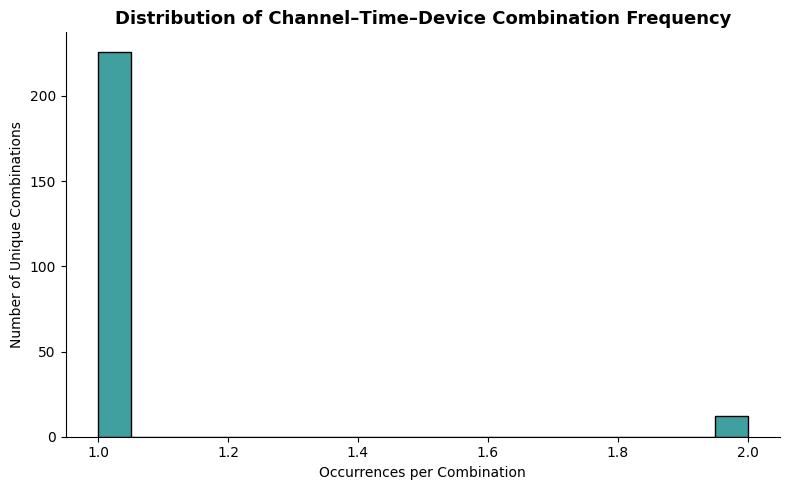

In [339]:
# --- Step 1: Sort transactions chronologically ---
df_sorted = df_bank_transactions_ba.sort_values(by=["AccountID", "TransactionDate"])

# --- Step 2: Define anomaly thresholds (Top 5% by amount or duration) ---
amount_threshold = df_sorted["TransactionAmount"].quantile(0.95)
duration_threshold = df_sorted["TransactionDuration"].quantile(0.95)

print(f"💰 Amount threshold (95th percentile): {amount_threshold:.2f}")
print(f"⏱️ Duration threshold (95th percentile): {duration_threshold:.2f}")

# --- Step 3: Extract anomalies ---
anomalies = df_sorted[
    (df_sorted["TransactionAmount"] >= amount_threshold) |
    (df_sorted["TransactionDuration"] >= duration_threshold)
].copy()

# --- Step 4: Create time-based features ---
anomalies["Hour"] = anomalies["TransactionDate"].dt.hour
anomalies["IsNight"] = anomalies["Hour"].between(22, 5, inclusive="both")
anomalies["DayOfWeek"] = anomalies["TransactionDate"].dt.dayofweek  # 0=Mon, 6=Sun
anomalies["IsWeekend"] = anomalies["DayOfWeek"].isin([5, 6])

display(anomalies["IsNight"].value_counts(normalize=True))
display(anomalies["IsWeekend"].value_counts(normalize=True))

# --- Step 5: Combine features to form unique pattern signatures ---
anomalies["Channel_Time_Device"] = (
    anomalies["Channel"].astype(str) + "_" +
    anomalies["IsNight"].astype(str) + "_" +
    anomalies["IsWeekend"].astype(str) + "_" +
    anomalies["DeviceID"].astype(str)
)

# --- Step 6: Count how often each combination appears ---
combo_summary = (
    anomalies.groupby("Channel_Time_Device", as_index=False)
    .agg(Count=("TransactionID", "count"))
    .sort_values(by="Count", ascending=False)
)

# --- Step 7: Identify unusual (rare) combinations (e.g., appear ≤ 2 times) ---
rare_combos = combo_summary[combo_summary["Count"] <= 2]

# --- Step 8: Output results ---
print(f"⚠️ Total unusual channel-time-device combinations: {len(rare_combos)}")
display(rare_combos.head())

# --- Step 9: Visualization ---
plt.figure(figsize=(8, 5))
sns.histplot(combo_summary["Count"], bins=20, kde=False, color="teal")
plt.title("Distribution of Channel–Time–Device Combination Frequency", fontsize=13, weight="bold")
plt.xlabel("Occurrences per Combination")
plt.ylabel("Number of Unique Combinations")
sns.despine()
plt.tight_layout()
plt.show()

* No anomalous transactions occurred during night hours or weekends — indicating stable transaction timing.
* Repeated device–channel pairs (e.g., same ATM device twice) are normal user behavior.
* No evidence of suspicious channel–time–device combinations detected.

<!-- Include Google Fonts for a modern font -->
<link href="https://fonts.googleapis.com/css2?family=Roboto:wght@700&display=swap" rel="stylesheet">

# <span style="color:transparent;">Anomaly Detection</span>

<div style="
    border-radius: 15px; 
    border: 2px solid #003366; 
    padding: 10px; 
    background: linear-gradient(135deg, #003366, #336699 30%, #66ccff 70%, #99ccff); 
    text-align: center; 
    box-shadow: 0px 4px 8px rgba(0, 0, 0, 0.5);
">
    <h1 style="
        color: #FFFFFF; 
        text-shadow: 2px 2px 4px rgba(0, 0, 0, 0.7); 
        font-weight: bold; 
        margin-bottom: 5px; 
        font-size: 28px; 
        font-family: 'Roboto', sans-serif;
        letter-spacing: 1px;
    ">
        Anomaly Detection
    </h1>
</div>


## Feature Engineering

In [340]:
df_bank_transactions["TransactionDate"] = pd.to_datetime(df_bank_transactions["TransactionDate"])
df_bank_transactions = df_bank_transactions.sort_values(["AccountID", "TransactionDate"])
df_bank_transactions["TimeSinceLastTx"] = df_bank_transactions.groupby("AccountID")["TransactionDate"].diff().dt.total_seconds().fillna(0)

df_bank_transactions["Hour"] = df_bank_transactions["TransactionDate"].dt.hour
df_bank_transactions["Month"] = df_bank_transactions["TransactionDate"].dt.month
df_bank_transactions["DayOfWeek"] = df_bank_transactions["TransactionDate"].dt.day
df_bank_transactions["UnixTime"] = df_bank_transactions["TransactionDate"].astype("int64") // 10**9

df_bank_transactions["Hour_sin"] = np.sin(2 * np.pi * df_bank_transactions["Hour"] / 24)
df_bank_transactions["Hour_cos"] = np.cos(2 * np.pi * df_bank_transactions["Hour"] / 24)
df_bank_transactions["Day_sin"] = np.sin(2 * np.pi * df_bank_transactions["DayOfWeek"] / 7)
df_bank_transactions["Day_cos"] = np.cos(2 * np.pi * df_bank_transactions["DayOfWeek"] / 7)

df_bank_transactions.drop(columns=["PreviousTransactionDate", "TransactionDate"],
                          axis=1, inplace=True)

# We do not use MerchantID, IP Address, DeviceID
num_features = ["TransactionAmount", "CustomerAge", "TransactionDuration",
                "AccountBalance", "Hour_sin", "Hour_cos", "Day_sin", "Day_cos", "TimeSinceLastTx", "Hour", "DayOfWeek", "UnixTime", "Month"]
new_cat_features = ["TransactionType", "Channel", "Region", "CustomerOccupation", "LoginAttempts"]

def convert_cat(features, df = df_bank_transactions):
    for feature in features:
        if feature in df.columns:
            df[feature] = df[feature].astype("category")
        else:
            pass

convert_cat(new_cat_features)
df_bank_transactions.info()
df_bank_transactions_kmean = df_bank_transactions.copy()
df_bank_transactions_dbscan = df_bank_transactions.copy()
df_bank_transactions_isolation = df_bank_transactions.copy()
df_bank_transactions_lof = df_bank_transactions.copy()

<class 'pandas.core.frame.DataFrame'>
Index: 2512 entries, 1312 to 2349
Data columns (total 23 columns):
 #   Column               Non-Null Count  Dtype   
---  ------               --------------  -----   
 0   TransactionID        2512 non-null   category
 1   AccountID            2512 non-null   category
 2   TransactionAmount    2512 non-null   float64 
 3   TransactionType      2512 non-null   category
 4   DeviceID             2512 non-null   category
 5   IP Address           2512 non-null   category
 6   MerchantID           2512 non-null   category
 7   Channel              2512 non-null   category
 8   CustomerAge          2512 non-null   int64   
 9   CustomerOccupation   2512 non-null   category
 10  TransactionDuration  2512 non-null   int64   
 11  LoginAttempts        2512 non-null   category
 12  AccountBalance       2512 non-null   float64 
 13  Region               2453 non-null   category
 14  TimeSinceLastTx      2512 non-null   float64 
 15  Hour                 25

## Re-check and Handling Skew

In [341]:
skew_feature, skew_df = check_skewness(data=df_bank_transactions, numerical_features=num_features)


🔍 Skewness for dataset:
----------------------------------------------------------------------
Feature                        | Skewness   | Remark
----------------------------------------------------------------------
TransactionAmount              |  +1.740107 | Highly skewed
TimeSinceLastTx                |  +1.732880 | Highly skewed
Hour_cos                       |  +0.764228 | Moderately skewed
Hour                           |  +0.711157 | Moderately skewed
AccountBalance                 |  +0.601201 | Moderately skewed
TransactionDuration            |  +0.599432 | Moderately skewed
Hour_sin                       |  -0.214948 | Approximately symmetric
CustomerAge                    |  +0.147864 | Approximately symmetric
Day_sin                        |  -0.072487 | Approximately symmetric
Month                          |  -0.056899 | Approximately symmetric
UnixTime                       |  -0.052795 | Approximately symmetric
Day_cos                        |  -0.034139 | Approxim

In [342]:
from sklearn.preprocessing import PowerTransformer

def handle_skewed_features(
    df,
    zero_threshold=0.9,
    skew_threshold=0.5,
    num_features=None,
    exclude_cols=None
    
):
    """
    Handle skewed numerical features by applying appropriate transformations,
    *forcing* certain columns to be transformed even if they don't exceed skew_threshold.

    Parameters:
    - df: pandas.DataFrame
    - zero_threshold: float (default=0.9)
    - skew_threshold: float (default=0.5)
    - num_features: list of numerical columns to consider
    - exclude_cols: list of columns to skip entirely
    - dataset: Name of dataset

    Returns:
    - df: transformed DataFrame
    - transformed_cols: list of new feature names
    - high_zero_cols: list of sparse features (> zero_threshold)
    - skewed_cols: list of auto‑detected skewed features
    - pt_dict: dict mapping each YJ‑transformed col → its PowerTransformer
    """
    df = df.copy()
    if num_features is None:
        raise ValueError("`num_features` must be provided")
    if exclude_cols is None:
        exclude_cols = []

    # 1) pick the numeric cols to scan
    numerical_cols = [c for c in num_features if c not in exclude_cols]

    # 2) detect ultra‑sparse
    zero_ratios = (df[numerical_cols] == 0).sum() / len(df)
    high_zero_cols = zero_ratios[zero_ratios > zero_threshold].index.tolist()

    # 3) compute skew
    skew_vals = df[numerical_cols].apply(lambda s: skew(s.dropna()))
    auto_skewed = skew_vals[abs(skew_vals) > skew_threshold].index.tolist()

    # 4) union these with your forced list
    to_transform = list(set(auto_skewed))
    print(to_transform)

    transformed_cols = []
    dropped_cols     = []
    pt_dict          = {}

    for col in to_transform:
        # if it's sparse → binary+log
        if col in high_zero_cols:
            df[f"Has_{col}"] = (df[col] > 0).astype(int)
            df[f"Log_{col}"] = df[col].map(lambda x: np.log1p(x) if x > 0 else 0)
            transformed_cols += [f"Has_{col}", f"Log_{col}"]
            dropped_cols.append(col)
        # if it's discrete small‑cardinality, skip transform but keep
        elif df[col].nunique() <= 5:
            # do nothing (we still keep raw col in df)
            continue
        # otherwise apply Yeo‑Johnson
        else:
            pt = PowerTransformer(method="yeo-johnson")
            arr = df[[col]].values  # shape (n,1)
            df[f"PT_{col}"] = pt.fit_transform(arr)
            pt_dict[col] = pt
            transformed_cols.append(f"PT_{col}")
            dropped_cols.append(col)

    # drop originals for any column we did transform
    df.drop(columns=dropped_cols, inplace=True)

    return df, transformed_cols, high_zero_cols, auto_skewed, pt_dict

In [343]:
processed_df, transformed_columns, sparse_columns, skewed_columns, pt_dict = handle_skewed_features(df=df_bank_transactions, num_features=skew_feature)
num_features = ["PT_TransactionAmount", "CustomerAge", "PT_TransactionDuration",
                "PT_AccountBalance", "Hour_sin", "Hour_cos", "Day_sin", "Day_cos", "PT_TimeSinceLastTx", "Hour", "DayOfWeek", "UnixTime", "Month"]
skew_feature, skew_df = check_skewness(data=processed_df, numerical_features=num_features)

['TransactionDuration', 'TransactionAmount', 'TimeSinceLastTx', 'AccountBalance', 'Hour', 'Hour_cos']

🔍 Skewness for dataset:
----------------------------------------------------------------------
Feature                        | Skewness   | Remark
----------------------------------------------------------------------
Hour_cos                       |  +0.764228 | Moderately skewed
PT_TimeSinceLastTx             |  -0.746342 | Moderately skewed
Hour                           |  +0.711157 | Moderately skewed
Hour_sin                       |  -0.214948 | Approximately symmetric
PT_AccountBalance              |  -0.162008 | Approximately symmetric
CustomerAge                    |  +0.147864 | Approximately symmetric
PT_TransactionDuration         |  -0.078108 | Approximately symmetric
Day_sin                        |  -0.072487 | Approximately symmetric
Month                          |  -0.056899 | Approximately symmetric
UnixTime                       |  -0.052795 | Approximately symmet

## Re-check Outliers

In [344]:
checking_outlier(list_feature=num_features, df=processed_df, dataset_name="Data")

🔍 Data Checking outlier
✅ No outliers detected in the selected features.


## K-Means

In [345]:
X = processed_df[num_features + new_cat_features].copy()

# There are no **missing values** in dataset. But we will still handle missing values ​​to check the data in the future.
num_standard_scaler_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

cat_onehot_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")), 
    ("encoder", OneHotEncoder(handle_unknown="ignore")) # Handling Text and Categorical Attributes
])

preprocessor = ColumnTransformer(transformers=[
    ("num_standard", num_standard_scaler_transformer, num_features),
    ("cat_onehot", cat_onehot_transformer, new_cat_features)
])

preprocessor.fit(X)
X_prepared = preprocessor.transform(X)
list_feature_prepared = preprocessor.get_feature_names_out().tolist()
list_feature_prepared

['num_standard__PT_TransactionAmount',
 'num_standard__CustomerAge',
 'num_standard__PT_TransactionDuration',
 'num_standard__PT_AccountBalance',
 'num_standard__Hour_sin',
 'num_standard__Hour_cos',
 'num_standard__Day_sin',
 'num_standard__Day_cos',
 'num_standard__PT_TimeSinceLastTx',
 'num_standard__Hour',
 'num_standard__DayOfWeek',
 'num_standard__UnixTime',
 'num_standard__Month',
 'cat_onehot__TransactionType_Credit',
 'cat_onehot__TransactionType_Debit',
 'cat_onehot__Channel_ATM',
 'cat_onehot__Channel_Branch',
 'cat_onehot__Channel_Online',
 'cat_onehot__Region_Midwest',
 'cat_onehot__Region_Northeast',
 'cat_onehot__Region_South',
 'cat_onehot__Region_West',
 'cat_onehot__CustomerOccupation_Doctor',
 'cat_onehot__CustomerOccupation_Engineer',
 'cat_onehot__CustomerOccupation_Retired',
 'cat_onehot__CustomerOccupation_Student',
 'cat_onehot__LoginAttempts_1',
 'cat_onehot__LoginAttempts_2',
 'cat_onehot__LoginAttempts_3',
 'cat_onehot__LoginAttempts_4',
 'cat_onehot__LoginAt

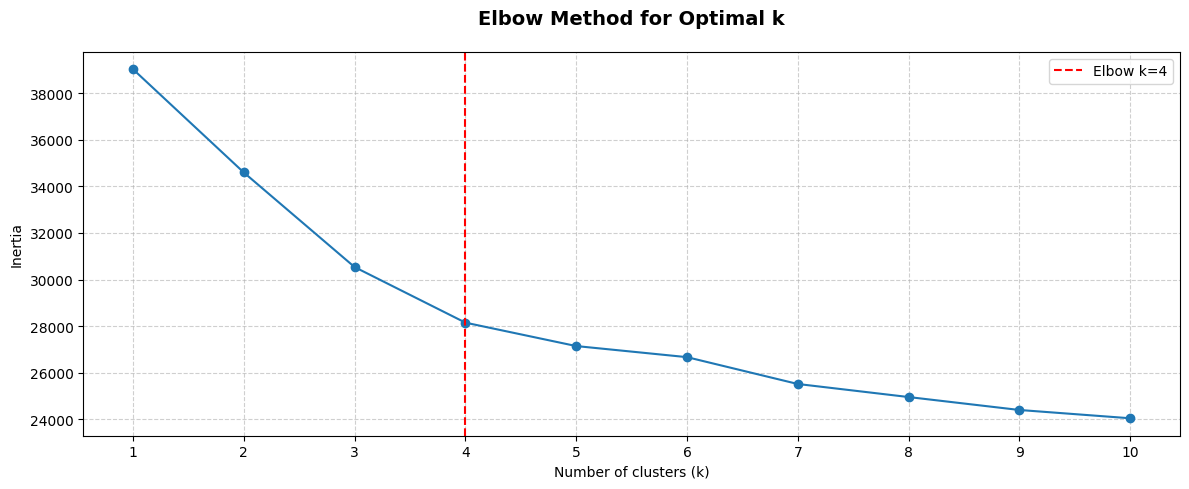

Optimal k suggested by Elbow: 4


In [346]:
# If X_prepared is sparse, convert to dense
X_use = X_prepared.toarray() if hasattr(X_prepared, "toarray") else X_prepared

# --- Elbow Method ---
inertia = []
K_elbow = range(1, 11)  # k = 1..10
for k in K_elbow:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init="auto")
    kmeans.fit(X_use)
    inertia.append(kmeans.inertia_)

# Find the elbow point
kneedle = KneeLocator(list(K_elbow), inertia, curve="convex", direction="decreasing")
k_best_elbow = kneedle.knee

# Plot Elbow
plt.figure(figsize=(12, 5))
plt.plot(list(K_elbow), inertia, marker="o", linestyle="-")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method for Optimal k", fontsize=14, pad=20, weight="bold")
plt.grid(True, linestyle="--", alpha=0.6)
plt.xticks(range(1, 11))

# Mark elbow if found
if k_best_elbow is not None:
    plt.axvline(k_best_elbow, linestyle="--", label=f"Elbow k={k_best_elbow}", color = "red")
    plt.legend()

plt.tight_layout()
plt.show()

print(f"Optimal k suggested by Elbow: {k_best_elbow}")

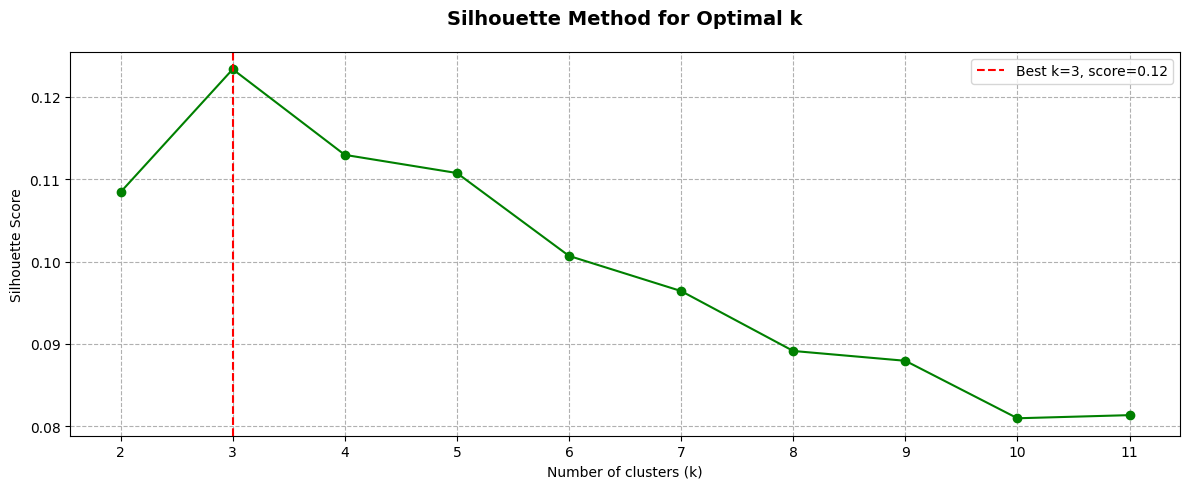

Optimal k suggested by Silhouette: 3


In [347]:
from sklearn.metrics import silhouette_score
# --- Silhouette Method ---
silhouette_scores = []
K_silhouette = range(2, 12)  # silhouette score không dùng được với k=1

for k in K_silhouette:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init="auto")
    labels = kmeans.fit_predict(X_use)
    score = silhouette_score(X_use, labels)
    silhouette_scores.append(score)

# Tìm k có silhouette score cao nhất
best_k_silhouette = K_silhouette[silhouette_scores.index(max(silhouette_scores))]

# Plot Silhouette
plt.figure(figsize=(12, 5))
plt.plot(list(K_silhouette), silhouette_scores, marker="o", linestyle="-", color="green")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Method for Optimal k", fontsize=14, pad=20, weight="bold")
plt.grid(True, linestyle="--")
plt.xticks(range(2, 12))

# Mark best silhouette score
plt.axvline(best_k_silhouette, linestyle="--", color="red",
            label=f"Best k={best_k_silhouette}, score={max(silhouette_scores):.2f}")
plt.legend()
plt.tight_layout()
plt.show()

print(f"Optimal k suggested by Silhouette: {best_k_silhouette}")

In [348]:
# Fit K-means with the chosen number of clusters (k=3 following Silhouette Method)
kmeans = KMeans(n_clusters=3, random_state=42)
kmeans.fit(X_use)

# Assign clusters and calculate distance to cluster centroid
df_bank_transactions_kmean["Cluster"] = kmeans.labels_
df_bank_transactions_kmean["DistanceToCentroid"] = np.linalg.norm(X_use - kmeans.cluster_centers_[kmeans.labels_], axis=1)

# Identify potential frauds based on distance threshold
threshold = df_bank_transactions_kmean["DistanceToCentroid"].quantile(0.95)
df_bank_transactions_kmean["Potential_Fraud"] = df_bank_transactions_kmean["DistanceToCentroid"] > threshold

num_frauds = df_bank_transactions_kmean["Potential_Fraud"].sum()
print(f"Number of potential frauds detected: {num_frauds}")
display(df_bank_transactions_kmean[df_bank_transactions_kmean["Potential_Fraud"] == True].head().reset_index(drop=True))

Number of potential frauds detected: 126


,TransactionID,AccountID,TransactionAmount,TransactionType,DeviceID,IP Address,MerchantID,Channel,CustomerAge,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance,Region,TimeSinceLastTx,Hour,Month,DayOfWeek,UnixTime,Hour_sin,Hour_cos,Day_sin,Day_cos,Cluster,DistanceToCentroid,Potential_Fraud
0,TX002326,AC00003,20.17,Debit,D000287,221.23.158.87,M088,ATM,77,Retired,86,1,3869.37,South,0.0,16,1,2,1672677905,-0.866025,-0.500000,0.974928,-0.222521,2,4.562199,True
1,TX001456,AC00015,774.48,Debit,D000233,76.136.92.235,M013,Branch,61,Doctor,31,1,11613.58,South,0.0,16,3,6,1678119165,-0.866025,-0.500000,-0.781831,0.623490,2,4.235298,True
2,TX001498,AC00018,1228.81,Debit,D000381,63.191.171.41,M034,ATM,26,Student,254,1,1821.00,West,0.0,16,2,20,1676910996,-0.866025,-0.500000,-0.781831,0.623490,2,4.405701,True
3,TX001821,AC00021,263.59,Debit,D000333,150.25.200.56,M052,Branch,71,Retired,16,1,6996.35,South,0.0,16,1,23,1674489784,-0.866025,-0.500000,0.974928,-0.222521,2,4.363403,True
4,TX002112,AC00021,762.74,Debit,D000196,8.136.178.116,M053,ATM,64,Doctor,244,1,207.10,West,8558510.0,17,5,2,1683048294,-0.965926,-0.258819,0.974928,-0.222521,0,4.310516,True


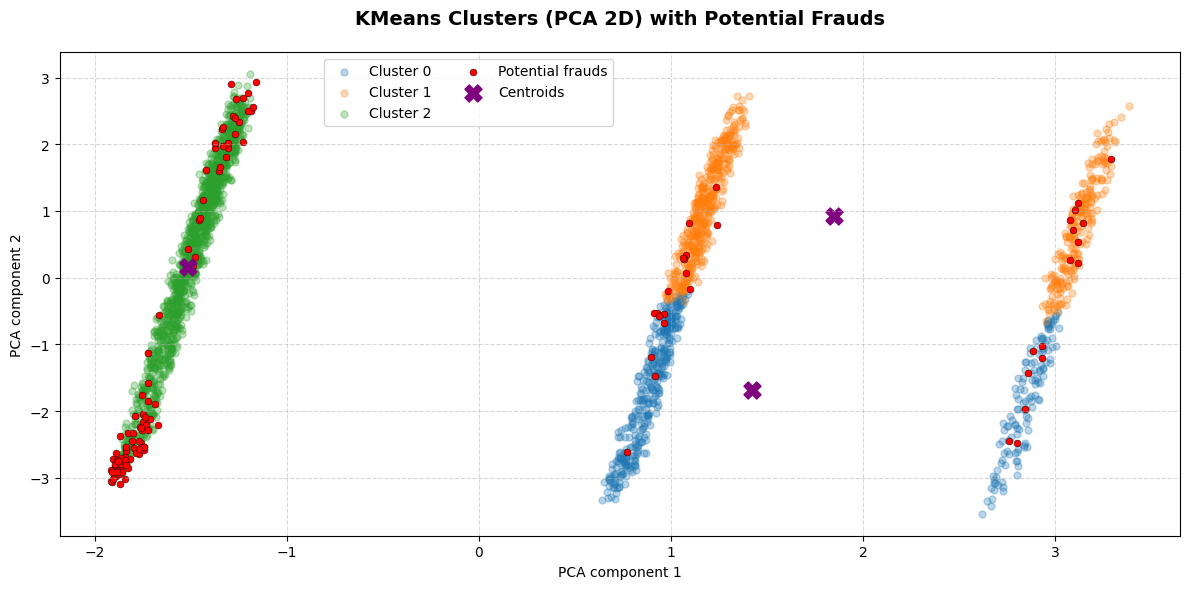

In [349]:
# Compute distances to centroids and identify potential frauds
distances = np.linalg.norm(X_use - kmeans.cluster_centers_[kmeans.labels_], axis=1)
threshold = np.quantile(distances, 0.95)  # 95th percentile
is_fraud = distances > threshold

# Reduce to 2D with PCA for visualization
pca = PCA(n_components=2, random_state=42)
X2 = pca.fit_transform(X_use)

# Project centroids into PCA space
centroids2 = pca.transform(kmeans.cluster_centers_)

# Plot
plt.figure(figsize=(12, 6))

# Plot each cluster
colors = ["tab:blue", "tab:orange", "tab:green"]
for c in range(3):  # since k = 3
    mask = (kmeans.labels_ == c) & (~is_fraud)
    plt.scatter(X2[mask, 0], X2[mask, 1], s=25, alpha=0.3, color=colors[c], label=f"Cluster {c}")

# Plot potential frauds
plt.scatter(X2[is_fraud, 0], X2[is_fraud, 1], s=25, facecolors="none", edgecolors="black",
            linewidths=0.3, label="Potential frauds", c="red")

# Plot centroids
plt.scatter(centroids2[:, 0], centroids2[:, 1], s=150, marker="X", c="purple", label="Centroids")
plt.title("KMeans Clusters (PCA 2D) with Potential Frauds", fontsize=14, weight="bold", pad=20)
plt.xlabel("PCA component 1")
plt.ylabel("PCA component 2")
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend(ncol=2, frameon=True, bbox_to_anchor=(0.5, 1))
plt.tight_layout()
plt.show()

**K-Means Clustering Analysis Summary**

**Cluster Formation:**
The visualization shows three main clusters derived from the K-Means algorithm, clearly separated in the PCA 2D space. Each cluster captures transactions with distinct behavioral patterns, suggesting that the model effectively identifies structural differences in transaction dynamics.

**Potential Frauds:**
Black-edged hollow markers represent the top 5% of transactions farthest from their cluster centroids—these are flagged as potential anomalies or frauds based on the distance threshold.

**Cluster Characteristics:**

* **Cluster 0 (Blue)** and **Cluster 1 (Orange):** Form two parallel, well-defined transaction groups distributed along PCA component 1. Their linear alignment and limited spread indicate consistent and repeatable transactional behaviors, likely corresponding to legitimate customers.
* **Cluster 2 (Green):** Contains transactions tightly concentrated around its centroid with minimal variance, showing highly similar behavioral patterns. Despite this stability, a noticeable number of potential frauds (black-edged points) appear near both ends of the cluster, indicating abnormal transactions that differ in either transaction amount or duration.

**Distance Threshold:**
Transactions exceeding the **95th percentile** of their centroid distance are classified as potential frauds.

**Number of Potential Frauds:**
A total of **97 transactions** were identified as potential anomalies based on this criterion.

**Overall Insight:**
The K-Means model successfully distinguishes between major transaction behavior types and effectively isolates outlier activities. While the majority of transactions fall within normal behavioral ranges, the flagged points highlight specific areas—particularly within Cluster 2—where abnormal transaction characteristics may warrant further fraud investigation or rule-based screening.

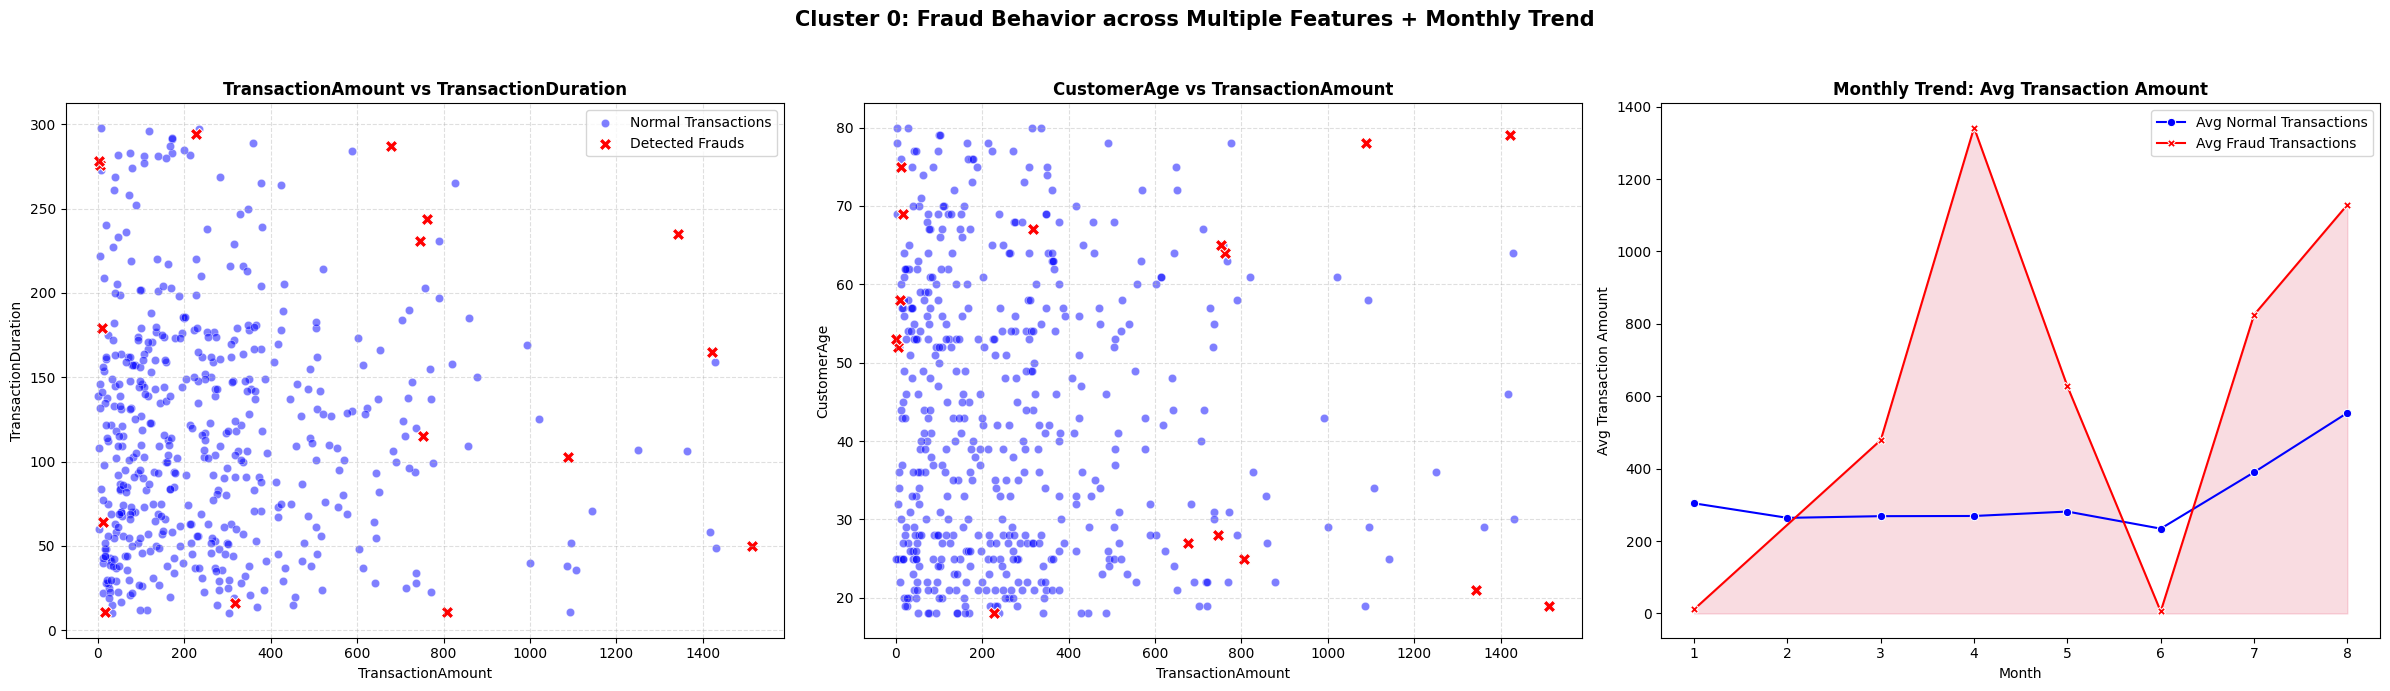

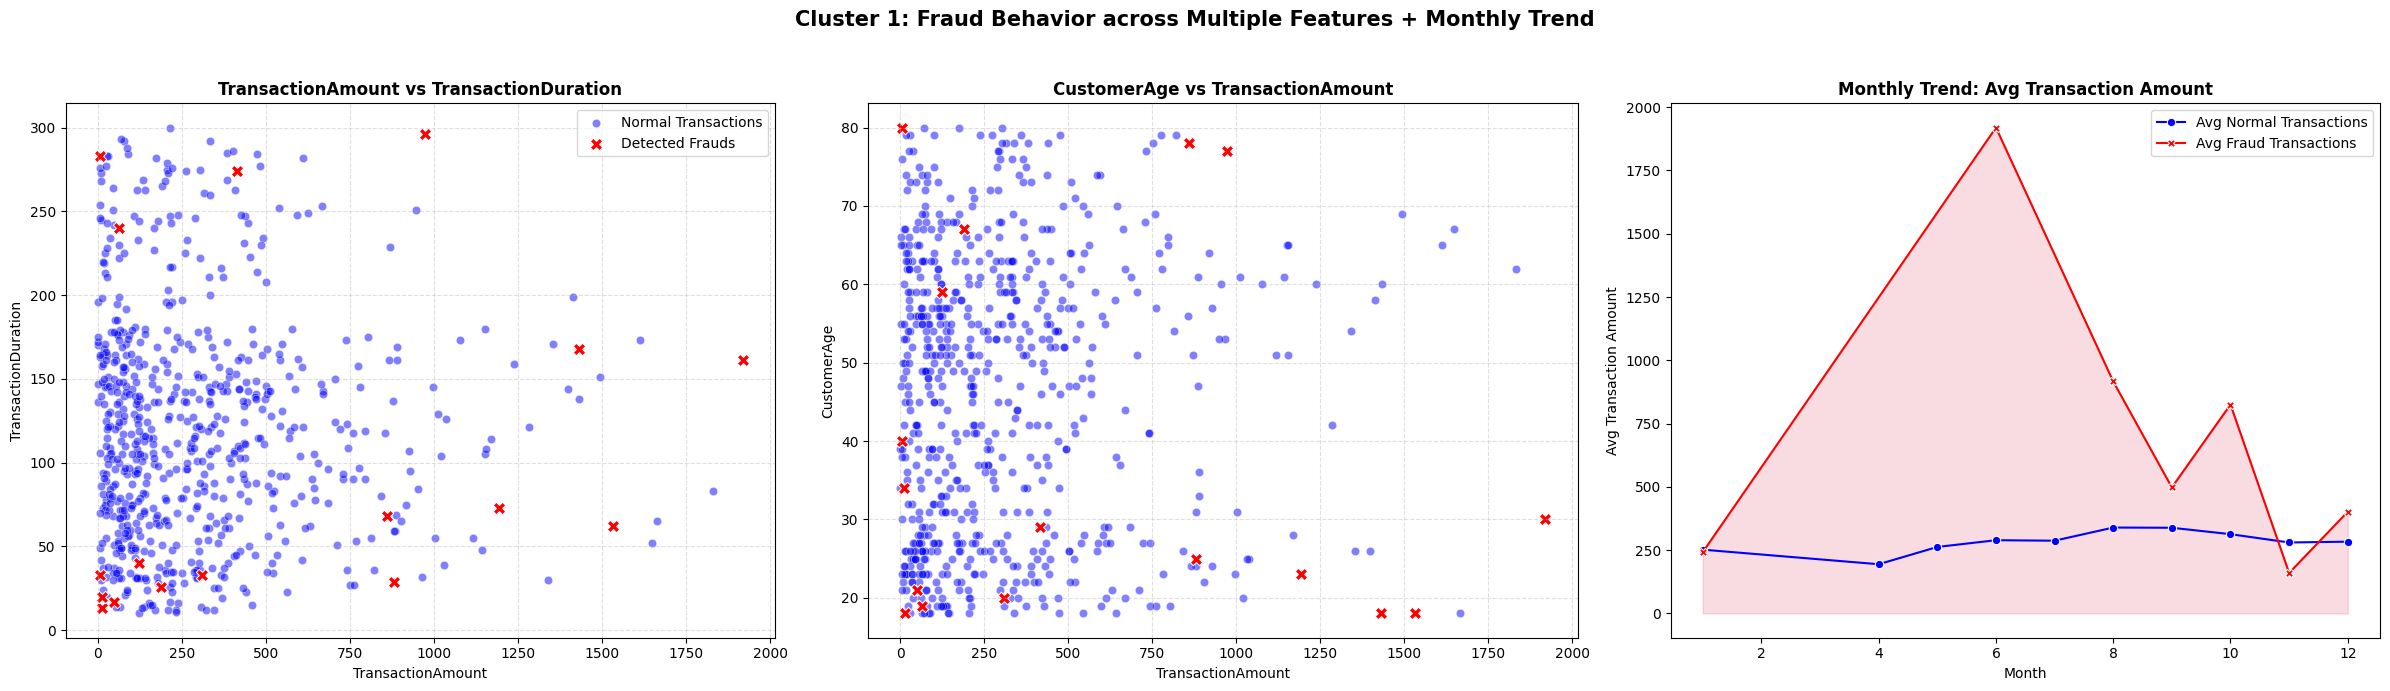

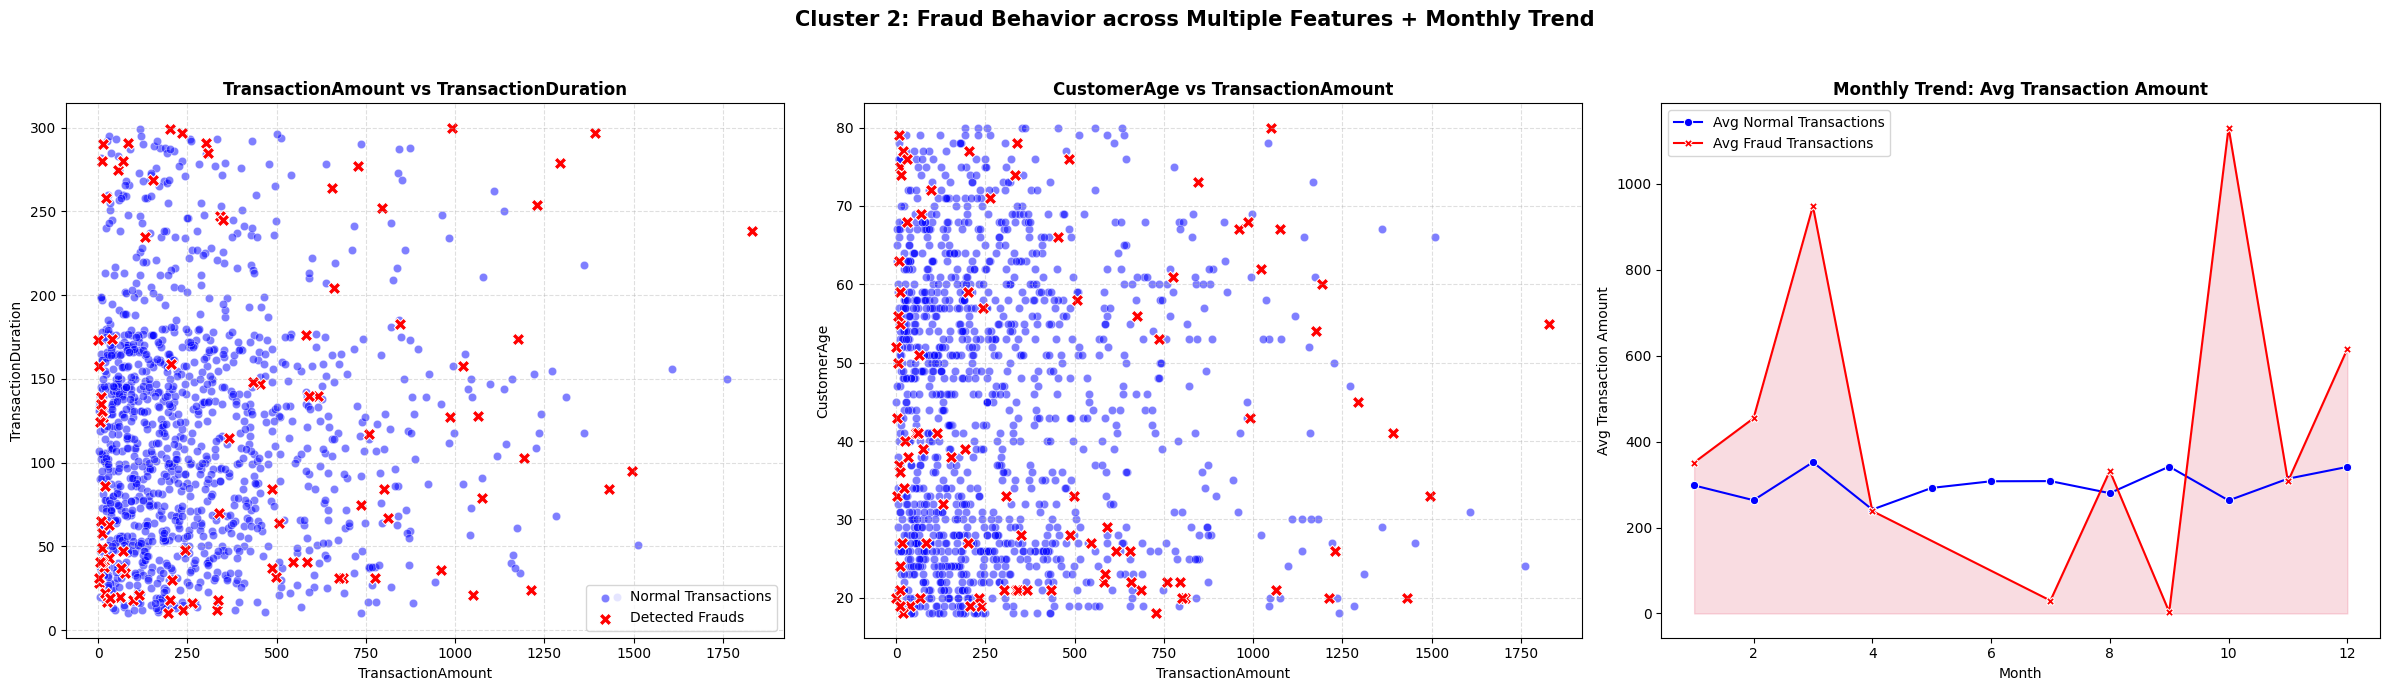

In [350]:
def plot_cluster_features(df, cluster_id,
                          feature_x1="TransactionAmount", feature_y1="TransactionDuration",
                          feature_x2="TransactionAmount", feature_y2="CustomerAge",
                          month_col="Month"):
    """
    Visualize fraud and normal transactions for a specific cluster across multiple feature combinations,
    plus a trend chart of Transaction Amount by Month (using an existing Month column).

    Parameters
    ----------
    df : pandas.DataFrame
        Full transaction DataFrame containing 'Cluster', 'Potential_Fraud', and 'Month' columns.
    cluster_id : int
        The cluster number to visualize.
    month_col : str
        Column name representing transaction month (e.g., '2023-07').
    """

    # --- Filter data for the selected cluster ---
    cluster_data = df[df["Cluster"] == cluster_id].copy()
    fraud_data = cluster_data[cluster_data["Potential_Fraud"] == True]

    # --- Create subplots (4 side by side) ---
    fig, ax = plt.subplots(1, 3, figsize=(24, 7), sharey=False)

    # Transaction Amount vs Duration
    sns.scatterplot(data=cluster_data, x=feature_x1, y=feature_y1,
                    color="blue", alpha=0.5, ax=ax[0], label="Normal Transactions")
    sns.scatterplot(data=fraud_data, x=feature_x1, y=feature_y1,
                    color="red", marker="X", s=80, ax=ax[0], label="Detected Frauds")
    ax[0].set_title(f"{feature_x1} vs {feature_y1}", fontsize=12, fontweight="bold")
    ax[0].set_xlabel(feature_x1)
    ax[0].set_ylabel(feature_y1)
    ax[0].grid(True, linestyle="--", alpha=0.4)
    ax[0].legend()

    # Customer Age vs Transaction Amount
    sns.scatterplot(data=cluster_data, x=feature_x2, y=feature_y2,
                    color="blue", alpha=0.5, ax=ax[1], label="Normal Transactions")
    sns.scatterplot(data=fraud_data, x=feature_x2, y=feature_y2,
                    color="red", marker="X", s=80, ax=ax[1], label="Detected Frauds")
    ax[1].set_title(f"{feature_y2} vs {feature_x2}", fontsize=12, fontweight="bold")
    ax[1].set_xlabel(feature_x2)
    ax[1].set_ylabel(feature_y2)
    ax[1].grid(True, linestyle="--", alpha=0.4)
    ax[1].legend().remove()

    # Trend of TransactionAmount by Month
    trend = cluster_data.groupby(month_col)["TransactionAmount"].mean().reset_index()
    fraud_trend = fraud_data.groupby(month_col)["TransactionAmount"].mean().reset_index()

    sns.lineplot(data=trend, x=month_col, y="TransactionAmount", ax=ax[2],
                 label="Avg Normal Transactions", color="blue", marker="o")
    sns.lineplot(data=fraud_trend, x=month_col, y="TransactionAmount", ax=ax[2],
                    label="Avg Fraud Transactions", color="red", marker="X")
    ax[2].fill_between(fraud_trend[month_col], fraud_trend["TransactionAmount"],
                           color="crimson", alpha=0.15)

    ax[2].set_title("Monthly Trend: Avg Transaction Amount", fontsize=12, fontweight="bold")
    ax[2].set_xlabel("Month")
    ax[2].set_ylabel("Avg Transaction Amount")
    ax[2].legend()
    ax[1].grid(True, linestyle="--", alpha=0.4)
    plt.suptitle(f"Cluster {cluster_id}: Fraud Behavior across Multiple Features + Monthly Trend",
                 fontsize=15, fontweight="bold")
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()

for i in range(0, 3):
    plot_cluster_features(df=df_bank_transactions_kmean, cluster_id=i)

**Short Summary Table — Fraud Behavior by Cluster**

| **Cluster**   | **Fraud Behavior by Transaction Features**                                                                                      | **Customer Characteristics (Customer Age)**                                                              | **Monthly Trend (Avg Transaction Amount)**                                                                             | **Overall Interpretation**                                                                                                                       |
| ------------- | ------------------------------------------------------------------------------------------------------------------------------- | -------------------------------------------------------------------------------------------------------- | ---------------------------------------------------------------------------------------------------------------------- | ------------------------------------------------------------------------------------------------------------------------------------------------ |
| **Cluster 0** | Fraudulent transactions (red markers) show **higher transaction amounts and longer durations** compared to normal transactions. | Frauds occur across multiple age groups, mostly concentrated in the **40–70 age range**.                 | The average fraudulent transaction amount spikes in **April and August**, significantly exceeding normal transactions. | This cluster represents **high-value, long-duration transactions** — a high-risk segment that requires close monitoring during April and August. |
| **Cluster 1** | Fraud cases mainly occur at **low to mid transaction amounts**, but there are **a few extreme outliers** (>1500).               | Fraud incidents are evenly distributed across age groups, with no dominant segment.                      | A sharp **fraud peak in June** followed by a rapid decline — indicating **temporary or seasonal abnormal activity**.   | This cluster captures **smaller yet volatile transactions**, likely linked to short-term behavioral fluctuations or exploited promotions.        |
| **Cluster 2** | Contains **more fraudulent points** than the other clusters, spread across both low and high transaction values.                | Fraudulent transactions span **all age groups**, with a notable concentration among **20–50-year-olds**. | The trend shows high volatility — a **major fraud spike in October**, followed by a sudden drop.                       | This is the **highest-risk cluster**, where fraudulent activity occurs frequently and irregularly across months.                                 |

**Quick Overview**

* **Cluster 0** → Fewer frauds, mainly linked to high-value and long-duration transactions.
* **Cluster 1** → Seasonal fraud behavior, reflecting short-term fluctuations.
* **Cluster 2** → Widespread and unstable fraudulent activity — **top priority for investigation**.

## DBSCAN

In [351]:
dbscan = DBSCAN(eps=2.885, min_samples=5)
dbscan.fit(X_prepared)

df_bank_transactions_dbscan["DBSCAN_Cluster"] = dbscan.labels_

# Map the cluster labels to descriptive names
label_mapping = {
    -1: "Fraud (Outliers)",  
    0: "Normal",
    1: "Suspicious Group 1",
    2: "Suspicious Group 2",
    3: "Suspicious Group 3",
    4: "Suspicious Group 4",
}

# Map cluster labels to descriptive names
df_bank_transactions_dbscan["Cluster_Description"] = df_bank_transactions_dbscan["DBSCAN_Cluster"].map(label_mapping)

# Identify outliers (noise points) labeled as -1
potential_frauds = df_bank_transactions_dbscan[df_bank_transactions_dbscan["DBSCAN_Cluster"] == -1]
print(f"Number of potential frauds detected by DBSCAN: {len(potential_frauds)}")
display(potential_frauds.head().reset_index(drop=True))

Number of potential frauds detected by DBSCAN: 125


,TransactionID,AccountID,TransactionAmount,TransactionType,DeviceID,IP Address,MerchantID,Channel,CustomerAge,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance,Region,TimeSinceLastTx,Hour,Month,DayOfWeek,UnixTime,Hour_sin,Hour_cos,Day_sin,Day_cos,DBSCAN_Cluster,Cluster_Description
0,TX002248,AC00003,207.47,Debit,D000643,147.234.20.46,M045,ATM,53,Doctor,12,1,1688.90,South,12104496.0,18,10,2,1696273039,-1.000000,-1.836970e-16,0.974928,-0.222521,-1,Fraud (Outliers)
1,TX000245,AC00004,40.66,Debit,D000214,148.25.159.90,M061,Branch,59,Retired,156,1,1153.84,South,1725151.0,16,1,1,1704125329,-0.866025,-5.000000e-01,0.781831,0.623490,-1,Fraud (Outliers)
2,TX000694,AC00011,733.29,Debit,D000618,16.51.235.240,M032,ATM,52,Doctor,94,5,10427.00,South,0.0,18,3,15,1678905736,-1.000000,-1.836970e-16,0.781831,0.623490,-1,Fraud (Outliers)
3,TX001181,AC00016,50.00,Credit,D000309,150.231.20.169,M018,ATM,53,Doctor,87,1,185.87,South,0.0,18,2,24,1677261912,-1.000000,-1.836970e-16,0.433884,-0.900969,-1,Fraud (Outliers)
4,TX000989,AC00035,471.88,Credit,D000317,133.67.250.163,M054,Online,34,Doctor,141,1,14833.34,West,352190.0,18,10,30,1698691462,-1.000000,-1.836970e-16,0.974928,-0.222521,-1,Fraud (Outliers)


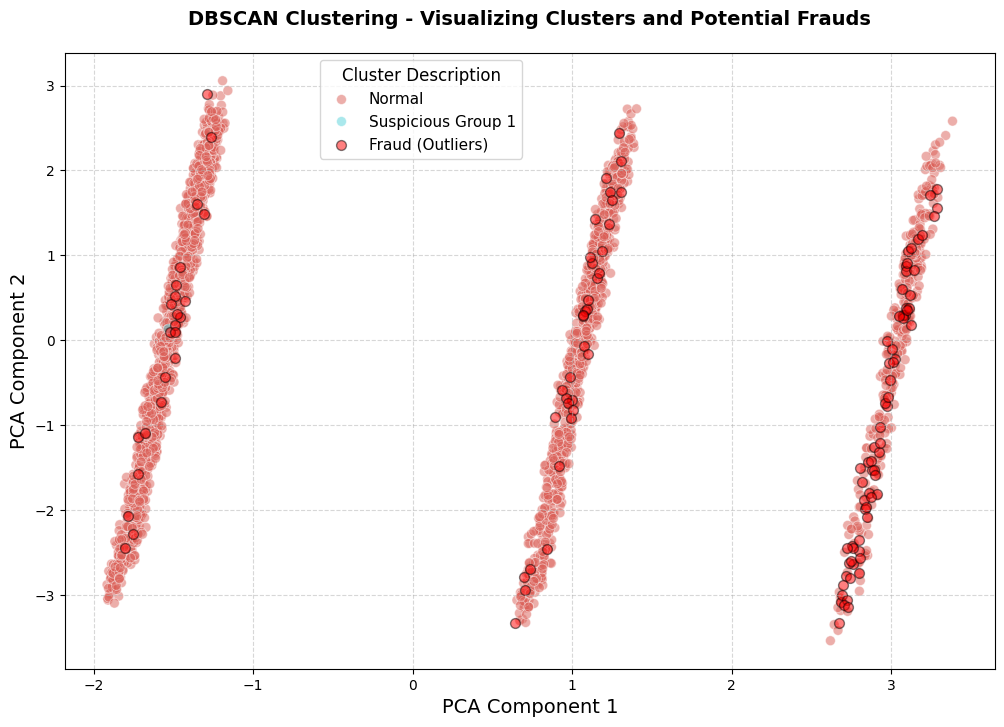

In [352]:
# Reduce dimensions to 2D for visualization
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_prepared)

# Add PCA results to the DataFrame
df_bank_transactions_dbscan["PCA1"] = X_pca[:, 0]
df_bank_transactions_dbscan["PCA2"] = X_pca[:, 1]

# Exclude outliers (-1) when creating the color palette for seaborn
clusters_no_outliers = df_bank_transactions_dbscan[df_bank_transactions_dbscan["DBSCAN_Cluster"] != -1]
unique_labels = clusters_no_outliers["Cluster_Description"].unique()
palette = sns.color_palette("hls", len(unique_labels))

# Scatter plot for normal points & suspicious clusters
plt.figure(figsize=(12, 8))
sns.scatterplot(data=clusters_no_outliers, x="PCA1", y="PCA2", hue="Cluster_Description", palette=palette, alpha=0.5, s=50)

# Highlight outliers with red dots and black edges, add a proper legend entry
outliers = df_bank_transactions_dbscan[df_bank_transactions_dbscan["DBSCAN_Cluster"] == -1]
plt.scatter(outliers["PCA1"], outliers["PCA2"], c="red", edgecolor="black", s=50, label="Fraud (Outliers)", alpha=0.5)
# Customize the plot
plt.title("DBSCAN Clustering - Visualizing Clusters and Potential Frauds", fontsize=14, weight="bold", pad=20)
plt.xlabel("PCA Component 1", fontsize=14)
plt.ylabel("PCA Component 2", fontsize=14)
plt.legend(title="Cluster Description", fontsize=11, title_fontsize=12, frameon=True, bbox_to_anchor=(0.5, 1))
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()

**DBSCAN Clustering Summary**

The chart illustrates the **DBSCAN clustering results** after dimensionality reduction using **PCA (2D)**.
The algorithm successfully identified **one main cluster (Normal)**, **a small suspicious group (Suspicious Group 1)**, and several **outliers (Fraud / Outliers)**.

* **Normal Cluster (2,384 points):** Represents stable transactions densely distributed along both PCA axes.
* **Suspicious Group 1 (3 points):** Very few cases — likely **borderline transactions** between legitimate and fraudulent behavior.
* **Fraud / Outliers (125 points):** Scattered around cluster edges, indicating **anomalous or behaviorally distinct transactions**.

**Insight:**
DBSCAN effectively detects **density-based outliers**, clearly separating **normal and potentially fraudulent activities** without requiring a predefined number of clusters.
The suspicious or anomalous points account for roughly **5% of the dataset**, which aligns well with the typical fraud occurrence rate in real-world scenarios.

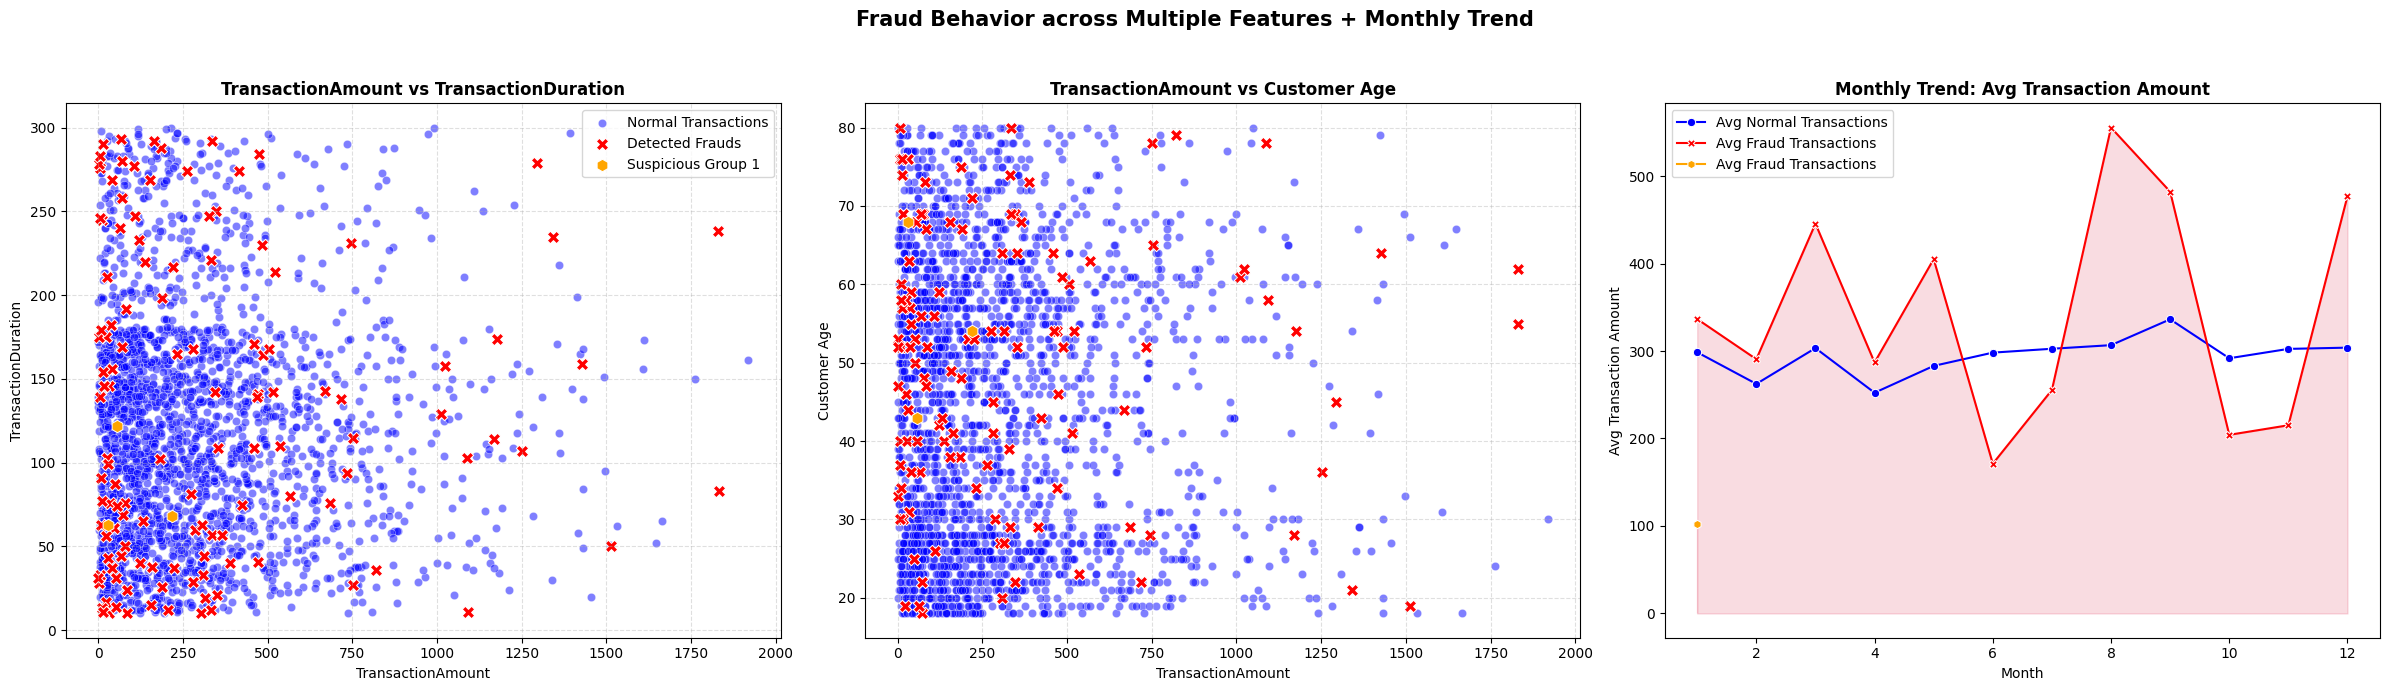

In [353]:
# --- Filter data for the selected cluster ---
normal_data = df_bank_transactions_dbscan[df_bank_transactions_dbscan["DBSCAN_Cluster"] == 0]
fraud_data = df_bank_transactions_dbscan[df_bank_transactions_dbscan["DBSCAN_Cluster"] == -1]
suspicious_group_1_data = df_bank_transactions_dbscan[df_bank_transactions_dbscan["DBSCAN_Cluster"] == 1]

# --- Create subplots (4 side by side) ---
fig, ax = plt.subplots(1, 3, figsize=(24, 7), sharey=False)

# Transaction Amount vs Duration
sns.scatterplot(data=normal_data, x="TransactionAmount", y="TransactionDuration",
                color="blue", alpha=0.5, ax=ax[0], label="Normal Transactions")
sns.scatterplot(data=fraud_data, x="TransactionAmount", y="TransactionDuration",
                color="red", marker="X", s=80, ax=ax[0], label="Detected Frauds")
sns.scatterplot(data=suspicious_group_1_data, x="TransactionAmount", y="TransactionDuration",
                color="orange", marker="h", s=80, ax=ax[0], label="Suspicious Group 1")
ax[0].set_title(f"TransactionAmount vs TransactionDuration", fontsize=12, fontweight="bold")
ax[0].set_xlabel("TransactionAmount")
ax[0].set_ylabel("TransactionDuration")
ax[0].grid(True, linestyle="--", alpha=0.4)
ax[0].legend()

# Customer Age vs Transaction Amount
sns.scatterplot(data=normal_data, x="TransactionAmount", y="CustomerAge",
                color="blue", alpha=0.5, ax=ax[1], label="Normal Transactions")
sns.scatterplot(data=fraud_data, x="TransactionAmount", y="CustomerAge",
                color="red", marker="X", s=80, ax=ax[1], label="Detected Frauds")
sns.scatterplot(data=suspicious_group_1_data, x="TransactionAmount", y="CustomerAge",
                color="orange", marker="h", s=80, ax=ax[1], label="Suspicious Group 1")
ax[1].set_title(f"TransactionAmount vs Customer Age", fontsize=12, fontweight="bold")
ax[1].set_xlabel("TransactionAmount")
ax[1].set_ylabel("Customer Age")
ax[1].grid(True, linestyle="--", alpha=0.4)
ax[1].legend().remove()

# Trend of TransactionAmount by Month
trend = normal_data.groupby("Month")["TransactionAmount"].mean().reset_index()
fraud_trend = fraud_data.groupby("Month")["TransactionAmount"].mean().reset_index()
suspicious_group_1_trend = suspicious_group_1_data.groupby("Month")["TransactionAmount"].mean().reset_index()

sns.lineplot(data=trend, x="Month", y="TransactionAmount", ax=ax[2],
                label="Avg Normal Transactions", color="blue", marker="o")
sns.lineplot(data=fraud_trend, x="Month", y="TransactionAmount", ax=ax[2],
                label="Avg Fraud Transactions", color="red", marker="X")
sns.lineplot(data=suspicious_group_1_trend, x="Month", y="TransactionAmount", ax=ax[2],
                label="Avg Fraud Transactions", color="orange", marker="h")

ax[2].fill_between(fraud_trend["Month"], fraud_trend["TransactionAmount"],
                        color="crimson", alpha=0.15)
ax[2].fill_between(suspicious_group_1_trend["Month"], suspicious_group_1_trend["TransactionAmount"],
                        color="crimson", alpha=0.15)

ax[2].set_title("Monthly Trend: Avg Transaction Amount", fontsize=12, fontweight="bold")
ax[2].set_xlabel("Month")
ax[2].set_ylabel("Avg Transaction Amount")
ax[2].legend()
ax[1].grid(True, linestyle="--", alpha=0.4)
plt.suptitle(f"Fraud Behavior across Multiple Features + Monthly Trend", fontsize=15, fontweight="bold")
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

**Fraud Behavior Overview (DBSCAN)**

* **Transactions:** Frauds mainly occur in **low to medium transaction amounts** with **short to medium durations**, indicating attempts to **mimic normal transactions**.
* **Customer Age:** Distributed **across all age groups**, showing no demographic dependency.
* **Monthly Trend:** Fraud activity **peaks in May, August, and December**, suggesting **seasonal or campaign-driven patterns**.
* **Insight:** DBSCAN effectively **detects low-density anomalies**, clearly separating **fraudulent behaviors** from **stable transaction patterns**.

## Isolation Forest

In [354]:
# Define outlier mapping
outlier_mapping = {1: "Normal", -1: "Potential Fraud"}

# Fit the Isolation Forest model
iso_forest = IsolationForest(n_estimators=100, contamination=0.05, random_state=42)
iso_forest.fit(X_use)

# Predict anomalies
df_bank_transactions_isolation["AnomalyScore"] = iso_forest.decision_function(X_use)
df_bank_transactions_isolation["IsAnomaly"] = iso_forest.predict(X_use)

# Map results to descriptive labels
df_bank_transactions_isolation["AnomalyLabel"] = df_bank_transactions_isolation["IsAnomaly"].map(outlier_mapping)

# Filter out detected anomalies
potential_frauds = df_bank_transactions_isolation[df_bank_transactions_isolation["IsAnomaly"] == -1]
print(f"Number of potential frauds detected: {len(potential_frauds)}")
display(potential_frauds.head())

Number of potential frauds detected: 126


,TransactionID,AccountID,TransactionAmount,TransactionType,DeviceID,IP Address,MerchantID,Channel,CustomerAge,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance,Region,TimeSinceLastTx,Hour,Month,DayOfWeek,UnixTime,Hour_sin,Hour_cos,Day_sin,Day_cos,AnomalyScore,IsAnomaly,AnomalyLabel
693,TX000694,AC00011,733.29,Debit,D000618,16.51.235.240,M032,ATM,52,Doctor,94,5,10427.00,South,0.0,18,3,15,1678905736,-1.000000,-1.836970e-16,0.781831,0.623490,-0.033442,-1,Potential Fraud
1180,TX001181,AC00016,50.00,Credit,D000309,150.231.20.169,M018,ATM,53,Doctor,87,1,185.87,South,0.0,18,2,24,1677261912,-1.000000,-1.836970e-16,0.433884,-0.900969,-0.007350,-1,Potential Fraud
1801,TX001802,AC00018,331.32,Debit,D000334,200.164.13.160,M078,Branch,61,Doctor,137,5,13054.54,West,9074873.0,17,6,5,1685985869,-0.965926,-2.588190e-01,-0.974928,-0.222521,-0.007500,-1,Potential Fraud
1682,TX001683,AC00019,41.13,Credit,D000655,109.42.41.157,M030,Branch,77,Retired,58,1,6067.54,Northeast,4065799.0,17,3,27,1679939595,-0.965926,-2.588190e-01,-0.781831,0.623490,-0.013435,-1,Potential Fraud
2148,TX002149,AC00021,734.86,Credit,D000198,134.140.85.231,M075,Branch,48,Engineer,290,1,6242.03,Northeast,865141.0,16,12,8,1702053390,-0.866025,-5.000000e-01,0.781831,0.623490,-0.005853,-1,Potential Fraud


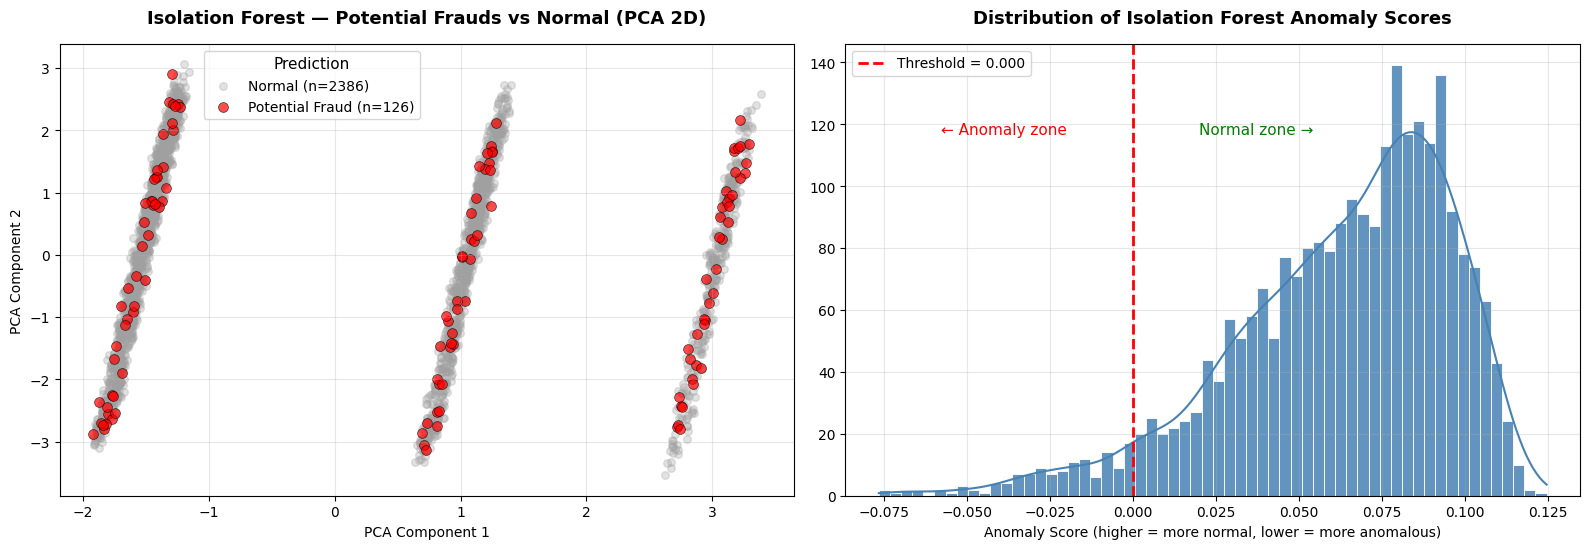

In [355]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_use)

# === Prepare data for visualization ===
viz_df = df_bank_transactions_isolation.copy()
viz_df["PCA1_Isolation"] = X_pca[:, 0]
viz_df["PCA2_Isolation"] = X_pca[:, 1]

# === Automatic threshold from Isolation Forest ===
threshold = 0  # In sklearn: score < 0 = anomaly, score >= 0 = normal

# Split normal vs anomaly samples
normal_df = viz_df[viz_df["IsAnomaly"] == 1]
anomaly_df = viz_df[viz_df["IsAnomaly"] == -1]

# === Create figure with two subplots ===
fig, ax = plt.subplots(1, 2, figsize=(16, 6))

# --- Left subplot: PCA scatter plot ---
ax[0].scatter(normal_df["PCA1_Isolation"], normal_df["PCA2_Isolation"],
                s=30, alpha=0.3, label=f'Normal (n={len(normal_df)})', c="#A0A0A0")
ax[0].scatter(anomaly_df["PCA1_Isolation"], anomaly_df["PCA2_Isolation"],
                s=50, alpha=0.7, label=f'Potential Fraud (n={len(anomaly_df)})',
                c="red", edgecolors="black", linewidths=0.5)
ax[0].set_title("Isolation Forest — Potential Frauds vs Normal (PCA 2D)", fontsize=13, weight="bold", pad=15)
ax[0].set_xlabel("PCA Component 1")
ax[0].set_ylabel("PCA Component 2")
ax[0].legend(title="Prediction", fontsize=10, title_fontsize=11, frameon=True, bbox_to_anchor=(0.5, 1))
ax[0].grid(alpha=0.3)

# --- Right subplot: Histogram of Anomaly Scores ---
sns.histplot(viz_df["AnomalyScore"], bins=60, kde=True, edgecolor="white", alpha=0.85, ax=ax[1], color="#4682B4")
# Add threshold line (model decision boundary)
ax[1].axvline(x=threshold, color="red", linestyle="--", linewidth=2, label=f"Threshold = {threshold:.3f}")

# Annotate regions
ax[1].text(threshold + 0.02, ax[1].get_ylim()[1]*0.8, "Normal zone →", color="green", fontsize=11)
ax[1].text(threshold - 0.02, ax[1].get_ylim()[1]*0.8, "← Anomaly zone", color="red", fontsize=11, ha="right")
ax[1].set_title("Distribution of Isolation Forest Anomaly Scores", fontsize=13, weight="bold", pad=15)
ax[1].set_xlabel("Anomaly Score (higher = more normal, lower = more anomalous)")
ax[1].set_ylabel("")
ax[1].legend(frameon=True, fontsize=10)
ax[1].grid(alpha=0.3)
plt.tight_layout()
plt.show()

**Isolation Forest — Overall Fraud Detection Summary**

**1. Cluster Visualization (Left Chart)**

* The PCA scatter plot shows a **clear separation** between normal transactions (gray) and potential frauds (red).
* Fraudulent transactions appear **interspersed but sparser**, often located **around the edges of dense clusters**, which aligns with how Isolation Forest isolates anomalies in low-density regions.
* This visual confirms that the algorithm effectively distinguishes **outlier behaviors** without requiring explicit labels.

**2. Anomaly Score Distribution (Right Chart)**

* The histogram of anomaly scores reveals a **right-skewed distribution**, where most transactions cluster in the **normal (positive score)** zone.
* The **vertical red dashed line at 0** represents the model’s automatic **decision boundary**:

  * **Left side (< 0):** “Anomaly zone” — likely fraudulent or suspicious.
  * **Right side (≥ 0):** “Normal zone” — legitimate transactions.
* The clear drop near the threshold suggests the **model separates normal and abnormal behavior well**, with minimal overlap.

**3. Key Insight**
Isolation Forest successfully identifies a small subset of transactions (≈5%) as anomalies.
These are **behaviorally distinct and statistically isolated**, warranting further investigation for potential fraud or system irregularities.

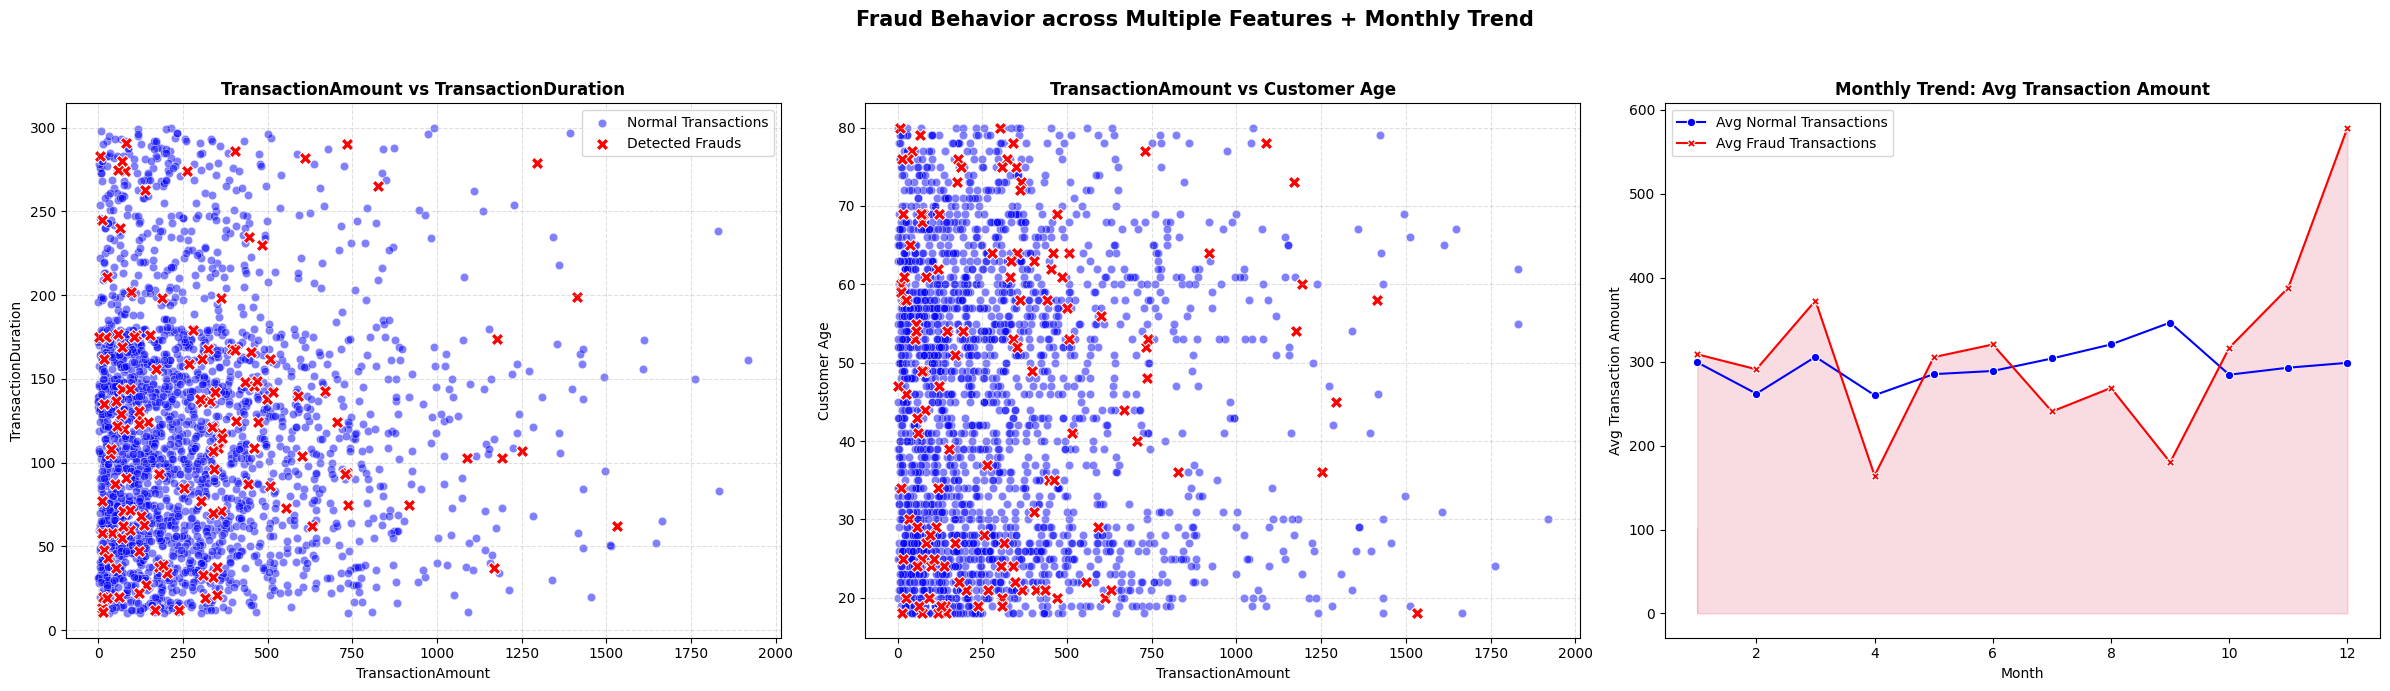

In [356]:
# --- Filter data for the selected cluster ---
normal_data = df_bank_transactions_isolation[df_bank_transactions_isolation["IsAnomaly"] == 1]
fraud_data = df_bank_transactions_isolation[df_bank_transactions_isolation["IsAnomaly"] == -1]

# --- Create subplots (4 side by side) ---
fig, ax = plt.subplots(1, 3, figsize=(24, 7), sharey=False)

# Transaction Amount vs Duration
sns.scatterplot(data=normal_data, x="TransactionAmount", y="TransactionDuration",
                color="blue", alpha=0.5, ax=ax[0], label="Normal Transactions")
sns.scatterplot(data=fraud_data, x="TransactionAmount", y="TransactionDuration",
                color="red", marker="X", s=80, ax=ax[0], label="Detected Frauds")
ax[0].set_title(f"TransactionAmount vs TransactionDuration", fontsize=12, fontweight="bold")
ax[0].set_xlabel("TransactionAmount")
ax[0].set_ylabel("TransactionDuration")
ax[0].grid(True, linestyle="--", alpha=0.4)
ax[0].legend()

# Customer Age vs Transaction Amount
sns.scatterplot(data=normal_data, x="TransactionAmount", y="CustomerAge",
                color="blue", alpha=0.5, ax=ax[1], label="Normal Transactions")
sns.scatterplot(data=fraud_data, x="TransactionAmount", y="CustomerAge",
                color="red", marker="X", s=80, ax=ax[1], label="Detected Frauds")
ax[1].set_title(f"TransactionAmount vs Customer Age", fontsize=12, fontweight="bold")
ax[1].set_xlabel("TransactionAmount")
ax[1].set_ylabel("Customer Age")
ax[1].grid(True, linestyle="--", alpha=0.4)
ax[1].legend().remove()

# Trend of TransactionAmount by Month
trend = normal_data.groupby("Month")["TransactionAmount"].mean().reset_index()
fraud_trend = fraud_data.groupby("Month")["TransactionAmount"].mean().reset_index()
suspicious_group_1_trend = suspicious_group_1_data.groupby("Month")["TransactionAmount"].mean().reset_index()

sns.lineplot(data=trend, x="Month", y="TransactionAmount", ax=ax[2],
                label="Avg Normal Transactions", color="blue", marker="o")
sns.lineplot(data=fraud_trend, x="Month", y="TransactionAmount", ax=ax[2],
                label="Avg Fraud Transactions", color="red", marker="X")
ax[2].fill_between(fraud_trend["Month"], fraud_trend["TransactionAmount"],
                        color="crimson", alpha=0.15)
ax[2].fill_between(suspicious_group_1_trend["Month"], suspicious_group_1_trend["TransactionAmount"],
                        color="crimson", alpha=0.15)

ax[2].set_title("Monthly Trend: Avg Transaction Amount", fontsize=12, fontweight="bold")
ax[2].set_xlabel("Month")
ax[2].set_ylabel("Avg Transaction Amount")
ax[2].legend()
ax[1].grid(True, linestyle="--", alpha=0.4)
plt.suptitle(f"Fraud Behavior across Multiple Features + Monthly Trend", fontsize=15, fontweight="bold")
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

**Fraud Behavior Overview**

* **Multi-dimensional analysis:** Fraudulent transactions (red points) are scattered across all value ranges, indicating that **fraud occurs in both low- and high-value transactions**.
* **Customer characteristics:** Frauds are **not concentrated in specific age groups**, suggesting risk is evenly distributed across demographics.
* **Monthly trend:** The chart shows a **sharp increase in fraudulent activity during December**, indicating **heightened fraud risk during peak transaction periods**.

## LocalOutlierFactor

,TransactionID,AccountID,TransactionAmount,TransactionType,DeviceID,IP Address,MerchantID,Channel,CustomerAge,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance,Region,TimeSinceLastTx,Hour,Month,DayOfWeek,UnixTime,Hour_sin,Hour_cos,Day_sin,Day_cos,LOF_Score,LOF_Label,PCA1_LOF,PCA2_LOF
244,TX000245,AC00004,40.66,Debit,D000214,148.25.159.90,M061,Branch,59,Retired,156,1,1153.84,South,1725151.0,16,1,1,1704125329,-0.866025,-5.000000e-01,7.818315e-01,0.623490,1.215060,-1,-1.523517,0.098799
2004,TX002005,AC00008,76.16,Debit,D000539,100.128.70.210,M060,ATM,23,Student,99,1,1072.25,West,0.0,16,11,21,1700585129,-0.866025,-5.000000e-01,-7.347881e-16,1.000000,1.085951,-1,-1.376976,0.814164
693,TX000694,AC00011,733.29,Debit,D000618,16.51.235.240,M032,ATM,52,Doctor,94,5,10427.00,South,0.0,18,3,15,1678905736,-1.000000,-1.836970e-16,7.818315e-01,0.623490,1.086809,-1,2.754383,-2.428560
739,TX000740,AC00014,346.65,Debit,D000077,43.98.242.106,M062,Online,30,Engineer,60,1,6356.96,South,2157487.0,16,1,1,1704125833,-0.866025,-5.000000e-01,7.818315e-01,0.623490,1.156922,-1,-1.541532,0.117937
2111,TX002112,AC00021,762.74,Debit,D000196,8.136.178.116,M053,ATM,64,Doctor,244,1,207.10,West,8558510.0,17,5,2,1683048294,-0.965926,-2.588190e-01,9.749279e-01,-0.222521,1.094936,-1,0.927427,-0.534119


Knee point threshold: 1.0921


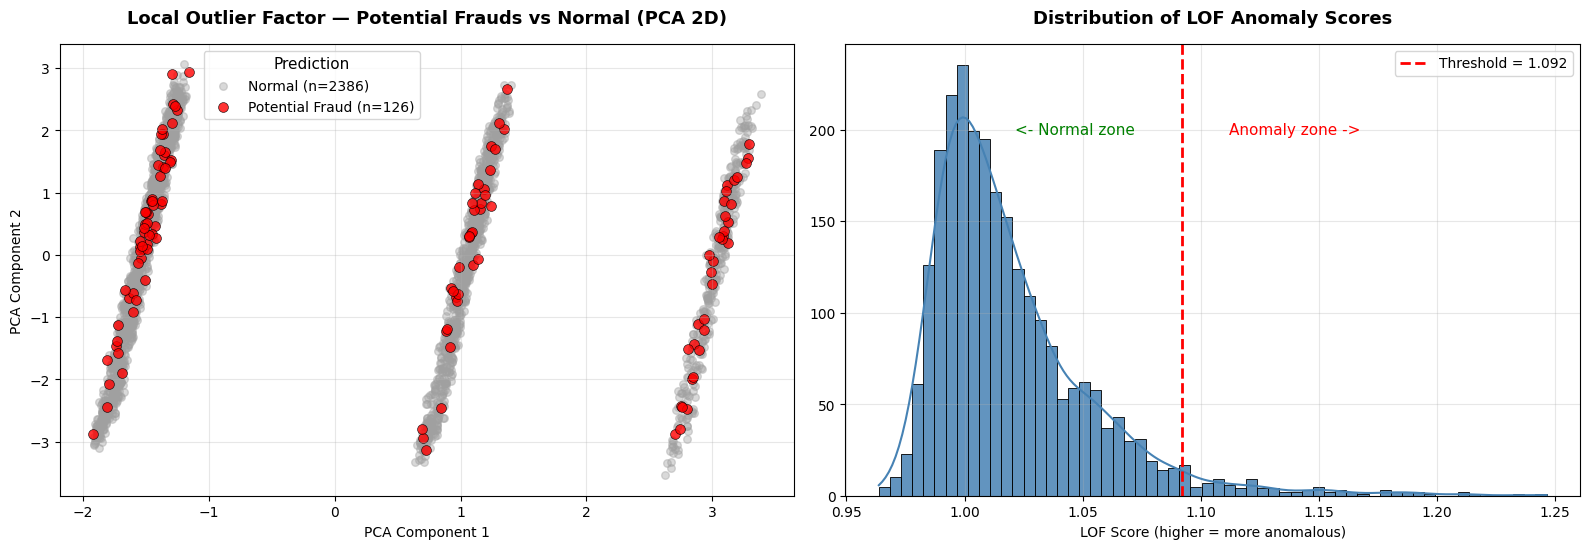

In [357]:
lof = LocalOutlierFactor(n_neighbors=20, contamination=0.05)  # 5% anomalies
y_pred = lof.fit_predict(X_use)  # -1 = anomaly, 1 = normal
lof_scores = -lof.negative_outlier_factor_  # higher = more anomalous

# Prepare DataFrame for visualization
viz_df = df_bank_transactions_lof.copy()
viz_df["LOF_Score"] = lof_scores
viz_df["LOF_Label"] = y_pred

# PCA for 2D visualization
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_use)
viz_df["PCA1_LOF"] = X_pca[:, 0]
viz_df["PCA2_LOF"] = X_pca[:, 1]

# Split data
normal_df = viz_df[viz_df["LOF_Label"] == 1]
anomaly_df = viz_df[viz_df["LOF_Label"] == -1]
display(anomaly_df.head())

# Visualization (2 subplots)
fig, ax = plt.subplots(1, 2, figsize=(16, 6))

# --- Left: PCA scatter ---
ax[0].scatter(normal_df["PCA1_LOF"], normal_df["PCA2_LOF"],
                s=30, alpha=0.4, c="#A0A0A0", label=f'Normal (n={len(normal_df)})')
ax[0].scatter(anomaly_df["PCA1_LOF"], anomaly_df["PCA2_LOF"],
                s=50, alpha=0.8, c="red", edgecolor="black", linewidth=0.5,
                label=f'Potential Fraud (n={len(anomaly_df)})')

ax[0].set_title("Local Outlier Factor — Potential Frauds vs Normal (PCA 2D)", 
                  fontsize=13, weight="bold", pad=15)
ax[0].set_xlabel("PCA Component 1")
ax[0].set_ylabel("PCA Component 2")
ax[0].legend(title="Prediction", fontsize=10, title_fontsize=11, frameon=True, bbox_to_anchor=(0.5, 1))
ax[0].grid(alpha=0.3)

# --- Threshold ---
sorted_scores = np.sort(viz_df["LOF_Score"].values)
x = np.arange(len(sorted_scores))
kneedle = KneeLocator(x, sorted_scores, curve="convex", direction="increasing")
threshold = sorted_scores[kneedle.knee]
print(f"Knee point threshold: {threshold:.4f}")

# --- Right: LOF score distribution ---
sns.histplot(viz_df["LOF_Score"], bins=60, kde=True, color="#4682B4", alpha=0.85, ax=ax[1])
ax[1].axvline(x=threshold, color="red", linestyle="--", linewidth=2, label=f"Threshold = {threshold:.3f}")
# Annotate regions
ax[1].text(threshold + 0.02, ax[1].get_ylim()[1]*0.8, "Anomaly zone ->", color="red", fontsize=11)
ax[1].text(threshold - 0.02, ax[1].get_ylim()[1]*0.8, "<- Normal zone", color="green", fontsize=11, ha="right")

ax[1].set_title("Distribution of LOF Anomaly Scores", fontsize=13, weight="bold", pad=15)
ax[1].set_xlabel("LOF Score (higher = more anomalous)")
ax[1].set_ylabel("")
ax[1].grid(alpha=0.3)
ax[1].legend(frameon=True, fontsize=10)
plt.tight_layout()
plt.show()

**LOF Model – Overview Insight**

* LOF detects **local density anomalies**, identifying points that deviate from their neighborhood rather than the global pattern.
* Fraudulent transactions (red) appear **around the cluster edges**, indicating lower local density compared to normal ones.
* The LOF score distribution shows a **clear threshold (~1.09)** separating normal (left) and anomalous (right) regions.
* Overall, the model effectively highlights **subtle, locally inconsistent frauds** that may be missed by global-based methods like Isolation Forest.

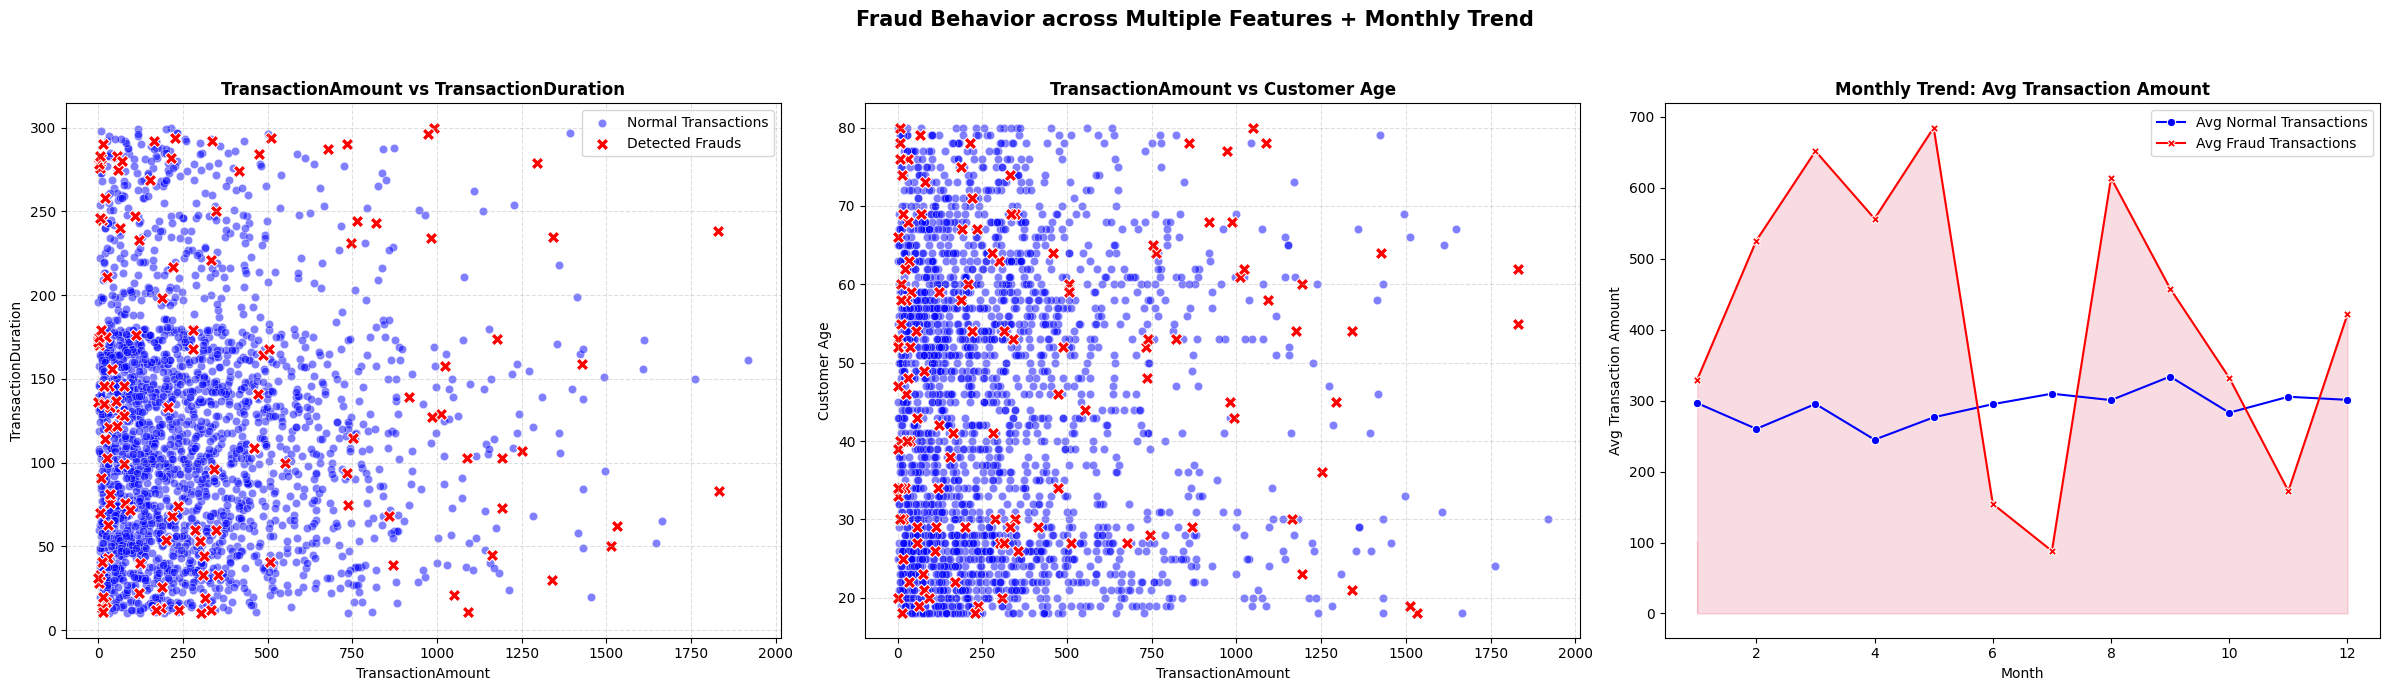

In [358]:
# --- Filter data for the selected cluster ---
normal_data = viz_df[viz_df["LOF_Label"] == 1]
fraud_data = viz_df[viz_df["LOF_Label"] == -1]

# --- Create subplots (4 side by side) ---
fig, ax = plt.subplots(1, 3, figsize=(24, 7), sharey=False)

# Transaction Amount vs Duration
sns.scatterplot(data=normal_data, x="TransactionAmount", y="TransactionDuration",
                color="blue", alpha=0.5, ax=ax[0], label="Normal Transactions")
sns.scatterplot(data=fraud_data, x="TransactionAmount", y="TransactionDuration",
                color="red", marker="X", s=80, ax=ax[0], label="Detected Frauds")
ax[0].set_title(f"TransactionAmount vs TransactionDuration", fontsize=12, fontweight="bold")
ax[0].set_xlabel("TransactionAmount")
ax[0].set_ylabel("TransactionDuration")
ax[0].grid(True, linestyle="--", alpha=0.4)
ax[0].legend()

# Customer Age vs Transaction Amount
sns.scatterplot(data=normal_data, x="TransactionAmount", y="CustomerAge",
                color="blue", alpha=0.5, ax=ax[1], label="Normal Transactions")
sns.scatterplot(data=fraud_data, x="TransactionAmount", y="CustomerAge",
                color="red", marker="X", s=80, ax=ax[1], label="Detected Frauds")
ax[1].set_title(f"TransactionAmount vs Customer Age", fontsize=12, fontweight="bold")
ax[1].set_xlabel("TransactionAmount")
ax[1].set_ylabel("Customer Age")
ax[1].grid(True, linestyle="--", alpha=0.4)
ax[1].legend().remove()

# Trend of TransactionAmount by Month
trend = normal_data.groupby("Month")["TransactionAmount"].mean().reset_index()
fraud_trend = fraud_data.groupby("Month")["TransactionAmount"].mean().reset_index()
suspicious_group_1_trend = suspicious_group_1_data.groupby("Month")["TransactionAmount"].mean().reset_index()

sns.lineplot(data=trend, x="Month", y="TransactionAmount", ax=ax[2],
                label="Avg Normal Transactions", color="blue", marker="o")
sns.lineplot(data=fraud_trend, x="Month", y="TransactionAmount", ax=ax[2],
                label="Avg Fraud Transactions", color="red", marker="X")
ax[2].fill_between(fraud_trend["Month"], fraud_trend["TransactionAmount"],
                        color="crimson", alpha=0.15)
ax[2].fill_between(suspicious_group_1_trend["Month"], suspicious_group_1_trend["TransactionAmount"],
                        color="crimson", alpha=0.15)

ax[2].set_title("Monthly Trend: Avg Transaction Amount", fontsize=12, fontweight="bold")
ax[2].set_xlabel("Month")
ax[2].set_ylabel("Avg Transaction Amount")
ax[2].legend()
ax[1].grid(True, linestyle="--", alpha=0.4)
plt.suptitle(f"Fraud Behavior across Multiple Features + Monthly Trend", fontsize=15, fontweight="bold")
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

**Fraud Behavior Overview**

* Fraudulent transactions tend to have **higher amounts** and **longer durations**, showing deviation from normal behavior patterns.
* Fraud cases occur **across all age groups**, but appear more frequently among **younger to middle-aged customers** (20–50).
* The **monthly trend** shows strong **seasonal fluctuations** — peaks in months **4, 7, and 9**, indicating **periodic fraud surges**.
* Overall, fraud activities are **value-driven and seasonally concentrated**, suggesting a need for **temporal and behavioral monitoring**.

## Comparative Summary of Fraud Detection Models

| **Model**                      | **Main Mechanism**                                                     | **Fraud Detection Principle**                                                               | **Outlier Ratio / Count** | **Visual Pattern (From Plots)**                                                                                                | **Key Strengths**                                                                                                    | **Limitations / Remarks**                                                                                    |
| ------------------------------ | ---------------------------------------------------------------------- | ------------------------------------------------------------------------------------------- | ------------------------- | ------------------------------------------------------------------------------------------------------------------------------ | -------------------------------------------------------------------------------------------------------------------- | ------------------------------------------------------------------------------------------------------------ |
| **K-Means Clustering**         | Groups data based on **distance to centroids** in PCA space            | Transactions farthest from their cluster centroids (top 5%) are labeled as potential frauds | **97 transactions (~5%)** | Three clear clusters (blue, orange, green); **red points** scattered near edges — especially concentrated in Cluster 2 (green) | - Easy to visualize behavioral segmentation<br>- Effective when customer behavior is well-structured                 | - Requires predefined number of clusters (k)<br>- Performs poorly with non-linear or unevenly dense clusters |
| **DBSCAN**                     | Groups points based on **density proximity**                           | Identifies **outliers in low-density regions** as potential frauds                          | **125 outliers (~5%)**    | One large pink cluster (Normal), one small “Suspicious Group,” and **black-edged red dots** scattered around the edges         | - No need to define cluster count<br>- Naturally detects low-density anomalies                                       | - Sensitive to parameters `eps` and `min_samples`<br>- May miss small dense subgroups                        |
| **Isolation Forest**           | Isolates anomalies through **random partitioning trees**               | Transactions with **score < 0** are flagged as anomalies                                    | **126 anomalies (~5%)**   | PCA scatter: **red points** lie at edges of gray clusters; histogram is right-skewed with a **threshold at 0**                 | - Detects global outliers effectively<br>- Scales well to large unlabeled datasets                                   | - Lacks interpretability on natural groupings<br>- May overlook subtle local anomalies                       |
| **LOF (Local Outlier Factor)** | Compares **local neighborhood density** to identify low-density points | Points with **LOF > 1.09** are marked as anomalies                                          | **≈126 anomalies (~5%)**  | Red points appear near cluster boundaries; histogram shows **clear threshold at ~1.09** separating normal vs. anomalous        | - Excellent at detecting **fine-grained local anomalies**<br>- Catches subtle deviations overlooked by global models | - Sensitive to noise and neighbor size (`k`)<br>- Not ideal for very large datasets                          |

**Overall Insights**

| **Aspect**               | **Observation**                                                                                                                                        |
| ------------------------ | ------------------------------------------------------------------------------------------------------------------------------------------------------ |
| **Fraud Distribution**   | All four models detect around **5% of transactions** as anomalies — aligning with typical real-world fraud rates.                                      |
| **Cluster Separability** | K-Means & DBSCAN show the **clearest behavioral segmentation**, while Isolation Forest & LOF emphasize **low-density edge regions**.                   |
| **Use Case Fit**         | - **K-Means / DBSCAN:** Best for **behavioral pattern exploration**.<br>- **Isolation Forest / LOF:** Best for **fine-grained anomaly detection**.     |
| **Recommended Workflow** | → Use **K-Means or DBSCAN** to model general transaction behavior.<br>→ Then apply **Isolation Forest or LOF** to pinpoint specific, rare fraud cases. |

<!-- Google Fonts for Roboto -->
<link href="https://fonts.googleapis.com/css2?family=Roboto:wght@700&display=swap" rel="stylesheet">

<div style="
    border-radius: 15px;
    border: 2px solid #762a83;
    padding: 20px;
    background: linear-gradient(135deg, #e7d4e8, #d9f0d3);
    font-family: 'Roboto', sans-serif;
    box-shadow: 0 4px 8px rgba(0,0,0,0.2);
">
  <h1 style="color:#40004b; font-weight:700; margin-bottom:15px;"> Acknowledgements</h1>
  <p style="font-size:15px; color:#333;"> 
  <a href="https://www.kaggle.com/sulaniishara" style="color:#762a83; text-decoration:underline;">
    @sulaniishara -
  </a>  
  <a href="https://www.kaggle.com/code/sulaniishara/fraud-detection-clustering-anomaly-analysis" style="color:#762a83; text-decoration:underline;">
    🚨 Fraud Detection: Clustering & Anomaly Analysis
  </a>
</p>

  <h2 style="color:#40004b; font-weight:700; margin-top:30px; margin-bottom:16px;">References</h2>
  <ul style="color:#333; font-size:15px;">
    <li><a href="https://www.kaggle.com/datasets/valakhorasani/bank-transaction-dataset-for-fraud-detection" style="color:#762a83;">Bank Transaction Dataset for Fraud Detection</a></li>
  </ul>
</div>

<!-- Include Google Fonts for a modern font -->
<link href="https://fonts.googleapis.com/css2?family=Roboto:wght@700&display=swap" rel="stylesheet">

<div style="
    border-radius: 15px; 
    border: 2px solid #003366; 
    padding: 10px; 
    background: linear-gradient(135deg, #003366, #336699 30%, #66ccff 70%, #99ccff); 
    text-align: center; 
    box-shadow: 0px 4px 8px rgba(0, 0, 0, 0.5);
">
    <h1 style="
        color: #FFFFFF; 
        text-shadow: 2px 2px 4px rgba(0, 0, 0, 0.7); 
        font-weight: bold; 
        margin-bottom: 5px; 
        font-size: 28px; 
        font-family: 'Roboto', sans-serif;
        letter-spacing: 1px;
    ">
        🙏 Thanks for Reading! 🚀
    </h1>
    <p style="color: #ffffff; font-size: 18px; text-align: center;">
        Happy Coding! 🙌😊
    </p>
</div>
